# Paper 2 — Goal 1 complete analysis

## Clinical information available in recording quality

**Scientific question.** Does the fixed recording-quality representation \(Q\) contain reproducible out-of-sample information about ALS diagnosis or contemporaneous ALSFRS-R bulbar function in unseen participants?

**Permitted interpretation.** Above-null performance means clinically structured information is available in \(Q\). It does not prove technical origin, spuriousness, confounding, or shortcut learning.

This notebook is the single authoritative Goal 1 implementation. It is designed to run from a fresh kernel from top to bottom and does not depend on variables or result files created by earlier failed Goal 1 notebooks.

It implements:

- the frozen diagnosis and ≤60-day severity index populations;
- the fixed participant 5-fold × 10-repeat outer split manifest;
- 5-fold participant-grouped inner tuning;
- fold-safe QCHAN reconstruction from training participants only;
- training-only transforms, QADD imputation/support handling, scaling, and hyperparameter tuning;
- Age, Support-only, QADD, QGAIN, QREV, QCHAN, Core-Q ridge, Age+Core-Q ridge, and Core-Q HGB;
- participant-cluster bootstrap uncertainty;
- full-pipeline participant-level permutation nulls for primary Core-Q ridge;
- native OOF calibration;
- prespecified Goal 1 sensitivities;
- machine-readable saved outputs and Nature/npj-style publication figures.

### Run modes

`RUN_MODE = "DEVELOPMENT"` executes the complete pipeline with reduced resampling counts so implementation can be verified.

`RUN_MODE = "FINAL"` uses the frozen inference counts:
- 2,000 participant bootstraps;
- 1,000 full-pipeline participant-level permutations.

Development results must never be copied into the manuscript as final inference.

## How to run this notebook

Use **Kernel → Restart Kernel and Run All Cells**. Do not mix cells from the earlier Goal 1 notebooks with this version. This rebuilt notebook writes to a new isolated output tree:

`outputs/goal1/goal1_complete_v1_1/<development|final>/`

The default is `RUN_MODE = "DEVELOPMENT"`. It executes the entire scientific workflow with reduced resampling counts and must end with `GOAL 1 DEVELOPMENT PIPELINE: PASS`. Only after that should `RUN_MODE` be changed to `"FINAL"` for the frozen 2,000-bootstrap / 1,000-permutation analysis.

`RESET_OUTPUTS = False` is intentionally restart-safe. On a first run there is nothing to reuse; after an interruption, only schema-validated checkpoints under the identical run signature are reused. Set it to `True` only when you deliberately want to discard this rebuilt notebook's checkpoints and recompute from zero.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as mdlib
import itertools
import json
import math
import os
import platform
import shutil
import subprocess
import sys
import tempfile
import warnings
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.nonparametric.smoothers_lowess import lowess

# -------------------------------------------------------------------------
# USER-FACING EXECUTION CONFIGURATION
# -------------------------------------------------------------------------
RUN_MODE = "DEVELOPMENT"   # change to "FINAL" only after development PASS
RESET_OUTPUTS = False      # restart-safe; set True only for a deliberate clean recomputation
RESUME_IF_VALID = True     # when RESET_OUTPUTS=False, reuse only schema-validated checkpoints
RUN_HGB = True
RUN_SENSITIVITIES = True
RUN_PERMUTATIONS = True
RUN_ELASTIC_NET = False    # optional in the frozen specification; not primary

BASE_SEED = 20260825
OUTER_FOLDS = 5
OUTER_REPEATS = 10
INNER_FOLDS = 5

if RUN_MODE not in {"DEVELOPMENT", "FINAL"}:
    raise ValueError("RUN_MODE must be 'DEVELOPMENT' or 'FINAL'.")

if RUN_MODE == "FINAL":
    N_BOOTSTRAPS = 2000
    N_PERMUTATIONS = 1000
    PERMUTATION_REPEATS = 10
else:
    # Complete code path, reduced resampling only.
    N_BOOTSTRAPS = 300
    N_PERMUTATIONS = 10
    PERMUTATION_REPEATS = 3

EXPECTED_PAPER1_COMMIT = "cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8"
ENGINE_VERSION = "goal1-complete-v1.1.0"
ENGINE_BUILD_SHA256 = "c6b7dcdea2ede265523549b745fcc3aaa4cfd6d6042cdf30af6b2cf3a1d6da4b"

EXPECTED = {
    "recordings": 519,
    "participants": 224,
    "als_participants": 158,
    "control_participants": 66,
    "als_recordings": 418,
    "control_recordings": 101,
    "severity_primary_participants": 145,
}

def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        candidate = Path(override).expanduser().resolve()
        if (candidate / "data" / "processed").exists():
            return candidate
        raise FileNotFoundError(f"PAPER2_ROOT is invalid: {candidate}")

    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed").exists()
            and (candidate / "data" / "manifests").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the Paper 2 repository root. "
        "Open this notebook from the repository or notebooks/ folder."
    )

ROOT = find_project_root()
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
INTERIM = ROOT / "data" / "interim"
EXTERNAL = ROOT / "external" / "quality_framework_features"

RUN_TAG = RUN_MODE.lower()
OUT = ROOT / "outputs" / "goal1" / "goal1_complete_v1_1" / RUN_TAG
CHECKPOINTS = OUT / "checkpoints"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
OOF_DIR = OUT / "oof"
LOGS = OUT / "logs"

if RESET_OUTPUTS and OUT.exists():
    shutil.rmtree(OUT)

for directory in [OUT, CHECKPOINTS, TABLES, FIGURES, OOF_DIR, LOGS]:
    directory.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

print("Paper 2 root:", ROOT)
print("Engine:", ENGINE_VERSION)
print("Run mode:", RUN_MODE)
print("Bootstrap replicates:", N_BOOTSTRAPS)
print("Permutation replicates:", N_PERMUTATIONS)
print("Permutation CV repeats:", PERMUTATION_REPEATS)

Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: goal1-complete-v1.1.0
Run mode: DEVELOPMENT
Bootstrap replicates: 300
Permutation replicates: 10
Permutation CV repeats: 3


## 1. Atomic I/O and reproducibility utilities

A partial computation is never allowed to masquerade as a completed result. Tables are written to temporary files, validated, and atomically promoted only after successful completion.

In [2]:
def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def stable_hash(payload) -> str:
    text = json.dumps(payload, sort_keys=True, default=str, separators=(",", ":"))
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def atomic_write_json(payload, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    os.replace(tmp, path)

def atomic_write_csv(
    frame: pd.DataFrame,
    path: Path,
    *,
    required_columns=None,
    allow_empty=False,
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if not isinstance(frame, pd.DataFrame):
        raise TypeError(f"{path.name}: expected DataFrame.")
    if not allow_empty and len(frame) == 0:
        raise ValueError(f"{path.name}: refusing to write an empty result table.")
    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(f"{path.name}: missing required columns {sorted(missing)}")

    tmp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(tmp, index=False)
    if tmp.stat().st_size == 0:
        raise IOError(f"{path.name}: temporary CSV is unexpectedly empty.")
    os.replace(tmp, path)

def safe_read_csv(path: Path, *, required_columns=None, allow_empty=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if path.stat().st_size == 0:
        raise IOError(f"{path} exists but is empty.")
    frame = pd.read_csv(path, low_memory=False)
    if not allow_empty and len(frame) == 0:
        raise ValueError(f"{path} contains no rows.")
    if required_columns:
        missing = set(required_columns) - set(frame.columns)
        if missing:
            raise ValueError(f"{path.name}: missing columns {sorted(missing)}")
    return frame

def package_version(name):
    try:
        return mdlib.version(name)
    except Exception:
        return "unknown"

def safe_name(text: str) -> str:
    return (
        str(text).lower()
        .replace(" + ", "_plus_")
        .replace("+", "plus")
        .replace("≤", "le")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("–", "-")
    )

print("Atomic I/O utilities: READY")

Atomic I/O utilities: READY


## 2. Pre-modeling gates and canonical inputs

The denominator and leakage gates are rechecked in this notebook. Goal 1 does not proceed if the canonical 519-recording / 224-participant contract or the Phase 0.5 QCHAN reproduction gate is broken.

In [3]:
PATHS = {
    "recording_table": PROCESSED / "recording_table_phase0.csv",
    "participant_table": PROCESSED / "participant_table.csv",
    "diagnosis_index": PROCESSED / "goal1_diagnosis_index.csv",
    "severity_index": PROCESSED / "goal1_severity_index.csv",
    "severity_pairs": PROCESSED / "severity_pairs.csv",
    "split_manifest": MANIFESTS / "split_manifest.csv",
    "q_registry": MANIFESTS / "q_registry.csv",
    "phase0_report": MANIFESTS / "phase0_freeze_report.csv",
    "qchan_ready": MANIFESTS / "qchan_cache_ready.json",
    "qchan_cache_index": MANIFESTS / "qchan_spectrum_cache_index.csv",
}

missing_files = [name for name, path in PATHS.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing Phase 0/0.5 artifacts: " + ", ".join(missing_files)
    )

recording_table = safe_read_csv(
    PATHS["recording_table"],
    required_columns=["participant_id", "logical_recording_id", "diagnosis"],
)
participant_table = safe_read_csv(
    PATHS["participant_table"],
    required_columns=["participant_id", "diagnosis"],
)
diagnosis_index = safe_read_csv(
    PATHS["diagnosis_index"],
    required_columns=[
        "participant_id", "logical_recording_id", "diagnosis",
        "age_at_recording_years",
    ],
)
severity_index = safe_read_csv(
    PATHS["severity_index"],
    required_columns=[
        "participant_id", "logical_recording_id", "bulbar_score",
        "abs_delta_days",
    ],
)
severity_pairs = safe_read_csv(
    PATHS["severity_pairs"],
    required_columns=[
        "participant_id", "logical_recording_id", "bulbar_score",
        "abs_delta_days", "within_60_days", "within_90_days",
    ],
)
split_manifest = safe_read_csv(
    PATHS["split_manifest"],
    required_columns=["participant_id", "repeat", "outer_fold"],
)
q_registry = safe_read_csv(
    PATHS["q_registry"],
    required_columns=["feature", "family", "paper2_role", "transform"],
)
phase0_report = safe_read_csv(PATHS["phase0_report"])
qchan_cache_index = safe_read_csv(
    PATHS["qchan_cache_index"],
    required_columns=[
        "logical_recording_id", "status", "spectrum_sha256", "cache_path"
    ],
)
qchan_ready = json.loads(PATHS["qchan_ready"].read_text(encoding="utf-8"))

# Canonical string identities.
for frame in [
    recording_table, participant_table, diagnosis_index,
    severity_index, severity_pairs, split_manifest, qchan_cache_index
]:
    if "participant_id" in frame.columns:
        frame["participant_id"] = frame["participant_id"].astype(str).str.strip()
    if "logical_recording_id" in frame.columns:
        frame["logical_recording_id"] = frame["logical_recording_id"].astype(str).str.strip()

# -------------------------------------------------------------------------
# Enrich frozen severity pair tables with canonical recording/Q predictors.
# -------------------------------------------------------------------------
# Phase 0 intentionally stores goal1_severity_index.csv and severity_pairs.csv
# as compact clinical-link tables. They contain the deterministic recording /
# assessment pairing, but not the Q feature columns. Every severity analysis
# therefore must join those pair rows back to recording_table_phase0.csv before
# any predictor construction, preflight, or model fit.

def enrich_severity_rows(pair_rows, *, validation):
    pair_rows = pair_rows.copy()

    required_pair = {
        "participant_id",
        "logical_recording_id",
        "bulbar_score",
        "abs_delta_days",
    }
    missing_pair = required_pair - set(pair_rows.columns)
    if missing_pair:
        raise ValueError(
            "Severity pair table is missing required columns: "
            + ", ".join(sorted(missing_pair))
        )

    # Preserve only pair-specific clinical-link fields from the compact table.
    pair_fields = [
        "participant_id",
        "logical_recording_id",
        "bulbar_score",
        "abs_delta_days",
    ]
    for optional in [
        "recording_date",
        "assessment_date",
        "alsfrs_total",
        "delta_days",
        "within_60_days",
        "within_90_days",
    ]:
        if optional in pair_rows.columns:
            pair_fields.append(optional)

    pair_meta = pair_rows[pair_fields].copy()

    # The canonical recording table supplies the acquisition/Q predictors.
    # Drop any historical clinical-link fields that could collide with the
    # frozen matched-pair outcome. The matched pair table remains authoritative
    # for bulbar_score, assessment date, and matching lag.
    clinical_collision_fields = {
        "bulbar_score",
        "alsfrs_total",
        "assessment_date",
        "delta_days",
        "abs_delta_days",
        "within_60_days",
        "within_90_days",
    }
    canonical = recording_table.drop(
        columns=[
            col for col in clinical_collision_fields
            if col in recording_table.columns
        ],
        errors="ignore",
    ).copy()

    # recording_date is already frozen in the pair table. Avoid suffixes.
    if "recording_date" in pair_meta.columns and "recording_date" in canonical.columns:
        canonical = canonical.drop(columns=["recording_date"])

    merged = pair_meta.merge(
        canonical,
        on=["participant_id", "logical_recording_id"],
        how="left",
        validate=validation,
        indicator="_recording_join",
    )

    if len(merged) != len(pair_meta):
        raise RuntimeError("Severity enrichment changed the number of pair rows.")
    if not merged["_recording_join"].eq("both").all():
        bad = merged.loc[
            ~merged["_recording_join"].eq("both"),
            ["participant_id", "logical_recording_id", "_recording_join"],
        ]
        raise RuntimeError(
            "Severity pair(s) did not match the canonical recording table:\n"
            + bad.head(20).to_string(index=False)
        )
    merged = merged.drop(columns=["_recording_join"])

    merged["y"] = pd.to_numeric(merged["bulbar_score"], errors="raise")
    if not merged["y"].between(0, 12).all():
        raise ValueError("Severity outcome lies outside the ALSFRS-R bulbar 0-12 range.")

    # Data-contract assertions: every enriched row must now expose every
    # Q feature that exists in the canonical recording table. This catches
    # schema regressions before nested CV begins.
    q_columns_in_recording = [
        feature
        for feature in q_registry["feature"].astype(str)
        if feature in recording_table.columns
    ]
    missing_q = [feature for feature in q_columns_in_recording if feature not in merged.columns]
    if missing_q:
        raise KeyError(
            "Enriched severity rows are missing canonical Q columns: "
            + ", ".join(missing_q)
        )

    if "age_at_recording_years" not in merged.columns:
        raise KeyError("Enriched severity rows are missing age_at_recording_years.")

    return merged

severity_index = enrich_severity_rows(
    severity_index,
    validation="one_to_one",
)
severity_pairs = enrich_severity_rows(
    severity_pairs,
    validation="many_to_one",
)

# Explicit regression guard for the failure reported in v1.0.1.
for required_feature in [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
    "qgain_typical_speech_level_dbfs",
    "qrev_srmr_norm",
]:
    if required_feature not in severity_index.columns:
        raise KeyError(
            f"Primary severity table lacks required predictor {required_feature!r} "
            "after canonical enrichment."
        )

# Diagnosis coding.
diagnosis_index["y"] = diagnosis_index["diagnosis"].map(
    {"ALS": 1, "CONTROLS": 0}
)
recording_table["y"] = recording_table["diagnosis"].map(
    {"ALS": 1, "CONTROLS": 0}
)
if diagnosis_index["y"].isna().any() or recording_table["y"].isna().any():
    raise ValueError("Unexpected diagnosis labels in the canonical data.")

# Hard denominators.
assert len(recording_table) == EXPECTED["recordings"]
assert recording_table["participant_id"].nunique() == EXPECTED["participants"]
assert len(diagnosis_index) == EXPECTED["participants"]
assert diagnosis_index["participant_id"].is_unique
assert int(diagnosis_index["y"].sum()) == EXPECTED["als_participants"]
assert int((diagnosis_index["y"] == 0).sum()) == EXPECTED["control_participants"]
assert int((recording_table["y"] == 1).sum()) == EXPECTED["als_recordings"]
assert int((recording_table["y"] == 0).sum()) == EXPECTED["control_recordings"]

severity_index["y"] = pd.to_numeric(
    severity_index["bulbar_score"], errors="raise"
)
assert len(severity_index) == EXPECTED["severity_primary_participants"]
assert severity_index["participant_id"].is_unique
assert severity_index["abs_delta_days"].le(60).all()
assert severity_index["y"].between(0, 12).all()

# Master split contract.
assert len(split_manifest) == EXPECTED["participants"] * OUTER_REPEATS
assert split_manifest["repeat"].nunique() == OUTER_REPEATS
assert split_manifest["outer_fold"].nunique() == OUTER_FOLDS
assert split_manifest.groupby(["participant_id", "repeat"]).size().eq(1).all()
assert set(split_manifest["participant_id"]) == set(diagnosis_index["participant_id"])

# QCHAN Phase 0.5 gate.
required_qchan_flags = [
    "all_media_paths_resolved",
    "all_media_hashes_verified",
    "all_spectra_measured",
    "paper1_release_reproduced",
]
for flag in required_qchan_flags:
    if qchan_ready.get(flag) is not True:
        raise RuntimeError(f"QCHAN readiness gate failed: {flag}")

if qchan_ready.get("paper1_repo_commit") != EXPECTED_PAPER1_COMMIT:
    raise RuntimeError("QCHAN cache was not generated from the pinned Paper 1 commit.")

if not (EXTERNAL / ".git").exists():
    raise FileNotFoundError(
        f"Pinned Paper 1 repository is missing at {EXTERNAL}"
    )

observed_paper1_commit = subprocess.check_output(
    ["git", "-C", str(EXTERNAL), "rev-parse", "HEAD"],
    text=True,
).strip()
if observed_paper1_commit != EXPECTED_PAPER1_COMMIT:
    raise RuntimeError(
        f"Paper 1 code commit mismatch. Expected {EXPECTED_PAPER1_COMMIT}, "
        f"observed {observed_paper1_commit}."
    )

paper1_src = EXTERNAL / "src"
if str(paper1_src) not in sys.path:
    sys.path.insert(0, str(paper1_src))

from paper1_qc_reviewed.qchan_v400 import (
    ANALYSIS_FEATURES as QCHAN_FEATURES_TUPLE,
    DEFAULT_PARAMETERS as QCHAN_PARAMETERS,
    build_subject_balanced_loso_references,
    compute_reference_relative_features,
)
from paper1_qc_reviewed.qchan_v400_cohort import load_recording_spectrum

QCHAN_FEATURES = list(QCHAN_FEATURES_TUPLE)

# Input hashes and run signature.
input_hashes = {
    name: sha256_file(path)
    for name, path in PATHS.items()
    if path.is_file()
}
run_contract = {
    "engine_version": ENGINE_VERSION,
    "engine_build_sha256": ENGINE_BUILD_SHA256,
    "run_mode": RUN_MODE,
    "base_seed": BASE_SEED,
    "outer_folds": OUTER_FOLDS,
    "outer_repeats": OUTER_REPEATS,
    "inner_folds": INNER_FOLDS,
    "n_bootstraps": N_BOOTSTRAPS,
    "n_permutations": N_PERMUTATIONS,
    "permutation_repeats": PERMUTATION_REPEATS,
    "paper1_commit": observed_paper1_commit,
    "input_hashes": input_hashes,
}
RUN_SIGNATURE = stable_hash(run_contract)

signature_path = OUT / "run_signature.json"
if signature_path.exists() and not RESET_OUTPUTS:
    existing = json.loads(signature_path.read_text(encoding="utf-8"))
    if existing.get("run_signature") != RUN_SIGNATURE:
        raise RuntimeError(
            "Existing output directory was produced under a different run contract. "
            "Set RESET_OUTPUTS=True or use a new output directory."
        )

atomic_write_json(
    {"run_signature": RUN_SIGNATURE, **run_contract},
    signature_path,
)

print("CANONICAL DATA / QCHAN / SPLIT GATES: PASS")
print("519 recordings | 224 participants | 158 ALS | 66 controls")
print("Primary severity participants:", len(severity_index))
print("Run signature:", RUN_SIGNATURE[:16])

CANONICAL DATA / QCHAN / SPLIT GATES: PASS
519 recordings | 224 participants | 158 ALS | 66 controls
Primary severity participants: 145
Run signature: 25f0a17fcce264d4


## 3. Freeze Core-Q, Extended-Q and demographic representations

Support indicators are generated only for the features that require them. This prevents the root failure in the previous notebook, where Age-only and Support-only models attempted to access QADD columns that had intentionally been omitted from a temporary frame.

In [4]:
QADD = [
    "qadd_pause_ac_level_dbfs_median",
    "qadd_pause_level_iqr_db",
    "qadd_speech_pause_level_contrast_db",
]
QGAIN = [
    "qgain_typical_speech_level_dbfs",
    "qgain_within_segment_iqr_db",
    "qgain_between_segment_mad_db",
    "qgain_abs_drift_db_per_min",
]
QREV = ["qrev_srmr_norm"]
QCHAN = list(QCHAN_FEATURES)
CORE_Q = QADD + QGAIN + QREV + QCHAN

EXTENDED_Q_EXTRA = [
    "qadd_pause_spectral_flatness",
    "qadd_mains_hum_comb_score_db",
    "qrev_tail_excess_100ms_db",
    "qrev_tail_persistence_median_sec",
    "qrev_downward_decay_rate_db_per_sec",
]
EXTENDED_Q = CORE_Q + EXTENDED_Q_EXTRA

AGE = "age_at_recording_years"
SEX_BINARY = "sex_binary"

TRANSFORM = dict(zip(q_registry["feature"], q_registry["transform"]))
for feature in CORE_Q + EXTENDED_Q_EXTRA:
    if feature not in TRANSFORM:
        raise ValueError(f"Frozen transform missing from q_registry.csv: {feature}")

# Validate source columns before modeling.
required_feature_columns = set(CORE_Q + EXTENDED_Q_EXTRA)
missing_feature_columns = required_feature_columns - set(recording_table.columns)
if missing_feature_columns:
    raise ValueError(
        "Canonical recording table is missing frozen Q columns: "
        + ", ".join(sorted(missing_feature_columns))
    )

# Participant-level sex source.
if "sex" not in participant_table.columns:
    if "Sex" in participant_table.columns:
        participant_table["sex"] = participant_table["Sex"]
    else:
        participant_table["sex"] = np.nan

def normalize_sex(value):
    if pd.isna(value):
        return np.nan
    token = str(value).strip().lower()
    if token in {"m", "male", "man", "1"}:
        return 1.0
    if token in {"f", "female", "woman", "0"}:
        return 0.0
    return np.nan

participant_table[SEX_BINARY] = participant_table["sex"].map(normalize_sex)

sex_lookup = participant_table[["participant_id", SEX_BINARY]].drop_duplicates()
if sex_lookup["participant_id"].duplicated().any():
    raise ValueError("Participant sex lookup is not one-to-one.")

def attach_sex(frame):
    out = frame.drop(columns=[SEX_BINARY], errors="ignore").merge(
        sex_lookup, on="participant_id", how="left", validate="many_to_one"
    )
    return out

diagnosis_index = attach_sex(diagnosis_index)
severity_index = attach_sex(severity_index)
recording_table = attach_sex(recording_table)
severity_pairs = attach_sex(severity_pairs)

# Persistence censor indicator required for Extended-Q.
PERSISTENCE_CENSOR = "qrev_persistence_recording_median_censored"
if PERSISTENCE_CENSOR not in recording_table.columns:
    status_col = "qrev_tail_persistence_median_sec_status"
    if status_col in recording_table.columns:
        recording_table[PERSISTENCE_CENSOR] = (
            recording_table[status_col]
            .astype(str)
            .str.contains("censor", case=False, na=False)
            .astype(float)
        )
    else:
        raise ValueError(
            "Extended-Q requires the QREV persistence censor indicator. "
            f"Neither {PERSISTENCE_CENSOR!r} nor {status_col!r} is present."
        )

# Propagate censor field to primary/sensitivity one-row frames by recording identity.
censor_lookup = recording_table[
    ["logical_recording_id", PERSISTENCE_CENSOR]
].drop_duplicates()

def attach_censor(frame):
    return frame.drop(columns=[PERSISTENCE_CENSOR], errors="ignore").merge(
        censor_lookup,
        on="logical_recording_id",
        how="left",
        validate="many_to_one",
    )

diagnosis_index = attach_censor(diagnosis_index)
severity_index = attach_censor(severity_index)
severity_pairs = attach_censor(severity_pairs)

# Model specification helper.
def model_spec(
    *,
    numeric,
    support_sources=(),
    binary_sources=(),
    qchan_presence=(),
    kind="ridge",
    requires_age=False,
    requires_sex=False,
):
    return {
        "numeric": list(numeric),
        "support_sources": list(support_sources),
        "binary_sources": list(binary_sources),
        "qchan_presence": list(qchan_presence),
        "kind": kind,
        "requires_age": bool(requires_age),
        "requires_sex": bool(requires_sex),
    }

PRIMARY_MODEL_SPECS = OrderedDict([
    ("Age", model_spec(numeric=[AGE], requires_age=True)),
    ("Support-only", model_spec(numeric=[], support_sources=QADD)),
    ("QADD", model_spec(numeric=QADD, support_sources=QADD)),
    ("QGAIN", model_spec(numeric=QGAIN)),
    ("QREV", model_spec(numeric=QREV)),
    ("QCHAN", model_spec(numeric=QCHAN)),
    ("Core-Q", model_spec(numeric=CORE_Q, support_sources=QADD)),
    (
        "Age + Core-Q",
        model_spec(
            numeric=[AGE] + CORE_Q,
            support_sources=QADD,
            requires_age=True,
        ),
    ),
    (
        "Core-Q HGB",
        model_spec(
            numeric=CORE_Q,
            support_sources=QADD,
            kind="hgb",
        ),
    ),
])

EXTENDED_SPEC = model_spec(
    numeric=EXTENDED_Q,
    support_sources=QADD + EXTENDED_Q_EXTRA,
    binary_sources=[PERSISTENCE_CENSOR],
)
QCHAN_TWO_PART_SPEC = model_spec(
    numeric=CORE_Q,
    support_sources=QADD,
    qchan_presence=[
        "qchan_rolloff95_deficit_hz",
        "qchan_highband_ratio_deficit",
        "qchan_tilt_steepening_db_per_oct",
    ],
)
AGE_SEX_SPEC = model_spec(
    numeric=[AGE],
    binary_sources=[SEX_BINARY],
    requires_age=True,
    requires_sex=True,
)
AGE_SEX_CORE_SPEC = model_spec(
    numeric=[AGE] + CORE_Q,
    support_sources=QADD,
    binary_sources=[SEX_BINARY],
    requires_age=True,
    requires_sex=True,
)

C_GRID = np.logspace(-4, 4, 9)
ALPHA_GRID = np.logspace(-4, 4, 9)
HGB_GRID = [
    {
        "max_depth": d,
        "learning_rate": lr,
        "min_samples_leaf": leaf,
        "l2_regularization": l2,
    }
    for d, lr, leaf, l2
    in itertools.product(
        [2, 3], [0.03, 0.10], [15, 30], [0.0, 1.0]
    )
]

display(pd.DataFrame([
    {
        "model": name,
        "numeric_n": len(spec["numeric"]),
        "support_n": len(spec["support_sources"]),
        "binary_n": len(spec["binary_sources"]),
        "estimator": spec["kind"],
    }
    for name, spec in PRIMARY_MODEL_SPECS.items()
]))

print("Q REPRESENTATION / MODEL CONTRACT: PASS")

,model,numeric_n,support_n,binary_n,estimator
0,Age,1,0,0,ridge
1,Support-only,0,3,0,ridge
2,QADD,3,3,0,ridge
3,QGAIN,4,0,0,ridge
4,QREV,1,0,0,ridge
5,QCHAN,4,0,0,ridge
6,Core-Q,12,3,0,ridge
7,Age + Core-Q,13,3,0,ridge
8,Core-Q HGB,12,3,0,hgb


Q REPRESENTATION / MODEL CONTRACT: PASS


## 4. Reference-independent QCHAN spectra and fold-safe reconstruction

The Phase 0.5 cache was already shown to reproduce the frozen Paper 1 QCHAN release. Here the cache is used only as the reference-independent spectral input. Every predictive QCHAN value is reconstructed using participants in the relevant training partition.

In [5]:
spectra = {}
for row in qchan_cache_index.itertuples(index=False):
    cache_path = Path(str(row.cache_path))
    if not cache_path.is_absolute():
        cache_path = ROOT / cache_path
    if not cache_path.exists():
        raise FileNotFoundError(f"QCHAN spectrum cache missing: {cache_path}")
    spectrum = load_recording_spectrum(cache_path)
    if spectrum.status != "measured":
        raise RuntimeError(
            f"QCHAN spectrum is not measured for {row.logical_recording_id}: "
            f"{spectrum.status}"
        )
    spectra[str(row.logical_recording_id)] = spectrum

if len(spectra) != EXPECTED["recordings"]:
    raise RuntimeError(
        f"Expected {EXPECTED['recordings']} cached QCHAN spectra, got {len(spectra)}."
    )

QCHAN_CACHE = OrderedDict()
QCHAN_CACHE_LIMIT = 1024

def qchan_cache_key(reference_participants, target_rows):
    targets = (
        target_rows[["participant_id", "logical_recording_id"]]
        .drop_duplicates()
        .sort_values(["participant_id", "logical_recording_id"])
    )
    payload = {
        "reference_participants": sorted(map(str, reference_participants)),
        "targets": targets.astype(str).to_dict("records"),
        "paper1_commit": observed_paper1_commit,
    }
    return stable_hash(payload)

def reference_metadata(reference_rows):
    meta = (
        reference_rows[["logical_recording_id", "participant_id"]]
        .drop_duplicates()
        .rename(columns={"participant_id": "subject_id"})
        .copy()
    )
    meta["logical_recording_id"] = meta["logical_recording_id"].astype(str)
    meta["subject_id"] = meta["subject_id"].astype(str)
    meta["task_stratum"] = "BAMBOO_PASSAGE"
    return meta

def fold_safe_qchan(reference_participant_ids, target_rows):
    """
    Recompute QCHAN using only reference_participant_ids.

    Training targets receive LOSO references.
    External validation/test targets receive one common training-only reference.
    """
    reference_participant_ids = set(map(str, reference_participant_ids))
    if not reference_participant_ids:
        raise ValueError("QCHAN reference participant set is empty.")

    target_unique = (
        target_rows[["participant_id", "logical_recording_id"]]
        .drop_duplicates()
        .copy()
    )
    target_unique["participant_id"] = target_unique["participant_id"].astype(str)
    target_unique["logical_recording_id"] = target_unique["logical_recording_id"].astype(str)

    # A recording identity may not belong to more than one participant.
    if target_unique["logical_recording_id"].duplicated().any():
        dup = target_unique.loc[
            target_unique["logical_recording_id"].duplicated(False)
        ]
        raise ValueError(
            "QCHAN target recording IDs map to multiple rows/participants:\n"
            + dup.to_string(index=False)
        )

    key = qchan_cache_key(reference_participant_ids, target_unique)
    if key in QCHAN_CACHE:
        cached = QCHAN_CACHE.pop(key)
        QCHAN_CACHE[key] = cached
        return cached.copy()

    reference_rows = recording_table.loc[
        recording_table["participant_id"].isin(reference_participant_ids),
        ["participant_id", "logical_recording_id"],
    ].drop_duplicates()

    observed_reference_participants = set(
        reference_rows["participant_id"].astype(str)
    )
    if observed_reference_participants != reference_participant_ids:
        missing = reference_participant_ids - observed_reference_participants
        raise ValueError(
            f"QCHAN reference participants missing canonical recordings: {sorted(missing)[:10]}"
        )

    ref_spectra = {
        rid: spectra[rid]
        for rid in reference_rows["logical_recording_id"].astype(str)
    }
    ref_meta = reference_metadata(reference_rows)

    training_references = build_subject_balanced_loso_references(
        ref_spectra,
        ref_meta,
        parameters=QCHAN_PARAMETERS,
    )

    external_targets = target_unique.loc[
        ~target_unique["participant_id"].isin(reference_participant_ids)
    ]
    external_reference = None

    if len(external_targets):
        dummy = external_targets.iloc[0]
        dummy_rid = str(dummy["logical_recording_id"])
        dummy_pid = str(dummy["participant_id"])

        combo_spectra = dict(ref_spectra)
        combo_spectra[dummy_rid] = spectra[dummy_rid]
        combo_meta = pd.concat(
            [
                ref_meta,
                pd.DataFrame([{
                    "logical_recording_id": dummy_rid,
                    "subject_id": dummy_pid,
                    "task_stratum": "BAMBOO_PASSAGE",
                }]),
            ],
            ignore_index=True,
        )
        combo_refs = build_subject_balanced_loso_references(
            combo_spectra,
            combo_meta,
            parameters=QCHAN_PARAMETERS,
        )
        external_reference = combo_refs[dummy_rid]

        members = set(map(str, external_reference.member_subject_ids))
        if not members.issubset(reference_participant_ids):
            raise RuntimeError("HELD-OUT QCHAN REFERENCE LEAKAGE DETECTED.")
        if dummy_pid in members:
            raise RuntimeError("External dummy participant entered its QCHAN reference.")

    output_rows = []
    for row in target_unique.itertuples(index=False):
        pid = str(row.participant_id)
        rid = str(row.logical_recording_id)

        if pid in reference_participant_ids:
            reference = training_references[rid]
            members = set(map(str, reference.member_subject_ids))
            if pid in members:
                raise RuntimeError(f"QCHAN LOSO failure for participant {pid}.")
            if not members.issubset(reference_participant_ids):
                raise RuntimeError("QCHAN training reference contains non-training participants.")
        else:
            if external_reference is None:
                raise RuntimeError("Missing external QCHAN reference.")
            reference = external_reference

        values = compute_reference_relative_features(
            spectra[rid],
            reference,
            parameters=QCHAN_PARAMETERS,
        )
        output_rows.append({
            "participant_id": pid,
            "logical_recording_id": rid,
            **{feature: values[feature] for feature in QCHAN},
        })

    result = pd.DataFrame(output_rows)
    if len(result) != len(target_unique):
        raise RuntimeError("QCHAN output row-count mismatch.")
    if result[QCHAN].isna().any().any():
        raise RuntimeError("Unexpected missing fold-safe QCHAN values.")

    QCHAN_CACHE[key] = result.copy()
    while len(QCHAN_CACHE) > QCHAN_CACHE_LIMIT:
        QCHAN_CACHE.popitem(last=False)

    return result

# Leakage smoke test on one outer fold.
smoke_test_ids = set(
    split_manifest.loc[
        (split_manifest["repeat"] == 1)
        & (split_manifest["outer_fold"] == 1),
        "participant_id",
    ].astype(str)
)
smoke_train = diagnosis_index.loc[
    ~diagnosis_index["participant_id"].isin(smoke_test_ids)
].copy()
smoke_test = diagnosis_index.loc[
    diagnosis_index["participant_id"].isin(smoke_test_ids)
].copy()

smoke_q_train = fold_safe_qchan(
    set(smoke_train["participant_id"]),
    smoke_train,
)
smoke_q_test = fold_safe_qchan(
    set(smoke_train["participant_id"]),
    smoke_test,
)

assert len(smoke_q_train) == len(smoke_train)
assert len(smoke_q_test) == len(smoke_test)
print("FOLD-SAFE QCHAN LEAKAGE SMOKE TEST: PASS")

FOLD-SAFE QCHAN LEAKAGE SMOKE TEST: PASS


## 5. Predictor construction and preprocessing

Support indicators are generated from the original un-imputed values before any numerical completion. Unavailable values are never converted to zero. Frozen transforms are applied exactly; only medians and scaling parameters are learned from training data.

In [6]:
def apply_frozen_transform(series, feature):
    x = pd.to_numeric(series, errors="coerce").astype(float)

    if feature == AGE:
        return x

    rule = TRANSFORM.get(feature)
    if rule is None:
        raise KeyError(f"No frozen transform for {feature}")

    if rule == "none":
        return x

    if rule == "log1p":
        finite = x[np.isfinite(x)]
        if len(finite) and finite.min() < -1e-8:
            raise ValueError(
                f"{feature}: negative value encountered for frozen log1p transform."
            )
        return np.log1p(x.clip(lower=0))

    if rule == "asinh":
        return np.arcsinh(x)

    raise ValueError(f"Unsupported frozen transform {rule!r} for {feature}")

def analysis_subset(frame, spec):
    out = frame.copy()

    if spec["requires_age"]:
        out = out.loc[pd.to_numeric(out[AGE], errors="coerce").notna()].copy()

    if spec["requires_sex"]:
        out = out.loc[pd.to_numeric(out[SEX_BINARY], errors="coerce").notna()].copy()

    if out["participant_id"].isna().any():
        raise ValueError("Analysis frame contains missing participant IDs.")

    return out.reset_index(drop=True)

def predictor_columns(spec):
    support_columns = [
        f"{feature}__supported"
        for feature in spec["support_sources"]
    ]
    presence_columns = [
        f"{feature}__present"
        for feature in spec["qchan_presence"]
    ]
    return (
        list(spec["numeric"])
        + support_columns
        + list(spec["binary_sources"])
        + presence_columns
    )

def build_predictor_frame(rows, spec, reference_participant_ids):
    """
    Construct raw predictors without using outcomes for feature definition.
    """
    base_cols = ["participant_id", "logical_recording_id", "y"]

    # Source columns required to construct support indicators must be present
    # even when they are not numeric predictors (e.g. Support-only model).
    source_features = set(spec["numeric"]) | set(spec["support_sources"])
    source_features -= set(QCHAN)
    source_features -= {AGE}

    for column in sorted(source_features):
        if column not in rows.columns:
            raise KeyError(
                f"Predictor source column {column!r} is missing from analysis rows."
            )

    extra_cols = sorted(source_features)
    if AGE in spec["numeric"]:
        extra_cols.append(AGE)
    for column in spec["binary_sources"]:
        if column not in rows.columns:
            raise KeyError(f"Binary predictor source {column!r} is missing.")
        extra_cols.append(column)

    local = rows[list(dict.fromkeys(base_cols + extra_cols))].copy()

    needs_qchan = any(feature in QCHAN for feature in spec["numeric"]) or bool(
        spec["qchan_presence"]
    )
    if needs_qchan:
        dynamic = fold_safe_qchan(reference_participant_ids, rows)
        local = local.merge(
            dynamic,
            on=["participant_id", "logical_recording_id"],
            how="left",
            validate="many_to_one",
        )

    # Support indicators are created from source availability before imputation.
    for feature in spec["support_sources"]:
        if feature not in local.columns:
            raise KeyError(
                f"Cannot construct support indicator: source feature {feature!r} absent."
            )
        local[f"{feature}__supported"] = local[feature].notna().astype(float)

    # QCHAN two-part sensitivity: presence + continuous magnitude.
    for feature in spec["qchan_presence"]:
        if feature not in local.columns:
            raise KeyError(f"QCHAN two-part source {feature!r} absent.")
        numeric = pd.to_numeric(local[feature], errors="coerce")
        if numeric.isna().any():
            raise ValueError(f"QCHAN two-part source {feature!r} has missing values.")
        local[f"{feature}__present"] = (numeric > 0).astype(float)

    required = predictor_columns(spec)
    missing = [column for column in required if column not in local.columns]
    if missing:
        raise KeyError(f"Constructed predictor frame is missing {missing}")

    return local[base_cols + required].copy()

def preprocess_train_eval(train_raw, eval_raw, spec):
    tr = train_raw.copy()
    ev = eval_raw.copy()

    numeric = list(spec["numeric"])
    imputed_numeric = set(spec["support_sources"])

    for feature in numeric:
        tr[feature] = apply_frozen_transform(tr[feature], feature)
        ev[feature] = apply_frozen_transform(ev[feature], feature)

    for feature in numeric:
        if feature in imputed_numeric:
            median = float(tr[feature].median(skipna=True))
            if not np.isfinite(median):
                raise ValueError(
                    f"{feature}: no finite training values available for median imputation."
                )
            tr[feature] = tr[feature].fillna(median)
            ev[feature] = ev[feature].fillna(median)
        else:
            if tr[feature].isna().any():
                raise ValueError(
                    f"Unexpected missing training values in primary numeric feature {feature}."
                )
            if ev[feature].isna().any():
                raise ValueError(
                    f"Unexpected missing held-out values in primary numeric feature {feature}."
                )

    columns = predictor_columns(spec)
    if not columns:
        raise ValueError("Model has no predictors.")

    tr_values = tr[columns].apply(pd.to_numeric, errors="coerce")
    ev_values = ev[columns].apply(pd.to_numeric, errors="coerce")

    if tr_values.isna().any().any() or ev_values.isna().any().any():
        raise ValueError("Non-numeric or missing predictor remained after preprocessing.")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(tr_values.to_numpy(float))
    X_eval = scaler.transform(ev_values.to_numpy(float))

    if not np.isfinite(X_train).all() or not np.isfinite(X_eval).all():
        raise FloatingPointError("Non-finite standardized predictor encountered.")

    return X_train, X_eval

# Explicit unit tests for the exact bug that broke the previous notebook.
test_rows = diagnosis_index.head(12).copy()
test_reference_ids = set(
    diagnosis_index.loc[
        ~diagnosis_index["participant_id"].isin(test_rows["participant_id"]),
        "participant_id",
    ]
)
if not test_reference_ids:
    test_reference_ids = set(diagnosis_index["participant_id"])

age_test = build_predictor_frame(
    test_rows,
    PRIMARY_MODEL_SPECS["Age"],
    test_reference_ids,
)
support_test = build_predictor_frame(
    test_rows,
    PRIMARY_MODEL_SPECS["Support-only"],
    test_reference_ids,
)
qadd_test = build_predictor_frame(
    test_rows,
    PRIMARY_MODEL_SPECS["QADD"],
    test_reference_ids,
)

assert list(age_test.columns[-1:]) == [AGE]
assert all(
    f"{feature}__supported" in support_test.columns
    for feature in QADD
)
assert all(feature in qadd_test.columns for feature in QADD)

print("PREDICTOR CONSTRUCTION UNIT TESTS: PASS")

PREDICTOR CONSTRUCTION UNIT TESTS: PASS


## 6. Participant-grouped nested cross-validation engine

This section defines the exact grouped inner/outer fitting engine and then runs four real-data integration checks before any Goal 1 result is produced: Age diagnosis, Support-only diagnosis, Core-Q diagnosis, and Core-Q severity on one held-out outer fold. The tests exercise the same fold-safe preprocessing and QCHAN machinery used by the full run. If any fails, the notebook stops here and no result tables are produced.

The estimator calls avoid deprecated scikit-learn arguments so the notebook remains compatible with the current installed environment.

In [7]:
def participant_weights(frame):
    counts = frame.groupby("participant_id")["participant_id"].transform("size")
    weights = 1.0 / counts.astype(float)
    # Sum of weights per participant must be exactly 1 within numerical tolerance.
    check = pd.DataFrame({
        "participant_id": frame["participant_id"],
        "weight": weights,
    }).groupby("participant_id")["weight"].sum()
    if not np.allclose(check.to_numpy(), 1.0):
        raise RuntimeError("Participant-normalized weight construction failed.")
    return weights.to_numpy(float)

def participant_table_for_split(frame, task):
    grouped = frame.groupby("participant_id", sort=True)

    rows = []
    for participant_id, local in grouped:
        y_values = pd.to_numeric(local["y"], errors="raise").to_numpy(float)
        if task == "diagnosis":
            if len(np.unique(y_values)) != 1:
                raise ValueError(
                    f"Diagnosis is inconsistent within participant {participant_id}."
                )
            y_split = int(y_values[0])
        else:
            # Severity score is not used for stratification.
            y_split = float(np.mean(y_values))
        rows.append({"participant_id": participant_id, "y_split": y_split})
    return pd.DataFrame(rows)

def make_inner_partitions(frame, task, seed):
    participants = participant_table_for_split(frame, task)

    if len(participants) < INNER_FOLDS:
        raise ValueError("Too few participants for 5-fold inner CV.")

    if task == "diagnosis":
        class_counts = participants["y_split"].value_counts()
        if class_counts.min() < INNER_FOLDS:
            raise ValueError(
                f"Insufficient diagnosis class count for {INNER_FOLDS}-fold inner CV: "
                f"{class_counts.to_dict()}"
            )
        splitter = StratifiedKFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )
        iterator = splitter.split(
            participants["participant_id"],
            participants["y_split"].astype(int),
        )
    else:
        splitter = KFold(
            n_splits=INNER_FOLDS,
            shuffle=True,
            random_state=seed,
        )
        iterator = splitter.split(participants["participant_id"])

    partitions = []
    for inner_fold, (train_idx, val_idx) in enumerate(iterator, start=1):
        train_ids = set(
            participants.iloc[train_idx]["participant_id"].astype(str)
        )
        val_ids = set(
            participants.iloc[val_idx]["participant_id"].astype(str)
        )
        if train_ids & val_ids:
            raise RuntimeError("Inner participant leakage detected.")
        partitions.append((inner_fold, train_ids, val_ids))

    return partitions

def fit_estimator(task, kind, param, seed, X, y, sample_weight):
    if kind == "ridge":
        if task == "diagnosis":
            model = LogisticRegression(
                C=float(param),
                solver="lbfgs",
                max_iter=5000,
                class_weight=None,
                random_state=seed,
            )
        else:
            model = Ridge(alpha=float(param))
    elif kind == "hgb":
        kwargs = dict(param)
        if task == "diagnosis":
            model = HistGradientBoostingClassifier(
                loss="log_loss",
                max_iter=200,
                early_stopping=True,
                random_state=seed,
                **kwargs,
            )
        else:
            model = HistGradientBoostingRegressor(
                loss="squared_error",
                max_iter=200,
                early_stopping=True,
                random_state=seed,
                **kwargs,
            )
    else:
        raise ValueError(f"Unknown model kind: {kind}")

    model.fit(X, y, sample_weight=sample_weight)
    return model

def model_predict(model, task, X):
    if task == "diagnosis":
        p = model.predict_proba(X)[:, 1]
        return np.clip(p.astype(float), 1e-8, 1 - 1e-8)
    return model.predict(X).astype(float)

def prediction_frame(rows, predictions, model_name, task, repeat, outer_fold):
    if len(rows) != len(predictions):
        raise RuntimeError("Prediction length mismatch.")

    output = rows[
        ["participant_id", "logical_recording_id", "y"]
    ].copy()
    output["model"] = model_name
    output["task"] = task
    output["repeat"] = int(repeat)
    output["outer_fold"] = int(outer_fold)
    output["prediction"] = np.asarray(predictions, dtype=float)
    return output

def score_predictions(predictions, task):
    """
    Compute a repeat-level metric object.

    Diagnosis: aggregate recording predictions within participant first.
    Severity: participant-normalized pair weighting.
    """
    if task == "diagnosis":
        participant = (
            predictions.groupby("participant_id", as_index=False)
            .agg(
                y=("y", "first"),
                prediction=("prediction", "mean"),
            )
        )
        y = participant["y"].to_numpy(float)
        p = participant["prediction"].to_numpy(float)

        if len(np.unique(y)) < 2:
            raise ValueError("Diagnosis scoring requires both outcome classes.")

        return {
            "AUROC": float(roc_auc_score(y, p)),
            "Brier": float(brier_score_loss(y, p)),
            "AUPRC": float(average_precision_score(y, p)),
            "observed_prevalence": float(np.mean(y)),
        }

    local = predictions.copy()
    local["abs_error"] = np.abs(local["y"] - local["prediction"])
    local["sq_error"] = (local["y"] - local["prediction"]) ** 2

    by_participant = local.groupby("participant_id", as_index=False).agg(
        mae=("abs_error", "mean"),
        mse=("sq_error", "mean"),
        y_mean=("y", "mean"),
        prediction_mean=("prediction", "mean"),
    )

    mae = float(by_participant["mae"].mean())
    rmse = float(np.sqrt(by_participant["mse"].mean()))
    rho = stats.spearmanr(
        by_participant["y_mean"],
        by_participant["prediction_mean"],
        nan_policy="omit",
    ).statistic

    # Participant-weighted pair-level cross-validated R2.
    weights = participant_weights(local)
    y = local["y"].to_numpy(float)
    p = local["prediction"].to_numpy(float)
    ybar = float(np.average(y, weights=weights))
    numerator = float(np.sum(weights * (y - p) ** 2))
    denominator = float(np.sum(weights * (y - ybar) ** 2))
    r2 = np.nan if denominator <= 0 else 1.0 - numerator / denominator

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "R2": float(r2) if np.isfinite(r2) else np.nan,
    }

def exact_tuning_loss(predictions, task):
    if task == "diagnosis":
        participant = (
            predictions.groupby("participant_id", as_index=False)
            .agg(y=("y", "first"), prediction=("prediction", "mean"))
        )
        y = participant["y"].to_numpy(int)
        p = np.clip(participant["prediction"].to_numpy(float), 1e-8, 1 - 1e-8)
        return float(log_loss(y, p, labels=[0, 1]))

    local = predictions.copy()
    local["abs_error"] = np.abs(local["y"] - local["prediction"])
    return float(
        local.groupby("participant_id")["abs_error"].mean().mean()
    )

def tuning_grid(spec, task):
    if spec["kind"] == "hgb":
        return HGB_GRID
    return C_GRID if task == "diagnosis" else ALPHA_GRID

def tune_model(train_frame, spec, task, seed):
    partitions = make_inner_partitions(train_frame, task, seed)

    fold_matrices = []
    split_log_rows = []

    for inner_fold, inner_train_ids, inner_val_ids in partitions:
        inner_train = train_frame.loc[
            train_frame["participant_id"].isin(inner_train_ids)
        ].copy()
        inner_val = train_frame.loc[
            train_frame["participant_id"].isin(inner_val_ids)
        ].copy()

        if set(inner_train["participant_id"]) & set(inner_val["participant_id"]):
            raise RuntimeError("Inner participant leakage.")

        raw_train = build_predictor_frame(
            inner_train, spec, inner_train_ids
        )
        raw_val = build_predictor_frame(
            inner_val, spec, inner_train_ids
        )
        X_train, X_val = preprocess_train_eval(
            raw_train, raw_val, spec
        )

        y_train = inner_train["y"].to_numpy(float)
        w_train = participant_weights(inner_train)

        fold_matrices.append({
            "inner_fold": inner_fold,
            "X_train": X_train,
            "y_train": y_train,
            "w_train": w_train,
            "X_val": X_val,
            "val_rows": inner_val,
        })

        for pid in sorted(inner_val_ids):
            split_log_rows.append({
                "inner_fold": inner_fold,
                "participant_id": pid,
            })

    scores = []
    grid = tuning_grid(spec, task)

    for param_index, param in enumerate(grid):
        losses = []

        for bundle in fold_matrices:
            model = fit_estimator(
                task,
                spec["kind"],
                param,
                seed + 1000 * (param_index + 1) + bundle["inner_fold"],
                bundle["X_train"],
                bundle["y_train"],
                bundle["w_train"],
            )
            pred = model_predict(
                model,
                task,
                bundle["X_val"],
            )
            pred_frame = prediction_frame(
                bundle["val_rows"],
                pred,
                "inner",
                task,
                repeat=0,
                outer_fold=bundle["inner_fold"],
            )
            losses.append(exact_tuning_loss(pred_frame, task))

        scores.append({
            "parameter": param,
            "mean_inner_loss": float(np.mean(losses)),
        })

    best_index = int(
        np.argmin([row["mean_inner_loss"] for row in scores])
    )
    return (
        scores[best_index]["parameter"],
        scores[best_index]["mean_inner_loss"],
        pd.DataFrame(scores),
        pd.DataFrame(split_log_rows),
    )

def validate_oof(oof, frame, task, repeats):
    expected_ids = set(frame["participant_id"].astype(str))
    if set(oof["participant_id"].astype(str)) != expected_ids:
        raise RuntimeError("OOF participant coverage mismatch.")
    if oof["repeat"].nunique() != repeats:
        raise RuntimeError("OOF repeat count mismatch.")

    # Every row must be predicted once per repeat.
    expected_rows = len(frame) * repeats
    if len(oof) != expected_rows:
        raise RuntimeError(
            f"OOF row count mismatch: expected {expected_rows}, got {len(oof)}."
        )

    key_counts = oof.groupby(
        ["repeat", "participant_id", "logical_recording_id"]
    ).size()
    if not key_counts.eq(1).all():
        raise RuntimeError("Duplicate/missing OOF row predictions detected.")

def run_nested_cv(
    frame,
    model_name,
    spec,
    task,
    *,
    repeats=OUTER_REPEATS,
    record_splits=False,
):
    data = analysis_subset(frame, spec)

    if len(data) == 0:
        raise ValueError(f"{model_name}: analysis subset is empty.")

    oof_rows = []
    fit_rows = []
    coef_rows = []
    split_rows = []

    for repeat in range(1, repeats + 1):
        for outer_fold in range(1, OUTER_FOLDS + 1):
            test_ids = set(
                split_manifest.loc[
                    (split_manifest["repeat"] == repeat)
                    & (split_manifest["outer_fold"] == outer_fold),
                    "participant_id",
                ].astype(str)
            )

            test = data.loc[data["participant_id"].isin(test_ids)].copy()
            train = data.loc[~data["participant_id"].isin(test_ids)].copy()

            if len(train) == 0 or len(test) == 0:
                raise ValueError(
                    f"{task}/{model_name}/repeat {repeat}/fold {outer_fold}: "
                    "empty train or test set."
                )
            if set(train["participant_id"]) & set(test["participant_id"]):
                raise RuntimeError("Outer participant leakage detected.")

            seed = BASE_SEED + repeat * 10000 + outer_fold * 100

            selected, inner_loss, _, inner_split_log = tune_model(
                train,
                spec,
                task,
                seed,
            )

            reference_ids = set(train["participant_id"].astype(str))
            raw_train = build_predictor_frame(
                train, spec, reference_ids
            )
            raw_test = build_predictor_frame(
                test, spec, reference_ids
            )
            X_train, X_test = preprocess_train_eval(
                raw_train, raw_test, spec
            )

            final_model = fit_estimator(
                task,
                spec["kind"],
                selected,
                seed + 999999,
                X_train,
                train["y"].to_numpy(float),
                participant_weights(train),
            )
            predictions = model_predict(final_model, task, X_test)

            fold_oof = prediction_frame(
                test,
                predictions,
                model_name,
                task,
                repeat,
                outer_fold,
            )
            oof_rows.append(fold_oof)

            fit_rows.append({
                "model": model_name,
                "task": task,
                "repeat": repeat,
                "outer_fold": outer_fold,
                "n_train_rows": len(train),
                "n_test_rows": len(test),
                "n_train_participants": train["participant_id"].nunique(),
                "n_test_participants": test["participant_id"].nunique(),
                "selected_parameter": (
                    json.dumps(selected, sort_keys=True)
                    if isinstance(selected, dict)
                    else float(selected)
                ),
                "best_inner_loss": float(inner_loss),
            })

            if spec["kind"] == "ridge":
                coefficients = np.asarray(final_model.coef_).reshape(-1)
                for feature, value in zip(
                    predictor_columns(spec), coefficients
                ):
                    coef_rows.append({
                        "model": model_name,
                        "task": task,
                        "repeat": repeat,
                        "outer_fold": outer_fold,
                        "feature": feature,
                        "standardized_coefficient": float(value),
                    })

            if record_splits:
                for pid in sorted(test["participant_id"].unique()):
                    split_rows.append({
                        "task": task,
                        "model": model_name,
                        "repeat": repeat,
                        "outer_fold": outer_fold,
                        "inner_fold": 0,
                        "participant_id": pid,
                        "role": "outer_test",
                        "seed": seed,
                    })
                for row in inner_split_log.itertuples(index=False):
                    split_rows.append({
                        "task": task,
                        "model": model_name,
                        "repeat": repeat,
                        "outer_fold": outer_fold,
                        "inner_fold": int(row.inner_fold),
                        "participant_id": str(row.participant_id),
                        "role": "inner_validation",
                        "seed": seed,
                    })

        print(
            f"{task:9s} | {model_name:18s} | "
            f"repeat {repeat}/{repeats} complete"
        )

    oof = pd.concat(oof_rows, ignore_index=True)
    fits = pd.DataFrame(fit_rows)
    coefs = pd.DataFrame(coef_rows)
    splits = pd.DataFrame(split_rows)

    validate_oof(oof, data, task, repeats)

    return oof, fits, coefs, splits


def preflight_one_outer_fold(frame, spec, task, label):
    """
    Exercise the exact nested-tuning -> preprocessing -> final-fit path on the
    first outer fold. This is a real-data integration test, not a result.
    """
    data = analysis_subset(frame, spec)
    test_ids = set(
        split_manifest.loc[
            (split_manifest["repeat"].eq(1))
            & (split_manifest["outer_fold"].eq(1)),
            "participant_id",
        ].astype(str)
    )
    train = data.loc[~data["participant_id"].isin(test_ids)].copy()
    test = data.loc[data["participant_id"].isin(test_ids)].copy()

    if len(train) == 0 or len(test) == 0:
        raise RuntimeError(f"{label}: preflight outer fold is empty.")
    if set(train["participant_id"]) & set(test["participant_id"]):
        raise RuntimeError(f"{label}: participant leakage in preflight.")

    seed = BASE_SEED + 991_001
    selected, _, _, _ = tune_model(train, spec, task, seed)

    reference_ids = set(train["participant_id"].astype(str))
    raw_train = build_predictor_frame(train, spec, reference_ids)
    raw_test = build_predictor_frame(test, spec, reference_ids)
    X_train, X_test = preprocess_train_eval(raw_train, raw_test, spec)

    fitted = fit_estimator(
        task,
        spec["kind"],
        selected,
        seed + 1,
        X_train,
        train["y"].to_numpy(float),
        participant_weights(train),
    )
    pred = model_predict(fitted, task, X_test)
    scored = score_predictions(
        prediction_frame(test, pred, label, task, 1, 1),
        task,
    )

    if not scored:
        raise RuntimeError(f"{label}: preflight produced no metrics.")
    return {
        "test": label,
        "task": task,
        "n_train_participants": train["participant_id"].nunique(),
        "n_test_participants": test["participant_id"].nunique(),
        "selected_parameter": selected,
        "status": "PASS",
    }

# Interface-level HGB check for the installed scikit-learn version.
_hgb_X = np.column_stack([
    np.linspace(-1, 1, 50),
    np.sin(np.linspace(-2, 2, 50)),
])
_hgb_y = np.array([0, 1] * 25)
_hgb_w = np.ones(50)
_hgb_check = HistGradientBoostingClassifier(
    loss="log_loss",
    max_iter=5,
    max_depth=2,
    min_samples_leaf=5,
    early_stopping=False,
    random_state=BASE_SEED,
)
_hgb_check.fit(_hgb_X, _hgb_y, sample_weight=_hgb_w)
assert _hgb_check.predict_proba(_hgb_X[:3]).shape == (3, 2)

# Real-data integration checks. Age and Support-only explicitly guard the
# failure mode of the previous notebook; Core-Q checks nested fold-safe QCHAN.
preflight_rows = [
    preflight_one_outer_fold(
        diagnosis_index,
        PRIMARY_MODEL_SPECS["Age"],
        "diagnosis",
        "Age diagnosis preflight",
    ),
    preflight_one_outer_fold(
        diagnosis_index,
        PRIMARY_MODEL_SPECS["Support-only"],
        "diagnosis",
        "Support-only diagnosis preflight",
    ),
    preflight_one_outer_fold(
        diagnosis_index,
        PRIMARY_MODEL_SPECS["Core-Q"],
        "diagnosis",
        "Core-Q diagnosis preflight",
    ),
    preflight_one_outer_fold(
        severity_index,
        PRIMARY_MODEL_SPECS["Core-Q"],
        "severity",
        "Core-Q severity preflight",
    ),
]
preflight_table = pd.DataFrame(preflight_rows)
atomic_write_csv(
    preflight_table,
    TABLES / "goal1_preflight_integration_tests.csv",
)
display(preflight_table)
print("REAL-DATA MODEL INTEGRATION PREFLIGHT: PASS")

print("NESTED-CV ENGINE: READY")

,test,task,n_train_participants,n_test_participants,selected_parameter,status
0,Age diagnosis preflight,diagnosis,161,38,1.0000,PASS
1,Support-only diagnosis preflight,diagnosis,179,45,0.0001,PASS
2,Core-Q diagnosis preflight,diagnosis,179,45,0.1000,PASS
3,Core-Q severity preflight,severity,116,29,10.0000,PASS


REAL-DATA MODEL INTEGRATION PREFLIGHT: PASS
NESTED-CV ENGINE: READY


## 7. Metrics, bootstrap uncertainty, calibration and checkpoint validation

In [8]:
def repeat_metric_table(oof, task):
    rows = []
    for repeat, local in oof.groupby("repeat"):
        rows.append({
            "repeat": int(repeat),
            **score_predictions(local, task),
        })
    return pd.DataFrame(rows)

def mean_metric_dict(oof, task):
    table = repeat_metric_table(oof, task)
    output = {}
    for column in table.columns:
        if column == "repeat":
            continue
        values = pd.to_numeric(table[column], errors="coerce")
        output[column] = float(values.mean(skipna=True))
    return output

def participant_repeat_predictions(oof, task):
    if task == "diagnosis":
        return (
            oof.groupby(["participant_id", "repeat"], as_index=False)
            .agg(
                y=("y", "first"),
                prediction=("prediction", "mean"),
            )
        )

    # For primary severity this remains one row; for repeated sensitivities
    # it creates a participant-mean descriptive summary.
    return (
        oof.groupby(["participant_id", "repeat"], as_index=False)
        .agg(
            y=("y", "mean"),
            prediction=("prediction", "mean"),
        )
    )

def final_participant_predictions(oof, task):
    repeated = participant_repeat_predictions(oof, task)
    return (
        repeated.groupby("participant_id", as_index=False)
        .agg(
            y=("y", "mean"),
            prediction=("prediction", "mean"),
            prediction_sd=("prediction", "std"),
        )
    )

def _bootstrap_repeat_summaries(oof, task):
    """
    Pre-aggregate each CV repeat to participant-level sufficient statistics.

    This preserves the participant-cluster bootstrap estimand while avoiding
    repeated DataFrame expansion/groupby work inside thousands of replicates.
    """
    summaries = {}
    participant_order = None

    for repeat, local in oof.groupby("repeat", sort=True):
        if task == "diagnosis":
            summary = (
                local.groupby("participant_id", as_index=False)
                .agg(
                    y=("y", "first"),
                    prediction=("prediction", "mean"),
                )
                .sort_values("participant_id")
                .reset_index(drop=True)
            )
        else:
            work = local.copy()
            work["abs_error"] = np.abs(
                work["y"] - work["prediction"]
            )
            work["sq_error"] = (
                work["y"] - work["prediction"]
            ) ** 2
            work["y_squared"] = work["y"] ** 2
            summary = (
                work.groupby("participant_id", as_index=False)
                .agg(
                    mae=("abs_error", "mean"),
                    mse=("sq_error", "mean"),
                    y_mean=("y", "mean"),
                    y2_mean=("y_squared", "mean"),
                    prediction_mean=("prediction", "mean"),
                )
                .sort_values("participant_id")
                .reset_index(drop=True)
            )

        participants = summary["participant_id"].astype(str).to_numpy()
        if participant_order is None:
            participant_order = participants
        elif not np.array_equal(participant_order, participants):
            raise RuntimeError(
                "Participant order/coverage differs across CV repeats."
            )

        summaries[int(repeat)] = summary

    if participant_order is None or len(participant_order) == 0:
        raise ValueError("Cannot bootstrap an empty OOF object.")

    return participant_order, summaries

def _metric_from_bootstrap_summary(summary, sampled_index, task, metric):
    if task == "diagnosis":
        y = summary["y"].to_numpy(float)[sampled_index]
        prediction = summary["prediction"].to_numpy(float)[sampled_index]

        if metric == "AUROC":
            if len(np.unique(y)) < 2:
                return np.nan
            return float(roc_auc_score(y, prediction))
        if metric == "Brier":
            return float(brier_score_loss(y, prediction))
        if metric == "AUPRC":
            if len(np.unique(y)) < 2:
                return np.nan
            return float(average_precision_score(y, prediction))
        raise ValueError((task, metric))

    mae = summary["mae"].to_numpy(float)[sampled_index]
    mse = summary["mse"].to_numpy(float)[sampled_index]
    y_mean = summary["y_mean"].to_numpy(float)[sampled_index]
    y2_mean = summary["y2_mean"].to_numpy(float)[sampled_index]
    pred_mean = summary["prediction_mean"].to_numpy(float)[sampled_index]

    if metric == "MAE":
        return float(np.mean(mae))
    if metric == "RMSE":
        return float(np.sqrt(np.mean(mse)))
    if metric == "Spearman_rho":
        rho = stats.spearmanr(
            y_mean, pred_mean, nan_policy="omit"
        ).statistic
        return float(rho) if np.isfinite(rho) else np.nan
    if metric == "R2":
        ybar = float(np.mean(y_mean))
        numerator = float(np.sum(mse))
        denominator = float(
            np.sum(y2_mean - 2.0 * ybar * y_mean + ybar ** 2)
        )
        if denominator <= 0:
            return np.nan
        return float(1.0 - numerator / denominator)

    raise ValueError((task, metric))

def bootstrap_metric_distribution(oof, task, metric, B, seed):
    participants, summaries = _bootstrap_repeat_summaries(oof, task)
    n = len(participants)
    rng = np.random.default_rng(seed)
    values = np.empty(B, dtype=float)

    completed = 0
    attempts = 0
    max_attempts = max(B * 20, B + 100)

    while completed < B:
        attempts += 1
        if attempts > max_attempts:
            raise RuntimeError(
                f"Could not obtain {B} finite bootstrap replicates for "
                f"{task}/{metric} after {max_attempts} attempts."
            )

        sampled_index = rng.integers(0, n, size=n)
        per_repeat = [
            _metric_from_bootstrap_summary(
                summary,
                sampled_index,
                task,
                metric,
            )
            for _, summary in sorted(summaries.items())
        ]

        if np.all(np.isfinite(per_repeat)):
            values[completed] = float(np.mean(per_repeat))
            completed += 1

    return values

def bootstrap_ci(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if len(finite) == 0:
        return np.nan, np.nan
    return (
        float(np.quantile(finite, 0.025)),
        float(np.quantile(finite, 0.975)),
    )

def paired_bootstrap_difference(
    oof_a,
    oof_b,
    task,
    metric,
    B,
    seed,
):
    participants_a, summaries_a = _bootstrap_repeat_summaries(oof_a, task)
    participants_b, summaries_b = _bootstrap_repeat_summaries(oof_b, task)

    common = sorted(set(participants_a) & set(participants_b))
    if not common:
        raise ValueError("No participants overlap for paired bootstrap.")

    # Restrict/reorder each repeat to the same paired participant order.
    def aligned(summary, task):
        indexed = summary.copy()
        indexed["participant_id"] = indexed["participant_id"].astype(str)
        indexed = indexed.set_index("participant_id")
        missing = set(common) - set(indexed.index)
        if missing:
            raise RuntimeError(
                "Paired bootstrap participant missing from a CV repeat."
            )
        return indexed.loc[common].reset_index()

    aligned_a = {
        repeat: aligned(summary, task)
        for repeat, summary in summaries_a.items()
    }
    aligned_b = {
        repeat: aligned(summary, task)
        for repeat, summary in summaries_b.items()
    }

    repeats = sorted(set(aligned_a) & set(aligned_b))
    if not repeats:
        raise ValueError("No CV repeats overlap for paired bootstrap.")

    n = len(common)
    rng = np.random.default_rng(seed)
    differences = np.empty(B, dtype=float)

    completed = 0
    attempts = 0
    max_attempts = max(B * 20, B + 100)

    while completed < B:
        attempts += 1
        if attempts > max_attempts:
            raise RuntimeError(
                f"Could not obtain {B} finite paired bootstrap replicates."
            )

        sampled_index = rng.integers(0, n, size=n)
        repeat_diffs = []

        for repeat in repeats:
            ma = _metric_from_bootstrap_summary(
                aligned_a[repeat],
                sampled_index,
                task,
                metric,
            )
            mb = _metric_from_bootstrap_summary(
                aligned_b[repeat],
                sampled_index,
                task,
                metric,
            )
            if not np.isfinite(ma) or not np.isfinite(mb):
                repeat_diffs = []
                break
            repeat_diffs.append(mb - ma)

        if repeat_diffs:
            differences[completed] = float(np.mean(repeat_diffs))
            completed += 1

    return differences

def safe_calibration_statistics(oof):
    participant = final_participant_predictions(oof, "diagnosis")
    y = participant["y"].to_numpy(float)
    p = np.clip(
        participant["prediction"].to_numpy(float),
        1e-6,
        1 - 1e-6,
    )
    logit_p = np.log(p / (1 - p))

    result = {
        "calibration_intercept": np.nan,
        "calibration_slope": np.nan,
        "joint_calibration_intercept": np.nan,
        "calibration_status": "not_estimated",
    }

    try:
        joint = sm.GLM(
            y,
            sm.add_constant(logit_p),
            family=Binomial(),
        ).fit()
        citl = sm.GLM(
            y,
            np.ones((len(y), 1)),
            family=Binomial(),
            offset=logit_p,
        ).fit()

        result.update({
            "calibration_intercept": float(citl.params[0]),
            "calibration_slope": float(joint.params[1]),
            "joint_calibration_intercept": float(joint.params[0]),
            "calibration_status": "ok",
        })
    except Exception as exc:
        result["calibration_status"] = (
            f"{type(exc).__name__}: {exc}"
        )

    return result

def validate_model_checkpoint(path, frame, task, repeats):
    try:
        oof = safe_read_csv(
            path,
            required_columns=[
                "participant_id", "logical_recording_id", "y",
                "prediction", "repeat", "outer_fold", "model", "task",
            ],
        )
        validate_oof(
            oof,
            analysis_subset(frame, {"requires_age": False, "requires_sex": False}),
            task,
            repeats,
        )
        return oof
    except Exception:
        return None

print("METRICS / BOOTSTRAP / CALIBRATION UTILITIES: READY")

METRICS / BOOTSTRAP / CALIBRATION UTILITIES: READY


## 8. Prepare primary and sensitivity analysis frames

All sensitivity rows are derived deterministically from the frozen Phase 0 ledgers; no clinical result determines inclusion.

In [9]:
# Primary one-row frames are already frozen by Phase 0.
dx_primary = diagnosis_index.copy()
sev_primary = severity_index.copy()

# All-recording diagnosis sensitivity.
dx_all_recordings = recording_table.copy()

def enrich_severity_pair_rows(pair_rows, *, validation):
    """Idempotently enrich severity pair rows from the canonical recording table."""
    # Reuse the single authoritative enrichment function defined at data load.
    # Strip any previously attached canonical recording columns first so a
    # sensitivity table can be re-enriched without suffixes or stale predictors.
    pair_columns = [
        col for col in [
            "participant_id", "logical_recording_id", "bulbar_score",
            "abs_delta_days", "recording_date", "assessment_date",
            "alsfrs_total", "delta_days", "within_60_days", "within_90_days",
        ]
        if col in pair_rows.columns
    ]
    compact = pair_rows[pair_columns].copy()
    return enrich_severity_rows(compact, validation=validation)

# All matched <=60-day severity-pair sensitivity.
sev_all_60_source = severity_pairs.loc[
    severity_pairs["within_60_days"].astype(bool)
].copy()
sev_all_60 = enrich_severity_pair_rows(
    sev_all_60_source,
    validation="many_to_one",
)

# <=90-day one-row severity sensitivity.
# The frozen pair table already contains the nearest assessment for each
# recording. We now choose the earliest eligible recording per participant
# using the same deterministic date -> recording-ID rule as the primary run.
sev_90_candidates = severity_pairs.loc[
    severity_pairs["within_90_days"].astype(bool)
].copy()

if "recording_date" not in sev_90_candidates.columns:
    date_lookup = recording_table[
        ["logical_recording_id", "recording_date"]
    ].drop_duplicates()
    sev_90_candidates = sev_90_candidates.merge(
        date_lookup,
        on="logical_recording_id",
        how="left",
        validate="many_to_one",
    )

sev_90_candidates["recording_date"] = pd.to_datetime(
    sev_90_candidates["recording_date"],
    errors="raise",
)

if sev_90_candidates["recording_date"].isna().any():
    raise ValueError("The <=90-day sensitivity contains a missing recording date.")

sev_90_index_source = (
    sev_90_candidates
    .sort_values(
        ["participant_id", "recording_date", "logical_recording_id"]
    )
    .drop_duplicates("participant_id", keep="first")
    .copy()
)

sev_90 = enrich_severity_pair_rows(
    sev_90_index_source,
    validation="one_to_one",
)

# All required demographic/censor fields must already be available through
# the frozen one-row tables or the canonical recording table.
for frame_name, frame in [
    ("dx_primary", dx_primary),
    ("sev_primary", sev_primary),
    ("dx_all_recordings", dx_all_recordings),
    ("sev_all_60", sev_all_60),
    ("sev_90", sev_90),
]:
    if SEX_BINARY not in frame.columns:
        raise KeyError(f"{frame_name}: missing attached sex field {SEX_BINARY!r}.")
    if PERSISTENCE_CENSOR not in frame.columns:
        raise KeyError(
            f"{frame_name}: missing QREV censor field {PERSISTENCE_CENSOR!r}."
        )

# Sanity checks.
assert dx_primary["participant_id"].nunique() == 224
assert len(dx_all_recordings) == 519
assert dx_all_recordings["participant_id"].nunique() == 224
assert sev_primary["participant_id"].nunique() == 145
assert sev_all_60["participant_id"].nunique() >= sev_primary["participant_id"].nunique()
assert sev_90["participant_id"].nunique() >= sev_primary["participant_id"].nunique()
assert sev_90["participant_id"].is_unique
assert sev_90["y"].between(0, 12).all()

population_summary = pd.DataFrame([
    {
        "analysis": "Primary diagnosis index",
        "rows": len(dx_primary),
        "participants": dx_primary["participant_id"].nunique(),
    },
    {
        "analysis": "Primary severity <=60 d",
        "rows": len(sev_primary),
        "participants": sev_primary["participant_id"].nunique(),
    },
    {
        "analysis": "Diagnosis all recordings sensitivity",
        "rows": len(dx_all_recordings),
        "participants": dx_all_recordings["participant_id"].nunique(),
    },
    {
        "analysis": "Severity all <=60 d pairs sensitivity",
        "rows": len(sev_all_60),
        "participants": sev_all_60["participant_id"].nunique(),
    },
    {
        "analysis": "Severity <=90 d index sensitivity",
        "rows": len(sev_90),
        "participants": sev_90["participant_id"].nunique(),
    },
])

atomic_write_csv(
    population_summary,
    TABLES / "goal1_population_summary.csv",
)
display(population_summary)

print("PRIMARY / SENSITIVITY POPULATIONS: PASS")


,analysis,rows,participants
0,Primary diagnosis index,224,224
1,Primary severity <=60 d,145,145
2,Diagnosis all recordings sensitivity,519,224
3,Severity all <=60 d pairs sensitivity,398,145
4,Severity <=90 d index sensitivity,145,145


PRIMARY / SENSITIVITY POPULATIONS: PASS


## 9. Safe observed-model runner

Each completed model is checkpointed independently. A checkpoint is reused only when its schema and participant/row coverage validate under the current run signature.

In [10]:
def model_checkpoint_paths(task, model_name):
    stem = f"{task}__{safe_name(model_name)}"
    return {
        "oof": OOF_DIR / f"{stem}.csv",
        "fits": CHECKPOINTS / f"{stem}__fits.csv",
        "coefs": CHECKPOINTS / f"{stem}__coefs.csv",
        "splits": CHECKPOINTS / f"{stem}__splits.csv",
    }

def load_valid_model_checkpoint(frame, model_name, task, repeats):
    paths = model_checkpoint_paths(task, model_name)
    if not RESUME_IF_VALID or not paths["oof"].exists():
        return None
    try:
        oof = safe_read_csv(
            paths["oof"],
            required_columns=[
                "participant_id", "logical_recording_id", "y",
                "prediction", "repeat", "outer_fold", "model", "task",
            ],
        )
        validate_oof(
            oof,
            analysis_subset(
                frame,
                PRIMARY_MODEL_SPECS.get(
                    model_name,
                    {"requires_age": False, "requires_sex": False},
                ),
            ),
            task,
            repeats,
        )
        return oof
    except Exception as exc:
        print(
            f"Ignoring invalid checkpoint for {task}/{model_name}: "
            f"{type(exc).__name__}: {exc}"
        )
        return None

def run_or_load_model(
    frame,
    model_name,
    spec,
    task,
    *,
    repeats=OUTER_REPEATS,
    record_splits=False,
):
    paths = model_checkpoint_paths(task, model_name)

    # Only primary model names use automatic checkpoint validation by spec.
    if paths["oof"].exists() and RESUME_IF_VALID:
        try:
            oof = safe_read_csv(
                paths["oof"],
                required_columns=[
                    "participant_id", "logical_recording_id", "y",
                    "prediction", "repeat", "outer_fold", "model", "task",
                ],
            )
            validate_oof(
                oof,
                analysis_subset(frame, spec),
                task,
                repeats,
            )
            print(f"Loaded valid checkpoint: {task} | {model_name}")
            return oof
        except Exception as exc:
            print(
                f"Checkpoint rejected; recomputing {task}/{model_name}: "
                f"{type(exc).__name__}: {exc}"
            )

    oof, fits, coefs, splits = run_nested_cv(
        frame,
        model_name,
        spec,
        task,
        repeats=repeats,
        record_splits=record_splits,
    )

    # Validate before any write.
    validate_oof(oof, analysis_subset(frame, spec), task, repeats)

    atomic_write_csv(
        oof,
        paths["oof"],
        required_columns=[
            "participant_id", "logical_recording_id", "y",
            "prediction", "repeat", "outer_fold", "model", "task",
        ],
    )
    atomic_write_csv(fits, paths["fits"])
    if len(coefs):
        atomic_write_csv(coefs, paths["coefs"])
    if len(splits):
        atomic_write_csv(splits, paths["splits"])

    return oof

print("CHECKPOINTED MODEL RUNNER: READY")

CHECKPOINTED MODEL RUNNER: READY


## 10. Full-pipeline permutation engine with restart-safe checkpoints

The fixed outer split manifest is retained. Outcomes are shuffled at participant level. Preprocessing, inner tuning, fold-specific QCHAN construction and ridge fitting are rerun for every permutation.

The permutation null is scoped to Core-Q ridge only. In FINAL mode, all 10 repeated outer CV partitions and 1,000 permutations are used. Development mode follows the same code path with reduced counts and is not inferential.

In [11]:
def permute_outcomes_one_row(frame, seed):
    out = frame.copy()
    if not out["participant_id"].is_unique:
        raise ValueError(
            "Formal Goal 1 permutation null is defined on the one-row "
            "primary participant population."
        )
    rng = np.random.default_rng(seed)
    out["y"] = rng.permutation(out["y"].to_numpy(float))
    return out

def permutation_checkpoint_path(task):
    return CHECKPOINTS / f"{task}__coreq_permutations.csv"

def run_permutation_null(frame, task, observed_oof):
    if not RUN_PERMUTATIONS:
        return pd.DataFrame()

    checkpoint = permutation_checkpoint_path(task)
    required_cols = ["permutation", "null_metric"]

    if checkpoint.exists() and RESUME_IF_VALID:
        try:
            existing = safe_read_csv(
                checkpoint,
                required_columns=required_cols,
                allow_empty=True,
            )
        except Exception:
            existing = pd.DataFrame(columns=required_cols)
    else:
        existing = pd.DataFrame(columns=required_cols)

    done = set(
        pd.to_numeric(
            existing.get("permutation", pd.Series(dtype=float)),
            errors="coerce",
        ).dropna().astype(int)
    )

    primary_metric_name = "AUROC" if task == "diagnosis" else "MAE"

    # Observed statistic must use the same repeat subset as the null.
    observed_subset = observed_oof.loc[
        observed_oof["repeat"].between(1, PERMUTATION_REPEATS)
    ].copy()
    observed_metric = float(
        repeat_metric_table(observed_subset, task)[primary_metric_name].mean()
    )

    rows = existing[required_cols].to_dict("records")

    for permutation in range(1, N_PERMUTATIONS + 1):
        if permutation in done:
            continue

        seed_offset = 10_000_000 if task == "diagnosis" else 20_000_000
        permuted = permute_outcomes_one_row(
            frame,
            BASE_SEED + seed_offset + permutation,
        )

        null_oof, _, _, _ = run_nested_cv(
            permuted,
            f"Core-Q permutation {permutation}",
            PRIMARY_MODEL_SPECS["Core-Q"],
            task,
            repeats=PERMUTATION_REPEATS,
            record_splits=False,
        )
        null_metric = float(
            repeat_metric_table(null_oof, task)[primary_metric_name].mean()
        )

        rows.append({
            "permutation": permutation,
            "null_metric": null_metric,
        })

        checkpoint_frame = (
            pd.DataFrame(rows)
            .sort_values("permutation")
            .drop_duplicates("permutation", keep="last")
        )
        atomic_write_csv(
            checkpoint_frame,
            checkpoint,
            required_columns=required_cols,
            allow_empty=False,
        )

        print(
            f"{task} permutation {permutation}/{N_PERMUTATIONS} "
            f"complete | {primary_metric_name}={null_metric:.4f}"
        )

    null = safe_read_csv(
        checkpoint,
        required_columns=required_cols,
    ).sort_values("permutation")

    if len(null) != N_PERMUTATIONS:
        raise RuntimeError(
            f"{task}: expected {N_PERMUTATIONS} completed permutations, "
            f"found {len(null)}."
        )

    if task == "diagnosis":
        extreme = int(
            (null["null_metric"] >= observed_metric).sum()
        )
    else:
        extreme = int(
            (null["null_metric"] <= observed_metric).sum()
        )

    empirical_p = (1 + extreme) / (1 + N_PERMUTATIONS)
    null["task"] = task
    null["metric"] = primary_metric_name
    null["observed_metric"] = observed_metric
    null["empirical_p"] = empirical_p
    null["permutation_repeats"] = PERMUTATION_REPEATS
    null["run_mode"] = RUN_MODE

    return null

print("PERMUTATION ENGINE: READY")

PERMUTATION ENGINE: READY


## 11. Figure style

The figure layer follows current Nature/npj conventions: final-size dimensions, editable sans-serif text, 5–7 pt labels, 8 pt bold lowercase panel letters, visible axes/ticks, no background gridlines, and vector PDF/SVG export. Figures are generated only from validated machine-readable result tables.

In [12]:
MM_TO_IN = 1 / 25.4
DOUBLE_COLUMN_IN = 183 * MM_TO_IN
SINGLE_COLUMN_IN = 89 * MM_TO_IN
MAX_HEIGHT_IN = 170 * MM_TO_IN

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
FIGURE_FONT = (
    "Arial"
    if "Arial" in available_fonts
    else "Helvetica"
    if "Helvetica" in available_fonts
    else "DejaVu Sans"
)

mpl.rcParams.update({
    "font.family": FIGURE_FONT,
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

def panel_label(ax, label):
    ax.text(
        -0.12,
        1.04,
        label,
        transform=ax.transAxes,
        fontsize=8,
        fontweight="bold",
        va="bottom",
        ha="left",
    )

def save_figure(fig, stem, source_tables):
    if fig.get_figheight() > MAX_HEIGHT_IN * 1.05:
        raise ValueError(
            f"{stem}: figure exceeds target Nature maximum height."
        )

    outputs = {}
    for suffix, kwargs in [
        (".pdf", {}),
        (".svg", {}),
        (".png", {"dpi": 600}),
    ]:
        path = FIGURES / f"{stem}{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        outputs[suffix] = {
            "file": path.name,
            "sha256": sha256_file(path),
        }
    plt.close(fig)

    atomic_write_json(
        {
            "stem": stem,
            "run_mode": RUN_MODE,
            "engine_version": ENGINE_VERSION,
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "font": FIGURE_FONT,
            "source_tables": source_tables,
            "outputs": outputs,
        },
        FIGURES / f"{stem}.provenance.json",
    )

print("FIGURE STYLE: READY | font:", FIGURE_FONT)

FIGURE STYLE: READY | font: Arial


## 12. End-to-end Goal 1 runner

This cell is the only execution cell for the statistical analysis. Run the notebook from a fresh kernel using **Restart Kernel and Run All**. If any stage fails, execution stops before downstream result files or figures are produced.

The runner:
1. fits/loads all observed primary models;
2. computes bootstrap CIs and paired age contrasts;
3. calculates native calibration;
4. runs/restarts the full Core-Q permutation nulls;
5. runs the prespecified sensitivities;
6. writes required OOF/metric/permutation/split artifacts;
7. builds Figure 2 and Supplementary Figures S1–S5 plus the descriptive Q-age figure;
8. seals a run manifest only after all required stages succeed.

In [13]:
def summarize_model_metrics(results, task):
    rows = []
    for model_name, oof in results.items():
        row = {
            "model": model_name,
            "task": task,
            "n_rows_per_repeat": int(
                len(oof.loc[oof["repeat"].eq(1)])
            ),
            "n_participants": int(
                oof["participant_id"].nunique()
            ),
            **mean_metric_dict(oof, task),
        }
        if task == "diagnosis":
            row.update(safe_calibration_statistics(oof))
        rows.append(row)
    return pd.DataFrame(rows)

def bootstrap_model_table(results, task):
    metrics = (
        ["AUROC", "Brier", "AUPRC"]
        if task == "diagnosis"
        else ["MAE", "RMSE", "Spearman_rho", "R2"]
    )
    rows = []

    for model_index, (model_name, oof) in enumerate(results.items()):
        observed = mean_metric_dict(oof, task)
        for metric_index, metric in enumerate(metrics):
            dist = bootstrap_metric_distribution(
                oof,
                task,
                metric,
                N_BOOTSTRAPS,
                BASE_SEED
                + 100_000
                + model_index * 100
                + metric_index,
            )
            lo, hi = bootstrap_ci(dist)
            rows.append({
                "model": model_name,
                "task": task,
                "metric": metric,
                "estimate": observed.get(metric, np.nan),
                "ci_low": lo,
                "ci_high": hi,
                "bootstrap_replicates": N_BOOTSTRAPS,
                "n_participants": oof["participant_id"].nunique(),
            })

    return pd.DataFrame(rows)

def make_wide_primary_oof(results, task):
    rows = []
    for model_name, oof in results.items():
        repeated = participant_repeat_predictions(oof, task)
        pivot = repeated.pivot(
            index="participant_id",
            columns="repeat",
            values="prediction",
        )
        true_y = repeated.groupby("participant_id")["y"].mean()
        local = pd.DataFrame({
            "participant_id": pivot.index.astype(str),
            "model": model_name,
            "true_outcome": true_y.reindex(pivot.index).to_numpy(float),
        })
        for repeat in range(1, OUTER_REPEATS + 1):
            local[f"repeat_{repeat}_oof"] = pivot[repeat].to_numpy(float)
        local["mean_oof_prediction"] = pivot.mean(axis=1).to_numpy(float)
        rows.append(local)
    return pd.concat(rows, ignore_index=True)

def fit_severity_mean_baseline(frame):
    rows = []
    data = frame.copy()

    for repeat in range(1, OUTER_REPEATS + 1):
        for fold in range(1, OUTER_FOLDS + 1):
            test_ids = set(
                split_manifest.loc[
                    (split_manifest["repeat"].eq(repeat))
                    & (split_manifest["outer_fold"].eq(fold)),
                    "participant_id",
                ].astype(str)
            )
            train = data.loc[~data["participant_id"].isin(test_ids)].copy()
            test = data.loc[data["participant_id"].isin(test_ids)].copy()
            weights = participant_weights(train)
            mean_y = float(np.average(train["y"], weights=weights))
            pred = np.full(len(test), mean_y, dtype=float)
            rows.append(
                prediction_frame(
                    test, pred, "Mean baseline", "severity", repeat, fold
                )
            )
    oof = pd.concat(rows, ignore_index=True)
    validate_oof(oof, data, "severity", OUTER_REPEATS)
    return oof

def run_sensitivity(
    label,
    frame,
    spec,
    task,
):
    return run_or_load_model(
        frame,
        label,
        spec,
        task,
        repeats=OUTER_REPEATS,
        record_splits=False,
    )

def descriptive_q_age_table():
    rows = []
    scopes = [
        (
            "All age-complete",
            dx_primary.loc[dx_primary[AGE].notna()],
        ),
        (
            "Controls age-complete",
            dx_primary.loc[
                dx_primary[AGE].notna()
                & dx_primary["diagnosis"].eq("CONTROLS")
            ],
        ),
    ]

    rng_master = np.random.default_rng(BASE_SEED + 30_000_000)

    for feature in CORE_Q:
        for scope_name, subset in scopes:
            local = subset[[feature, AGE]].dropna()
            if len(local) < 10:
                rows.append({
                    "feature": feature,
                    "scope": scope_name,
                    "n": len(local),
                    "spearman_rho": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                })
                continue

            rho = stats.spearmanr(
                local[feature], local[AGE], nan_policy="omit"
            ).statistic

            boot = []
            values = local.to_numpy(float)
            for _ in range(1000):
                idx = rng_master.integers(
                    0, len(values), size=len(values)
                )
                sampled = values[idx]
                r = stats.spearmanr(
                    sampled[:, 0],
                    sampled[:, 1],
                    nan_policy="omit",
                ).statistic
                if np.isfinite(r):
                    boot.append(float(r))

            lo, hi = bootstrap_ci(np.asarray(boot))
            rows.append({
                "feature": feature,
                "scope": scope_name,
                "n": len(local),
                "spearman_rho": (
                    float(rho) if np.isfinite(rho) else np.nan
                ),
                "ci_low": lo,
                "ci_high": hi,
            })

    return pd.DataFrame(rows)

def generate_figures(
    dx_results,
    sev_results,
    dx_ci,
    sev_ci,
    dx_perm,
    sev_perm,
    sensitivity_table,
    calibration_curves,
    q_age,
):
    # ------------------------------------------------------------------
    # Supplementary Figure S1: cohort flow
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(DOUBLE_COLUMN_IN, 75 * MM_TO_IN),
        constrained_layout=True,
    )
    ax.axis("off")

    boxes = [
        (0.03, 0.62, "Source Bamboo recordings\nn = 573"),
        (0.28, 0.62, "Retained recordings\nn = 519"),
        (0.53, 0.62, "Retained participants\nn = 224"),
        (0.78, 0.75, "ALS\nn = 158"),
        (0.78, 0.49, "Controls\nn = 66"),
        (0.53, 0.18, f"Primary bulbar analysis\nALS n = {len(sev_primary)}"),
    ]
    for x, y, text in boxes:
        ax.text(
            x, y, text,
            transform=ax.transAxes,
            ha="left", va="center",
            bbox={"boxstyle": "round,pad=0.35", "fill": False, "linewidth": 0.7},
        )

    arrows = [
        ((0.20, 0.62), (0.27, 0.62)),
        ((0.45, 0.62), (0.52, 0.62)),
        ((0.70, 0.62), (0.77, 0.75)),
        ((0.70, 0.62), (0.77, 0.49)),
        ((0.62, 0.52), (0.62, 0.28)),
    ]
    for start, end in arrows:
        ax.annotate(
            "",
            xy=end, xytext=start,
            xycoords=ax.transAxes,
            arrowprops={"arrowstyle": "->", "linewidth": 0.7},
        )

    save_figure(
        fig,
        f"FigureS1_cohort_flow_{RUN_TAG}",
        ["goal1_population_summary.csv"],
    )

    # ------------------------------------------------------------------
    # Main Figure 2
    # ------------------------------------------------------------------
    order = [
        "Age", "Support-only", "QADD", "QGAIN", "QREV", "QCHAN",
        "Core-Q", "Age + Core-Q",
    ] + (["Core-Q HGB"] if "Core-Q HGB" in dx_results else [])

    diag_plot = (
        dx_ci.loc[dx_ci["metric"].eq("AUROC")]
        .set_index("model")
        .loc[order]
        .reset_index()
    )
    sev_order = ["Mean baseline"] + order
    sev_plot = (
        sev_ci.loc[sev_ci["metric"].eq("MAE")]
        .set_index("model")
        .loc[sev_order]
        .reset_index()
    )

    atomic_write_csv(
        diag_plot,
        TABLES / "figure2a_diagnosis_source.csv",
    )
    atomic_write_csv(
        sev_plot,
        TABLES / "figure2c_severity_source.csv",
    )

    fig, axes = plt.subplots(
        2, 2,
        figsize=(DOUBLE_COLUMN_IN, 158 * MM_TO_IN),
        constrained_layout=True,
    )

    ax = axes[0, 0]
    y = np.arange(len(diag_plot))
    x = diag_plot["estimate"].to_numpy(float)
    err = np.vstack([
        np.maximum(0.0, x - diag_plot["ci_low"].to_numpy(float)),
        np.maximum(0.0, diag_plot["ci_high"].to_numpy(float) - x),
    ])
    ax.errorbar(
        x, y, xerr=err,
        fmt="o", markersize=3.5, linewidth=0.8, capsize=2,
    )
    ax.axvline(0.5, linestyle="--", linewidth=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels([
        f"{m} (n={int(n)})"
        for m, n in zip(
            diag_plot["model"], diag_plot["n_participants"]
        )
    ])
    ax.invert_yaxis()
    ax.set_xlabel("AUROC")
    ax.set_xlim(0.35, 1.0)
    clean_axis(ax)
    panel_label(ax, "a")

    ax = axes[0, 1]
    ax.hist(
        dx_perm["null_metric"],
        bins=min(30, max(8, len(dx_perm) // 20)),
        density=True,
    )
    observed = float(dx_perm["observed_metric"].iloc[0])
    ax.axvline(observed, linewidth=1.0)
    ax.axvline(0.5, linestyle="--", linewidth=0.7)
    ax.set_xlabel("Core-Q AUROC under participant-level null")
    ax.set_ylabel("Density")
    ax.text(
        0.98, 0.96,
        f"Observed = {observed:.3f}\n"
        f"Empirical P = {float(dx_perm['empirical_p'].iloc[0]):.4f}\n"
        f"B = {len(dx_perm)}",
        transform=ax.transAxes,
        ha="right", va="top",
    )
    clean_axis(ax)
    panel_label(ax, "b")

    ax = axes[1, 0]
    y = np.arange(len(sev_plot))
    x = sev_plot["estimate"].to_numpy(float)
    err = np.vstack([
        np.maximum(0.0, x - sev_plot["ci_low"].to_numpy(float)),
        np.maximum(0.0, sev_plot["ci_high"].to_numpy(float) - x),
    ])
    ax.errorbar(
        x, y, xerr=err,
        fmt="o", markersize=3.5, linewidth=0.8, capsize=2,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([
        f"{m} (n={int(n)})"
        for m, n in zip(
            sev_plot["model"], sev_plot["n_participants"]
        )
    ])
    ax.invert_yaxis()
    ax.set_xlabel("MAE (ALSFRS-R bulbar points)")
    clean_axis(ax)
    panel_label(ax, "c")

    ax = axes[1, 1]
    ax.hist(
        sev_perm["null_metric"],
        bins=min(30, max(8, len(sev_perm) // 20)),
        density=True,
    )
    observed = float(sev_perm["observed_metric"].iloc[0])
    ax.axvline(observed, linewidth=1.0)
    ax.set_xlabel("Core-Q MAE under participant-level null (points)")
    ax.set_ylabel("Density")
    ax.text(
        0.98, 0.96,
        f"Observed = {observed:.3f}\n"
        f"Empirical P = {float(sev_perm['empirical_p'].iloc[0]):.4f}\n"
        f"B = {len(sev_perm)}",
        transform=ax.transAxes,
        ha="right", va="top",
    )
    clean_axis(ax)
    panel_label(ax, "d")

    save_figure(
        fig,
        f"Figure2_Goal1_information_availability_{RUN_TAG}",
        [
            "figure2a_diagnosis_source.csv",
            "goal1_permutation.csv",
            "figure2c_severity_source.csv",
        ],
    )

    # ------------------------------------------------------------------
    # Supplementary Figure S2: support/availability map
    # ------------------------------------------------------------------
    availability = dx_primary[
        ["participant_id", "diagnosis"] + CORE_Q
    ].copy()
    support = availability[CORE_Q].notna().astype(int)
    availability["n_available"] = support.sum(axis=1)
    row_order = (
        availability.assign(
            diagnosis_sort=availability["diagnosis"].map(
                {"CONTROLS": 0, "ALS": 1}
            )
        )
        .sort_values(
            ["diagnosis_sort", "n_available", "participant_id"]
        )
        .index
    )
    matrix = support.loc[row_order].to_numpy()

    feature_availability = pd.DataFrame({
        "feature": CORE_Q,
        "n_available": support.sum(axis=0).to_numpy(),
        "fraction_available": support.mean(axis=0).to_numpy(),
    })
    atomic_write_csv(
        feature_availability,
        TABLES / "figureS2_feature_availability_source.csv",
    )

    fig, ax = plt.subplots(
        figsize=(DOUBLE_COLUMN_IN, 95 * MM_TO_IN),
        constrained_layout=True,
    )
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_xticks(np.arange(len(CORE_Q)))
    ax.set_xticklabels(CORE_Q, rotation=45, ha="right")
    ax.set_ylabel("Participants, grouped by diagnosis")
    ax.set_xlabel("Core-Q feature")
    ax.set_yticks([])
    clean_axis(ax)
    save_figure(
        fig,
        f"FigureS2_CoreQ_availability_{RUN_TAG}",
        ["figureS2_feature_availability_source.csv"],
    )

    # ------------------------------------------------------------------
    # Supplementary Figure S3: native OOF calibration
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(SINGLE_COLUMN_IN, 82 * MM_TO_IN),
        constrained_layout=True,
    )
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.7)

    for model_name in ["Age", "Core-Q", "Age + Core-Q"]:
        local = calibration_curves.loc[
            calibration_curves["model"].eq(model_name)
        ]
        ax.plot(
            local["predicted_probability"],
            local["observed_fraction_smooth"],
            linewidth=1.0,
            label=model_name,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean cross-fitted predicted probability")
    ax.set_ylabel("Observed ALS fraction")
    ax.legend(frameon=False)
    clean_axis(ax)
    save_figure(
        fig,
        f"FigureS3_diagnosis_calibration_{RUN_TAG}",
        ["diagnosis_calibration_curve.csv"],
    )

    # ------------------------------------------------------------------
    # Supplementary Figure S4: bulbar predictions/residuals
    # ------------------------------------------------------------------
    sev_final = final_participant_predictions(
        sev_results["Core-Q"], "severity"
    )
    sev_final["residual"] = (
        sev_final["y"] - sev_final["prediction"]
    )
    atomic_write_csv(
        sev_final,
        TABLES / "figureS4_bulbar_predictions_source.csv",
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(DOUBLE_COLUMN_IN, 75 * MM_TO_IN),
        constrained_layout=True,
    )

    ax = axes[0]
    ax.scatter(
        sev_final["y"],
        sev_final["prediction"],
        s=11,
        alpha=0.65,
    )
    ax.plot([0, 12], [0, 12], linestyle="--", linewidth=0.7)
    ax.set_xlim(-0.2, 12.2)
    ax.set_ylim(-0.2, 12.2)
    ax.set_xlabel("Observed ALSFRS-R bulbar score (points)")
    ax.set_ylabel("Mean cross-fitted prediction (points)")
    clean_axis(ax)
    panel_label(ax, "a")

    ax = axes[1]
    ax.scatter(
        sev_final["prediction"],
        sev_final["residual"],
        s=11,
        alpha=0.65,
    )
    ax.axhline(0, linestyle="--", linewidth=0.7)
    ax.set_xlabel("Mean cross-fitted prediction (points)")
    ax.set_ylabel("Observed − predicted (points)")
    clean_axis(ax)
    panel_label(ax, "b")

    save_figure(
        fig,
        f"FigureS4_bulbar_prediction_residuals_{RUN_TAG}",
        ["figureS4_bulbar_predictions_source.csv"],
    )

    # ------------------------------------------------------------------
    # Supplementary Figure S5: sensitivity summary
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(DOUBLE_COLUMN_IN, 105 * MM_TO_IN),
        constrained_layout=True,
    )

    dx_s = sensitivity_table.loc[
        sensitivity_table["task"].eq("diagnosis")
    ].copy()
    sev_s = sensitivity_table.loc[
        sensitivity_table["task"].eq("severity")
    ].copy()

    ax = axes[0]
    y = np.arange(len(dx_s))
    x = dx_s["estimate"].to_numpy(float)
    err = np.vstack([
        np.maximum(0.0, x - dx_s["ci_low"].to_numpy(float)),
        np.maximum(0.0, dx_s["ci_high"].to_numpy(float) - x),
    ])
    ax.errorbar(
        x, y, xerr=err,
        fmt="o", linewidth=0.8, markersize=3.5, capsize=2,
    )
    ax.axvline(
        float(
            dx_ci.loc[
                dx_ci["model"].eq("Core-Q")
                & dx_ci["metric"].eq("AUROC"),
                "estimate",
            ].iloc[0]
        ),
        linestyle="--",
        linewidth=0.7,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([
        f"{label} (n={int(n)})"
        for label, n in zip(
            dx_s["sensitivity"], dx_s["n_participants"]
        )
    ])
    ax.invert_yaxis()
    ax.set_xlabel("AUROC")
    clean_axis(ax)
    panel_label(ax, "a")

    ax = axes[1]
    y = np.arange(len(sev_s))
    x = sev_s["estimate"].to_numpy(float)
    err = np.vstack([
        np.maximum(0.0, x - sev_s["ci_low"].to_numpy(float)),
        np.maximum(0.0, sev_s["ci_high"].to_numpy(float) - x),
    ])
    ax.errorbar(
        x, y, xerr=err,
        fmt="o", linewidth=0.8, markersize=3.5, capsize=2,
    )
    ax.axvline(
        float(
            sev_ci.loc[
                sev_ci["model"].eq("Core-Q")
                & sev_ci["metric"].eq("MAE"),
                "estimate",
            ].iloc[0]
        ),
        linestyle="--",
        linewidth=0.7,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([
        f"{label} (n={int(n)})"
        for label, n in zip(
            sev_s["sensitivity"], sev_s["n_participants"]
        )
    ])
    ax.invert_yaxis()
    ax.set_xlabel("MAE (ALSFRS-R bulbar points)")
    clean_axis(ax)
    panel_label(ax, "b")

    save_figure(
        fig,
        f"FigureS5_Goal1_sensitivities_{RUN_TAG}",
        ["goal1_sensitivity_summary.csv"],
    )

    # ------------------------------------------------------------------
    # Descriptive Q-age figure
    # ------------------------------------------------------------------
    features = CORE_Q[::-1]
    fig, ax = plt.subplots(
        figsize=(DOUBLE_COLUMN_IN, 92 * MM_TO_IN),
        constrained_layout=True,
    )

    for scope, offset in [
        ("All age-complete", -0.14),
        ("Controls age-complete", 0.14),
    ]:
        local = (
            q_age.loc[q_age["scope"].eq(scope)]
            .set_index("feature")
            .reindex(features)
            .reset_index()
        )
        y = np.arange(len(features)) + offset
        x = local["spearman_rho"].to_numpy(float)
        lo = local["ci_low"].to_numpy(float)
        hi = local["ci_high"].to_numpy(float)
        ax.errorbar(
            x,
            y,
            xerr=np.vstack([
                np.maximum(0.0, x - lo),
                np.maximum(0.0, hi - x),
            ]),
            fmt="o",
            linewidth=0.7,
            markersize=3.3,
            capsize=1.8,
            label=scope,
        )

    ax.axvline(0, linestyle="--", linewidth=0.7)
    ax.set_yticks(np.arange(len(features)))
    ax.set_yticklabels(features)
    ax.set_xlabel("Spearman ρ with age")
    ax.legend(frameon=False)
    clean_axis(ax)

    save_figure(
        fig,
        f"FigureS6_Q_age_descriptive_{RUN_TAG}",
        ["descriptive_q_age_associations.csv"],
    )

def run_goal1():
    print("\n" + "=" * 80)
    print("GOAL 1 COMPLETE PIPELINE")
    print("=" * 80)

    # ---------------------------------------------------------------
    # A. Observed primary model ladders
    # ---------------------------------------------------------------
    dx_results = OrderedDict()
    sev_results = OrderedDict()
    split_logs = []

    for model_name, spec in PRIMARY_MODEL_SPECS.items():
        if model_name == "Core-Q HGB" and not RUN_HGB:
            continue

        print("\nDIAGNOSIS MODEL:", model_name)
        dx_results[model_name] = run_or_load_model(
            dx_primary,
            model_name,
            spec,
            "diagnosis",
            record_splits=(model_name == "Core-Q"),
        )

        print("\nSEVERITY MODEL:", model_name)
        sev_results[model_name] = run_or_load_model(
            sev_primary,
            model_name,
            spec,
            "severity",
            record_splits=(model_name == "Core-Q"),
        )

    # Mean/intercept baseline for severity figure.
    sev_results_with_baseline = OrderedDict()
    sev_results_with_baseline["Mean baseline"] = fit_severity_mean_baseline(
        sev_primary
    )
    sev_results_with_baseline.update(sev_results)

    # Primary metrics.
    dx_observed = summarize_model_metrics(dx_results, "diagnosis")
    sev_observed = summarize_model_metrics(
        sev_results_with_baseline, "severity"
    )
    atomic_write_csv(
        dx_observed,
        TABLES / "diagnosis_observed_metrics.csv",
    )
    atomic_write_csv(
        sev_observed,
        TABLES / "severity_observed_metrics.csv",
    )

    # ---------------------------------------------------------------
    # B. Bootstrap uncertainty
    # ---------------------------------------------------------------
    print("\nComputing participant-cluster bootstrap intervals...")
    dx_ci = bootstrap_model_table(dx_results, "diagnosis")
    sev_ci = bootstrap_model_table(
        sev_results_with_baseline, "severity"
    )

    atomic_write_csv(
        dx_ci,
        TABLES / "diagnosis_bootstrap_ci.csv",
        required_columns=[
            "model", "metric", "estimate", "ci_low", "ci_high"
        ],
    )
    atomic_write_csv(
        sev_ci,
        TABLES / "severity_bootstrap_ci.csv",
        required_columns=[
            "model", "metric", "estimate", "ci_low", "ci_high"
        ],
    )

    # Paired Age+Core-Q vs Age benchmark.
    dx_delta = paired_bootstrap_difference(
        dx_results["Age"],
        dx_results["Age + Core-Q"],
        "diagnosis",
        "AUROC",
        N_BOOTSTRAPS,
        BASE_SEED + 4_000_001,
    )
    sev_delta = paired_bootstrap_difference(
        sev_results["Age"],
        sev_results["Age + Core-Q"],
        "severity",
        "MAE",
        N_BOOTSTRAPS,
        BASE_SEED + 4_000_002,
    )
    dx_lo, dx_hi = bootstrap_ci(dx_delta)
    sev_lo, sev_hi = bootstrap_ci(sev_delta)

    paired_age = pd.DataFrame([
        {
            "task": "diagnosis",
            "contrast": "Age + Core-Q minus Age",
            "metric": "AUROC",
            "estimate": (
                mean_metric_dict(
                    dx_results["Age + Core-Q"], "diagnosis"
                )["AUROC"]
                - mean_metric_dict(
                    dx_results["Age"], "diagnosis"
                )["AUROC"]
            ),
            "ci_low": dx_lo,
            "ci_high": dx_hi,
            "n_participants": len(
                set(dx_results["Age"]["participant_id"])
                & set(dx_results["Age + Core-Q"]["participant_id"])
            ),
        },
        {
            "task": "severity",
            "contrast": "Age + Core-Q minus Age",
            "metric": "MAE",
            "estimate": (
                mean_metric_dict(
                    sev_results["Age + Core-Q"], "severity"
                )["MAE"]
                - mean_metric_dict(
                    sev_results["Age"], "severity"
                )["MAE"]
            ),
            "ci_low": sev_lo,
            "ci_high": sev_hi,
            "n_participants": len(
                set(sev_results["Age"]["participant_id"])
                & set(sev_results["Age + Core-Q"]["participant_id"])
            ),
        },
    ])
    atomic_write_csv(
        paired_age,
        TABLES / "age_incremental_paired_contrast.csv",
    )

    # ---------------------------------------------------------------
    # C. Native diagnosis calibration
    # ---------------------------------------------------------------
    calibration_rows = []
    calibration_curve_rows = []

    for model_name in ["Age", "Core-Q", "Age + Core-Q"]:
        oof = dx_results[model_name]
        calibration_rows.append({
            "model": model_name,
            "n_participants": oof["participant_id"].nunique(),
            **safe_calibration_statistics(oof),
        })

        participant = final_participant_predictions(
            oof, "diagnosis"
        )
        smooth = lowess(
            participant["y"].to_numpy(float),
            participant["prediction"].to_numpy(float),
            frac=0.40,
            it=0,
            return_sorted=True,
        )
        for x, yhat in smooth:
            calibration_curve_rows.append({
                "model": model_name,
                "predicted_probability": float(x),
                "observed_fraction_smooth": float(
                    np.clip(yhat, 0, 1)
                ),
            })

    calibration_table = pd.DataFrame(calibration_rows)
    calibration_curves = pd.DataFrame(
        calibration_curve_rows
    )
    atomic_write_csv(
        calibration_table,
        TABLES / "diagnosis_calibration_statistics.csv",
    )
    atomic_write_csv(
        calibration_curves,
        TABLES / "diagnosis_calibration_curve.csv",
    )

    # ---------------------------------------------------------------
    # D. Full-pipeline permutation nulls
    # ---------------------------------------------------------------
    print("\nRunning/resuming Core-Q permutation nulls...")
    dx_perm = run_permutation_null(
        dx_primary,
        "diagnosis",
        dx_results["Core-Q"],
    )
    sev_perm = run_permutation_null(
        sev_primary,
        "severity",
        sev_results["Core-Q"],
    )

    if RUN_PERMUTATIONS:
        goal1_permutation = pd.concat(
            [dx_perm, sev_perm],
            ignore_index=True,
        )
        atomic_write_csv(
            goal1_permutation,
            TABLES / "goal1_permutation.csv",
            required_columns=[
                "task", "permutation", "null_metric",
                "observed_metric", "empirical_p",
            ],
        )
    else:
        raise RuntimeError(
            "RUN_PERMUTATIONS=False: complete Goal 1 figure cannot be sealed."
        )

    # ---------------------------------------------------------------
    # E. Prespecified sensitivities
    # ---------------------------------------------------------------
    sensitivity_results = []
    sensitivity_oof = {}

    def add_sensitivity(label, task, oof, metric):
        observed = mean_metric_dict(oof, task)[metric]
        dist = bootstrap_metric_distribution(
            oof,
            task,
            metric,
            N_BOOTSTRAPS,
            BASE_SEED + 8_000_000 + len(sensitivity_results),
        )
        lo, hi = bootstrap_ci(dist)
        sensitivity_results.append({
            "task": task,
            "sensitivity": label,
            "metric": metric,
            "estimate": observed,
            "ci_low": lo,
            "ci_high": hi,
            "n_participants": oof["participant_id"].nunique(),
            "n_rows_per_repeat": len(oof.loc[oof["repeat"].eq(1)]),
        })
        sensitivity_oof[(task, label)] = oof

    if RUN_SENSITIVITIES:
        print("\nRunning prespecified Goal 1 sensitivities...")

        # Reference primary Core-Q result.
        add_sensitivity(
            "Primary index Core-Q",
            "diagnosis",
            dx_results["Core-Q"],
            "AUROC",
        )
        add_sensitivity(
            "Primary ≤60 d Core-Q",
            "severity",
            sev_results["Core-Q"],
            "MAE",
        )

        # All recordings / all matched pairs.
        add_sensitivity(
            "All recordings, participant-weighted",
            "diagnosis",
            run_sensitivity(
                "Sensitivity all recordings Core-Q",
                dx_all_recordings,
                PRIMARY_MODEL_SPECS["Core-Q"],
                "diagnosis",
            ),
            "AUROC",
        )
        add_sensitivity(
            "All ≤60 d pairs, participant-weighted",
            "severity",
            run_sensitivity(
                "Sensitivity all 60d pairs Core-Q",
                sev_all_60,
                PRIMARY_MODEL_SPECS["Core-Q"],
                "severity",
            ),
            "MAE",
        )

        # Extended-Q.
        add_sensitivity(
            "Extended-Q",
            "diagnosis",
            run_sensitivity(
                "Sensitivity Extended-Q",
                dx_primary,
                EXTENDED_SPEC,
                "diagnosis",
            ),
            "AUROC",
        )
        add_sensitivity(
            "Extended-Q",
            "severity",
            run_sensitivity(
                "Sensitivity Extended-Q",
                sev_primary,
                EXTENDED_SPEC,
                "severity",
            ),
            "MAE",
        )

        # QCHAN two-part.
        add_sensitivity(
            "QCHAN two-part Core-Q",
            "diagnosis",
            run_sensitivity(
                "Sensitivity QCHAN two-part",
                dx_primary,
                QCHAN_TWO_PART_SPEC,
                "diagnosis",
            ),
            "AUROC",
        )
        add_sensitivity(
            "QCHAN two-part Core-Q",
            "severity",
            run_sensitivity(
                "Sensitivity QCHAN two-part",
                sev_primary,
                QCHAN_TWO_PART_SPEC,
                "severity",
            ),
            "MAE",
        )

        # 90-day severity window.
        add_sensitivity(
            "≤90 d index Core-Q",
            "severity",
            run_sensitivity(
                "Sensitivity 90d Core-Q",
                sev_90,
                PRIMARY_MODEL_SPECS["Core-Q"],
                "severity",
            ),
            "MAE",
        )

        # Complete-case age+sex demographic benchmark.
        add_sensitivity(
            "Age + sex complete-case",
            "diagnosis",
            run_sensitivity(
                "Sensitivity Age + sex",
                dx_primary,
                AGE_SEX_SPEC,
                "diagnosis",
            ),
            "AUROC",
        )
        add_sensitivity(
            "Age + sex + Core-Q complete-case",
            "diagnosis",
            run_sensitivity(
                "Sensitivity Age + sex + Core-Q",
                dx_primary,
                AGE_SEX_CORE_SPEC,
                "diagnosis",
            ),
            "AUROC",
        )
        add_sensitivity(
            "Age + sex complete-case",
            "severity",
            run_sensitivity(
                "Sensitivity Age + sex",
                sev_primary,
                AGE_SEX_SPEC,
                "severity",
            ),
            "MAE",
        )
        add_sensitivity(
            "Age + sex + Core-Q complete-case",
            "severity",
            run_sensitivity(
                "Sensitivity Age + sex + Core-Q",
                sev_primary,
                AGE_SEX_CORE_SPEC,
                "severity",
            ),
            "MAE",
        )

        # HGB is already in the primary model ladder but is included in
        # the sensitivity summary for clarity.
        if "Core-Q HGB" in dx_results:
            add_sensitivity(
                "Core-Q HGB",
                "diagnosis",
                dx_results["Core-Q HGB"],
                "AUROC",
            )
            add_sensitivity(
                "Core-Q HGB",
                "severity",
                sev_results["Core-Q HGB"],
                "MAE",
            )

    sensitivity_table = pd.DataFrame(sensitivity_results)
    if len(sensitivity_table):
        atomic_write_csv(
            sensitivity_table,
            TABLES / "goal1_sensitivity_summary.csv",
            required_columns=[
                "task", "sensitivity", "metric",
                "estimate", "ci_low", "ci_high",
            ],
        )
    else:
        raise RuntimeError(
            "No Goal 1 sensitivities were run; cannot seal complete Goal 1."
        )

    # ---------------------------------------------------------------
    # F. Optional descriptive Q-age check
    # ---------------------------------------------------------------
    q_age = descriptive_q_age_table()
    atomic_write_csv(
        q_age,
        TABLES / "descriptive_q_age_associations.csv",
    )

    # ---------------------------------------------------------------
    # G. Required final OOF artifacts
    # ---------------------------------------------------------------
    goal1_dx_oof = make_wide_primary_oof(
        dx_results, "diagnosis"
    )
    goal1_bulbar_oof = make_wide_primary_oof(
        sev_results, "severity"
    )
    atomic_write_csv(
        goal1_dx_oof,
        TABLES / "goal1_dx_oof.csv",
    )
    atomic_write_csv(
        goal1_bulbar_oof,
        TABLES / "goal1_bulbar_oof.csv",
    )

    # Combined metrics artifact.
    goal1_metrics = pd.concat(
        [dx_ci, sev_ci],
        ignore_index=True,
    )
    atomic_write_csv(
        goal1_metrics,
        TABLES / "goal1_metrics.csv",
        required_columns=[
            "model", "task", "metric",
            "estimate", "ci_low", "ci_high",
        ],
    )

    # Split artifact: outer manifest + Core-Q inner split logs.
    split_frames = []
    outer_copy = split_manifest.copy()
    outer_copy["task"] = "master"
    outer_copy["model"] = "master"
    outer_copy["inner_fold"] = 0
    outer_copy["role"] = "outer_assignment"
    split_frames.append(
        outer_copy[
            [
                "task", "model", "repeat", "outer_fold",
                "inner_fold", "participant_id", "role"
            ]
        ]
    )

    for task in ["diagnosis", "severity"]:
        split_path = model_checkpoint_paths(
            task, "Core-Q"
        )["splits"]
        if split_path.exists():
            split_frames.append(
                safe_read_csv(split_path)
            )

    goal1_splits = pd.concat(
        split_frames,
        ignore_index=True,
        sort=False,
    )
    atomic_write_csv(
        goal1_splits,
        TABLES / "goal1_splits.csv",
    )

    # ---------------------------------------------------------------
    # H. Figures
    # ---------------------------------------------------------------
    print("\nGenerating publication figures...")
    generate_figures(
        dx_results,
        sev_results,
        dx_ci,
        sev_ci,
        dx_perm,
        sev_perm,
        sensitivity_table,
        calibration_curves,
        q_age,
    )

    # ---------------------------------------------------------------
    # I. Final run manifest and seal
    # ---------------------------------------------------------------
    required_outputs = [
        TABLES / "goal1_dx_oof.csv",
        TABLES / "goal1_bulbar_oof.csv",
        TABLES / "goal1_metrics.csv",
        TABLES / "goal1_permutation.csv",
        TABLES / "goal1_splits.csv",
        TABLES / "goal1_sensitivity_summary.csv",
        FIGURES / f"Figure2_Goal1_information_availability_{RUN_TAG}.pdf",
        FIGURES / f"FigureS1_cohort_flow_{RUN_TAG}.pdf",
        FIGURES / f"FigureS2_CoreQ_availability_{RUN_TAG}.pdf",
        FIGURES / f"FigureS3_diagnosis_calibration_{RUN_TAG}.pdf",
        FIGURES / f"FigureS4_bulbar_prediction_residuals_{RUN_TAG}.pdf",
        FIGURES / f"FigureS5_Goal1_sensitivities_{RUN_TAG}.pdf",
    ]

    for path in required_outputs:
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(
                f"Required final Goal 1 artifact missing/empty: {path}"
            )

    output_hashes = {
        str(path.relative_to(ROOT)): sha256_file(path)
        for path in required_outputs
    }

    manifest = {
        "status": "PASS",
        "engine_version": ENGINE_VERSION,
        "engine_build_sha256": ENGINE_BUILD_SHA256,
        "run_mode": RUN_MODE,
        "run_signature": RUN_SIGNATURE,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "python": sys.version,
        "platform": platform.platform(),
        "packages": {
            "numpy": package_version("numpy"),
            "pandas": package_version("pandas"),
            "scipy": package_version("scipy"),
            "scikit-learn": package_version("scikit-learn"),
            "statsmodels": package_version("statsmodels"),
            "matplotlib": package_version("matplotlib"),
        },
        "paper1_qchan_commit": observed_paper1_commit,
        "base_seed": BASE_SEED,
        "outer_folds": OUTER_FOLDS,
        "outer_repeats": OUTER_REPEATS,
        "inner_folds": INNER_FOLDS,
        "bootstrap_replicates": N_BOOTSTRAPS,
        "permutations": N_PERMUTATIONS,
        "permutation_repeats": PERMUTATION_REPEATS,
        "input_hashes": input_hashes,
        "output_hashes": output_hashes,
        "final_inference": (
            RUN_MODE == "FINAL"
            and N_BOOTSTRAPS == 2000
            and N_PERMUTATIONS == 1000
            and PERMUTATION_REPEATS == 10
        ),
    }

    atomic_write_json(
        manifest,
        OUT / "goal1_run_manifest.json",
    )
    atomic_write_json(
        {
            "status": "PASS",
            "run_mode": RUN_MODE,
            "run_signature": RUN_SIGNATURE,
            "manifest": str(
                (OUT / "goal1_run_manifest.json").relative_to(ROOT)
            ),
        },
        OUT / "SUCCESS.json",
    )

    # Display the key scientific outputs only after the run is sealed.
    display(Markdown("## Goal 1 run sealed successfully"))
    display(
        dx_ci.loc[
            dx_ci["metric"].eq("AUROC"),
            ["model", "n_participants", "estimate", "ci_low", "ci_high"],
        ]
    )
    display(
        sev_ci.loc[
            sev_ci["metric"].eq("MAE"),
            ["model", "n_participants", "estimate", "ci_low", "ci_high"],
        ]
    )
    display(paired_age)
    display(
        pd.DataFrame([
            {
                "task": "diagnosis",
                "observed": dx_perm["observed_metric"].iloc[0],
                "permutation_p": dx_perm["empirical_p"].iloc[0],
                "B": len(dx_perm),
            },
            {
                "task": "severity",
                "observed": sev_perm["observed_metric"].iloc[0],
                "permutation_p": sev_perm["empirical_p"].iloc[0],
                "B": len(sev_perm),
            },
        ])
    )
    display(sensitivity_table)

    if RUN_MODE == "FINAL":
        if not manifest["final_inference"]:
            raise RuntimeError(
                "FINAL run completed without the frozen final resampling counts."
            )
        print("GOAL 1 FINAL INFERENCE: PASS")
    else:
        print(
            "GOAL 1 DEVELOPMENT PIPELINE: PASS\n"
            "All code paths and figures completed. "
            "Do not use development CIs/P values in the manuscript. "
            "Set RUN_MODE='FINAL', RESET_OUTPUTS=True and run from a fresh kernel."
        )

    return {
        "dx_results": dx_results,
        "sev_results": sev_results,
        "dx_ci": dx_ci,
        "sev_ci": sev_ci,
        "dx_perm": dx_perm,
        "sev_perm": sev_perm,
        "sensitivity_table": sensitivity_table,
        "manifest": manifest,
    }

GOAL1 = run_goal1()


GOAL 1 COMPLETE PIPELINE

DIAGNOSIS MODEL: Age
diagnosis | Age                | repeat 1/10 complete
diagnosis | Age                | repeat 2/10 complete
diagnosis | Age                | repeat 3/10 complete
diagnosis | Age                | repeat 4/10 complete
diagnosis | Age                | repeat 5/10 complete
diagnosis | Age                | repeat 6/10 complete
diagnosis | Age                | repeat 7/10 complete
diagnosis | Age                | repeat 8/10 complete
diagnosis | Age                | repeat 9/10 complete
diagnosis | Age                | repeat 10/10 complete

SEVERITY MODEL: Age
severity  | Age                | repeat 1/10 complete
severity  | Age                | repeat 2/10 complete
severity  | Age                | repeat 3/10 complete
severity  | Age                | repeat 4/10 complete
severity  | Age                | repeat 5/10 complete
severity  | Age                | repeat 6/10 complete
severity  | Age                | repeat 7/10 complete
severity  | 

## Goal 1 run sealed successfully

,model,n_participants,estimate,ci_low,ci_high
0,Age,199,0.740730,0.650341,0.834340
3,Support-only,224,0.467376,0.437039,0.498428
6,QADD,224,0.707988,0.629004,0.781839
9,QGAIN,224,0.687054,0.612532,0.754096
12,QREV,224,0.614624,0.540636,0.696406
15,QCHAN,224,0.643585,0.573611,0.714220
18,Core-Q,224,0.743038,0.674189,0.808865
21,Age + Core-Q,199,0.872692,0.824366,0.922754
24,Core-Q HGB,224,0.687812,0.620535,0.746910


,model,n_participants,estimate,ci_low,ci_high
0,Mean baseline,145,2.018414,1.808884,2.245184
4,Age,145,1.989553,1.776645,2.229645
8,Support-only,145,1.996109,1.788781,2.200055
12,QADD,145,2.013920,1.806787,2.236131
16,QGAIN,145,1.726427,1.505105,1.911841
20,QREV,145,2.034355,1.843789,2.280948
24,QCHAN,145,1.931513,1.704697,2.130426
28,Core-Q,145,1.685235,1.481831,1.880337
32,Age + Core-Q,145,1.661048,1.463452,1.886265
36,Core-Q HGB,145,1.685157,1.530735,1.882638


,task,contrast,metric,estimate,ci_low,ci_high,n_participants
0,diagnosis,Age + Core-Q minus Age,AUROC,0.131962,0.052446,0.202994,199
1,severity,Age + Core-Q minus Age,MAE,-0.328506,-0.493354,-0.152273,145


,task,observed,permutation_p,B
0,diagnosis,0.740410,0.090909,10
1,severity,1.680926,0.090909,10


,task,sensitivity,metric,estimate,ci_low,ci_high,n_participants,n_rows_per_repeat
0,diagnosis,Primary index Core-Q,AUROC,0.743038,0.678482,0.806545,224,224
1,severity,Primary ≤60 d Core-Q,MAE,1.685235,1.483751,1.900477,145,145
2,diagnosis,"All recordings, participant-weighted",AUROC,0.732144,0.660392,0.794514,224,519
3,severity,"All ≤60 d pairs, participant-weighted",MAE,1.724780,1.549230,1.940743,145,398
4,diagnosis,Extended-Q,AUROC,0.751707,0.682905,0.814066,224,224
5,severity,Extended-Q,MAE,1.625722,1.439312,1.818169,145,145
6,diagnosis,QCHAN two-part Core-Q,AUROC,0.743124,0.677944,0.802775,224,224
7,severity,QCHAN two-part Core-Q,MAE,1.688959,1.497720,1.870095,145,145
8,severity,≤90 d index Core-Q,MAE,1.685235,1.491467,1.906462,145,145
9,diagnosis,Age + sex complete-case,AUROC,0.734903,0.641989,0.827747,199,199


GOAL 1 DEVELOPMENT PIPELINE: PASS
All code paths and figures completed. Do not use development CIs/P values in the manuscript. Set RUN_MODE='FINAL', RESET_OUTPUTS=True and run from a fresh kernel.


## 13. Interpretation guardrail

Only after a **FINAL** run seals successfully may the numerical results be transferred to the manuscript.

If the primary Core-Q model exceeds the participant-level permutation null, the permitted conclusion is:

> Recording-quality characteristics carry reproducible clinical information in unseen participants.

Goal 1 does not establish that this information is technical in origin, spurious, a causal acquisition effect, or a shortcut used by an acoustic model.

In [14]:
# ============================================================
# GOAL 1 — PUBLICATION-READY FIGURES
# Reads only saved analysis products.
# Does not refit any model or alter inference.
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _goal1_load(filename):
    """Load from the active Goal 1 run only."""
    candidates = []

    for variable in ["TABLES", "OOF_DIR", "OUT"]:
        value = globals().get(variable)

        if value is not None:
            candidates.append(
                Path(value) / filename
            )

    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            return pd.read_csv(
                path,
                low_memory=False,
            )

    raise FileNotFoundError(
        f"Could not find {filename} in the active "
        "Goal 1 TABLES/OOF_DIR/OUT directories."
    )


g1_metrics = _goal1_load(
    "goal1_metrics.csv"
)

g1_perm = _goal1_load(
    "goal1_permutation.csv"
)

g1_sens = _goal1_load(
    "goal1_sensitivity_summary.csv"
)

g1_dx_oof = _goal1_load(
    "goal1_dx_oof.csv"
)

g1_sev_oof = _goal1_load(
    "goal1_bulbar_oof.csv"
)


RUN_LABEL = str(
    globals().get(
        "RUN_MODE",
        (
            g1_perm["run_mode"].iloc[0]
            if "run_mode" in g1_perm.columns
            else "UNKNOWN"
        ),
    )
).upper()

BOOTSTRAP_B = int(
    g1_metrics[
        "bootstrap_replicates"
    ].max()
)

PERMUTATION_B = int(
    g1_perm.groupby(
        "task"
    ).size().max()
)


PUB_DIR = (
    Path(FIGURES)
    / "publication_ready"
)

PUB_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Restrained colorblind-friendly scientific palette
# ------------------------------------------------------------

COLORS = {
    "Support-only": "#8C939D",
    "QADD": "#0072B2",
    "QGAIN": "#D55E00",
    "QREV": "#009E73",
    "QCHAN": "#B35AA0",
    "Core-Q": "#284B63",
    "Age": "#E69F00",
    "Age + Core-Q": "#006D77",
    "Mean baseline": "#9CA3AF",
    "Core-Q HGB": "#7E57C2",
}


mpl.rcParams.update({
    "font.family": [
        "Arial",
        "DejaVu Sans",
    ],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


MM_TO_IN = 1 / 25.4
DOUBLE_COLUMN = 183 * MM_TO_IN


def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(
        direction="out",
        length=3,
    )


def panel_label(
    ax,
    label,
):
    ax.text(
        -0.13,
        1.05,
        label,
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        ha="left",
        va="bottom",
    )


def safe_xerr(row):
    return np.array([
        [
            max(
                0.0,
                row["estimate"]
                - row["ci_low"],
            )
        ],
        [
            max(
                0.0,
                row["ci_high"]
                - row["estimate"],
            )
        ],
    ])


def save_goal1_figure(
    fig,
    stem,
    sources,
):
    for extension, kwargs in [
        ("pdf", {}),
        ("svg", {}),
        ("png", {"dpi": 600}),
    ]:
        fig.savefig(
            PUB_DIR
            / f"{stem}.{extension}",
            bbox_inches="tight",
            **kwargs,
        )

    provenance = {
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "run_mode": RUN_LABEL,
        "bootstrap_replicates": (
            BOOTSTRAP_B
        ),
        "permutation_replicates": (
            PERMUTATION_B
        ),
        "source_tables": sources,
    }

    (
        PUB_DIR
        / f"{stem}.provenance.json"
    ).write_text(
        json.dumps(
            provenance,
            indent=2,
        ),
        encoding="utf-8",
    )

    plt.show()
    plt.close(fig)


print(
    f"Goal 1 plotting source: {RUN_LABEL}"
)
print(
    f"Bootstrap B = {BOOTSTRAP_B:,}"
)
print(
    f"Permutation B = {PERMUTATION_B:,}"
)
print(
    "Publication figures:",
    PUB_DIR,
)

Goal 1 plotting source: DEVELOPMENT
Bootstrap B = 300
Permutation B = 10
Publication figures: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\goal1_complete_v1_1\development\figures\publication_ready


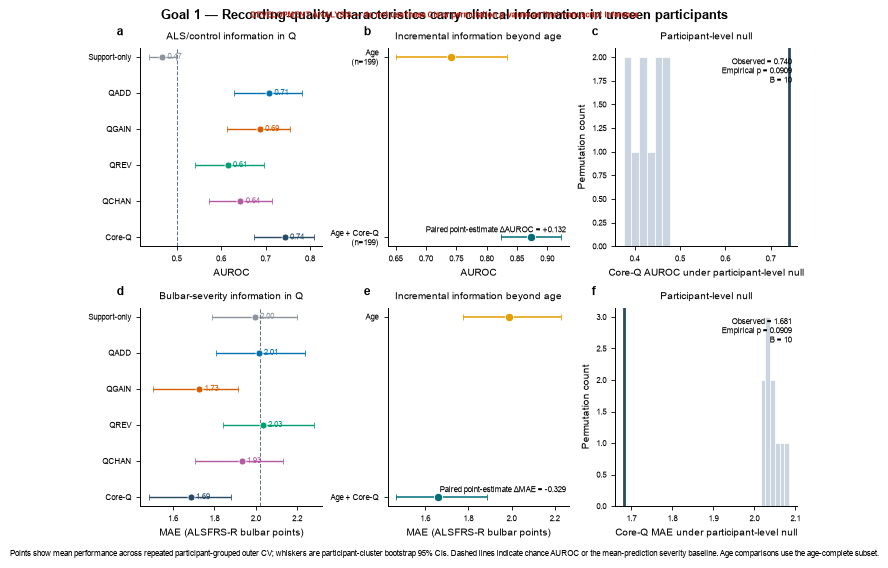

In [15]:
# ============================================================
# FIGURE 2 — GOAL 1
# CLINICAL INFORMATION AVAILABLE IN Q
#
# a  Q-family diagnosis performance
# b  Incremental diagnosis information beyond age
# c  Participant-level diagnosis permutation null
# d  Q-family bulbar severity performance
# e  Incremental severity information beyond age
# f  Participant-level severity permutation null
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        DOUBLE_COLUMN,
        132 * MM_TO_IN,
    ),
    constrained_layout=True,
)


# ------------------------------------------------------------
# A. Diagnosis by Q family
# ------------------------------------------------------------

ax = axes[0, 0]

dx_order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]

dx_family = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("diagnosis")
        & g1_metrics[
            "metric"
        ].eq("AUROC")
        & g1_metrics[
            "model"
        ].isin(dx_order)
    ]
    .set_index("model")
    .loc[dx_order]
    .reset_index()
)

for i, row in dx_family.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=safe_xerr(row),
        fmt="o",
        markersize=5,
        linewidth=1.0,
        capsize=2,
        color=COLORS[row["model"]],
        markerfacecolor=(
            COLORS[row["model"]]
        ),
        markeredgecolor="white",
        markeredgewidth=0.55,
        zorder=3,
    )

    ax.text(
        row["estimate"] + 0.012,
        i,
        f"{row['estimate']:.2f}",
        va="center",
        fontsize=5.7,
        color=COLORS[row["model"]],
    )

ax.axvline(
    0.50,
    linestyle="--",
    linewidth=0.75,
    color="#64748B",
)

ax.set_yticks(
    np.arange(len(dx_order))
)

ax.set_yticklabels(
    dx_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "AUROC"
)

ax.set_title(
    "ALS/control information in Q"
)

clean_axis(ax)
panel_label(ax, "a")


# ------------------------------------------------------------
# B. Incremental diagnosis information beyond age
# ------------------------------------------------------------

ax = axes[0, 1]

age_models = [
    "Age",
    "Age + Core-Q",
]

age_dx = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("diagnosis")
        & g1_metrics[
            "metric"
        ].eq("AUROC")
        & g1_metrics[
            "model"
        ].isin(age_models)
    ]
    .set_index("model")
    .loc[age_models]
    .reset_index()
)

for i, row in age_dx.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=safe_xerr(row),
        fmt="o",
        markersize=6,
        linewidth=1.1,
        capsize=2.5,
        color=COLORS[row["model"]],
        markerfacecolor=(
            COLORS[row["model"]]
        ),
        markeredgecolor="white",
        markeredgewidth=0.6,
    )

ax.set_yticks([0, 1])

ax.set_yticklabels([
    f"Age\n(n={int(age_dx.iloc[0]['n_participants'])})",
    (
        "Age + Core-Q\n"
        f"(n={int(age_dx.iloc[1]['n_participants'])})"
    ),
])

ax.invert_yaxis()

delta_dx = (
    age_dx.loc[
        age_dx["model"].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
    -
    age_dx.loc[
        age_dx["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ax.text(
    0.98,
    0.06,
    f"Paired point-estimate ΔAUROC = {delta_dx:+.3f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.8,
)

ax.set_xlabel(
    "AUROC"
)

ax.set_title(
    "Incremental information beyond age"
)

clean_axis(ax)
panel_label(ax, "b")


# ------------------------------------------------------------
# C. Diagnosis permutation null
# ------------------------------------------------------------

ax = axes[0, 2]

dx_perm = g1_perm.loc[
    g1_perm["task"].eq(
        "diagnosis"
    )
].copy()

observed_dx = float(
    dx_perm[
        "observed_metric"
    ].iloc[0]
)

p_dx = float(
    dx_perm[
        "empirical_p"
    ].iloc[0]
)

bins = max(
    6,
    min(
        30,
        int(
            np.sqrt(
                len(dx_perm)
            ) * 2
        ),
    ),
)

ax.hist(
    dx_perm["null_metric"],
    bins=bins,
    color="#CBD5E1",
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    observed_dx,
    color=COLORS["Core-Q"],
    linewidth=2.0,
)

ax.text(
    0.97,
    0.95,
    (
        f"Observed = {observed_dx:.3f}\n"
        f"Empirical p = {p_dx:.4f}\n"
        f"B = {len(dx_perm):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6,
)

ax.set_xlabel(
    "Core-Q AUROC under participant-level null"
)

ax.set_ylabel(
    "Permutation count"
)

ax.set_title(
    "Participant-level null"
)

clean_axis(ax)
panel_label(ax, "c")


# ------------------------------------------------------------
# D. Severity by Q family
# ------------------------------------------------------------

ax = axes[1, 0]

sev_order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]

sev_family = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("severity")
        & g1_metrics[
            "metric"
        ].eq("MAE")
        & g1_metrics[
            "model"
        ].isin(sev_order)
    ]
    .set_index("model")
    .loc[sev_order]
    .reset_index()
)

for i, row in sev_family.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=safe_xerr(row),
        fmt="o",
        markersize=5,
        linewidth=1.0,
        capsize=2,
        color=COLORS[row["model"]],
        markerfacecolor=(
            COLORS[row["model"]]
        ),
        markeredgecolor="white",
        markeredgewidth=0.55,
    )

    ax.text(
        row["estimate"] + 0.025,
        i,
        f"{row['estimate']:.2f}",
        va="center",
        fontsize=5.7,
        color=COLORS[row["model"]],
    )

baseline_mae = float(
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("severity")
        & g1_metrics[
            "metric"
        ].eq("MAE")
        & g1_metrics[
            "model"
        ].eq("Mean baseline"),
        "estimate",
    ].iloc[0]
)

ax.axvline(
    baseline_mae,
    linestyle="--",
    linewidth=0.75,
    color="#64748B",
)

ax.set_yticks(
    np.arange(len(sev_order))
)

ax.set_yticklabels(
    sev_order
)

ax.invert_yaxis()

ax.set_xlabel(
    "MAE (ALSFRS-R bulbar points)"
)

ax.set_title(
    "Bulbar-severity information in Q"
)

clean_axis(ax)
panel_label(ax, "d")


# ------------------------------------------------------------
# E. Incremental severity information beyond age
# ------------------------------------------------------------

ax = axes[1, 1]

age_sev = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("severity")
        & g1_metrics[
            "metric"
        ].eq("MAE")
        & g1_metrics[
            "model"
        ].isin(age_models)
    ]
    .set_index("model")
    .loc[age_models]
    .reset_index()
)

for i, row in age_sev.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=safe_xerr(row),
        fmt="o",
        markersize=6,
        linewidth=1.1,
        capsize=2.5,
        color=COLORS[row["model"]],
        markerfacecolor=(
            COLORS[row["model"]]
        ),
        markeredgecolor="white",
        markeredgewidth=0.6,
    )

ax.set_yticks([0, 1])

ax.set_yticklabels([
    "Age",
    "Age + Core-Q",
])

ax.invert_yaxis()

delta_sev = (
    age_sev.loc[
        age_sev["model"].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
    -
    age_sev.loc[
        age_sev["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ax.text(
    0.98,
    0.06,
    f"Paired point-estimate ΔMAE = {delta_sev:+.3f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.8,
)

ax.set_xlabel(
    "MAE (ALSFRS-R bulbar points)"
)

ax.set_title(
    "Incremental information beyond age"
)

clean_axis(ax)
panel_label(ax, "e")


# ------------------------------------------------------------
# F. Severity permutation null
# ------------------------------------------------------------

ax = axes[1, 2]

sev_perm = g1_perm.loc[
    g1_perm[
        "task"
    ].eq("severity")
].copy()

observed_sev = float(
    sev_perm[
        "observed_metric"
    ].iloc[0]
)

p_sev = float(
    sev_perm[
        "empirical_p"
    ].iloc[0]
)

bins = max(
    6,
    min(
        30,
        int(
            np.sqrt(
                len(sev_perm)
            ) * 2
        ),
    ),
)

ax.hist(
    sev_perm["null_metric"],
    bins=bins,
    color="#CBD5E1",
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    observed_sev,
    color=COLORS["Core-Q"],
    linewidth=2.0,
)

ax.text(
    0.97,
    0.95,
    (
        f"Observed = {observed_sev:.3f}\n"
        f"Empirical p = {p_sev:.4f}\n"
        f"B = {len(sev_perm):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=6,
)

ax.set_xlabel(
    "Core-Q MAE under participant-level null"
)

ax.set_ylabel(
    "Permutation count"
)

ax.set_title(
    "Participant-level null"
)

clean_axis(ax)
panel_label(ax, "f")


# ------------------------------------------------------------
# Figure-level explanation
# ------------------------------------------------------------

fig.suptitle(
    (
        "Goal 1 — Recording-quality characteristics "
        "carry clinical information in unseen participants"
    ),
    fontsize=9,
    fontweight="bold",
    y=1.025,
)

fig.text(
    0.5,
    -0.015,
    (
        "Points show mean performance across repeated participant-grouped "
        "outer CV; whiskers are participant-cluster bootstrap 95% CIs. "
        "Dashed lines indicate chance AUROC or the mean-prediction "
        "severity baseline. Age comparisons use the age-complete subset."
    ),
    ha="center",
    va="top",
    fontsize=5.7,
)


if RUN_LABEL != "FINAL":
    fig.text(
        0.5,
        1.005,
        (
            "DEVELOPMENT ANALYSIS — "
            "do not use these CIs or permutation p-values "
            "as final manuscript inference"
        ),
        ha="center",
        va="bottom",
        fontsize=6,
        fontweight="bold",
        color="#B42318",
    )


save_goal1_figure(
    fig,
    (
        "Figure2_Goal1_clinical_information_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_metrics.csv",
        "goal1_permutation.csv",
    ],
)

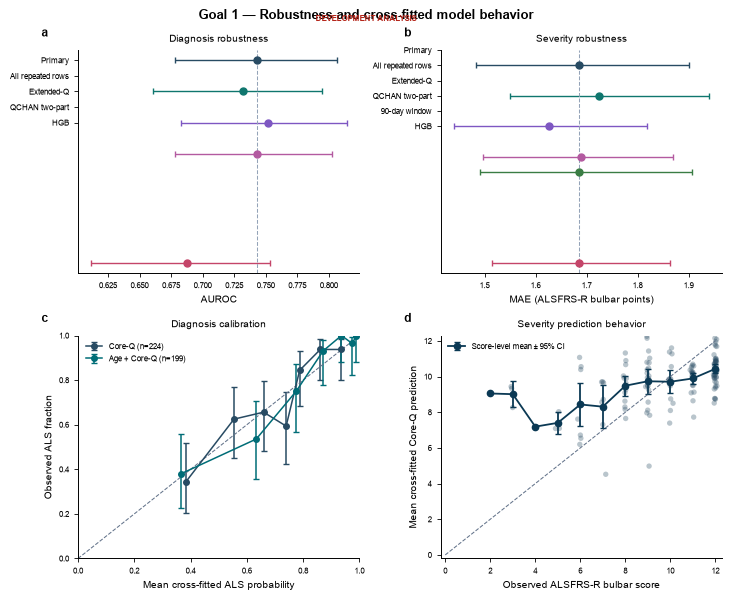

In [16]:
# ============================================================
# SUPPLEMENTARY — GOAL 1 ROBUSTNESS AND MODEL BEHAVIOR
#
# a Diagnosis robustness
# b Severity robustness
# c Diagnosis calibration
# d Severity observed vs cross-fitted prediction
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        DOUBLE_COLUMN,
        145 * MM_TO_IN,
    ),
    constrained_layout=True,
)


SENS_COLORS = {
    "Primary": "#284B63",
    "All repeated rows": "#0F766E",
    "Extended-Q": "#7E57C2",
    "QCHAN two-part": "#B35AA0",
    "90-day window": "#3A7D44",
    "HGB": "#C44569",
}


# ------------------------------------------------------------
# A. Diagnosis sensitivities
# ------------------------------------------------------------

ax = axes[0, 0]

dx_sens_map = [
    (
        "Primary index Core-Q",
        "Primary",
    ),
    (
        "All recordings, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in dx_sens_map:
    match = g1_sens.loc[
        g1_sens[
            "task"
        ].eq("diagnosis")
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(match):
        row = match.iloc[0].copy()
        row["plot_label"] = label
        rows.append(row)

dx_s = pd.DataFrame(rows)

for i, row in dx_s.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=np.array([
            [
                max(
                    0,
                    row["estimate"]
                    - row["ci_low"],
                )
            ],
            [
                max(
                    0,
                    row["ci_high"]
                    - row["estimate"],
                )
            ],
        ]),
        fmt="o",
        markersize=5,
        linewidth=1,
        capsize=2,
        color=SENS_COLORS[
            row["plot_label"]
        ],
    )

primary_dx = float(
    dx_s.loc[
        dx_s[
            "plot_label"
        ].eq("Primary"),
        "estimate",
    ].iloc[0]
)

ax.axvline(
    primary_dx,
    color="#94A3B8",
    linestyle="--",
    linewidth=0.75,
)

ax.set_yticks(
    np.arange(len(dx_s))
)

ax.set_yticklabels(
    dx_s["plot_label"]
)

ax.invert_yaxis()

ax.set_xlabel(
    "AUROC"
)

ax.set_title(
    "Diagnosis robustness"
)

clean_axis(ax)
panel_label(ax, "a")


# ------------------------------------------------------------
# B. Severity sensitivities
# ------------------------------------------------------------

ax = axes[0, 1]

sev_sens_map = [
    (
        "Primary ≤60 d Core-Q",
        "Primary",
    ),
    (
        "All ≤60 d pairs, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "≤90 d index Core-Q",
        "90-day window",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in sev_sens_map:
    match = g1_sens.loc[
        g1_sens[
            "task"
        ].eq("severity")
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(match):
        row = match.iloc[0].copy()
        row["plot_label"] = label
        rows.append(row)

sev_s = pd.DataFrame(rows)

for i, row in sev_s.iterrows():
    ax.errorbar(
        row["estimate"],
        i,
        xerr=np.array([
            [
                max(
                    0,
                    row["estimate"]
                    - row["ci_low"],
                )
            ],
            [
                max(
                    0,
                    row["ci_high"]
                    - row["estimate"],
                )
            ],
        ]),
        fmt="o",
        markersize=5,
        linewidth=1,
        capsize=2,
        color=SENS_COLORS[
            row["plot_label"]
        ],
    )

primary_sev = float(
    sev_s.loc[
        sev_s[
            "plot_label"
        ].eq("Primary"),
        "estimate",
    ].iloc[0]
)

ax.axvline(
    primary_sev,
    color="#94A3B8",
    linestyle="--",
    linewidth=0.75,
)

ax.set_yticks(
    np.arange(len(sev_s))
)

ax.set_yticklabels(
    sev_s["plot_label"]
)

ax.invert_yaxis()

ax.set_xlabel(
    "MAE (ALSFRS-R bulbar points)"
)

ax.set_title(
    "Severity robustness"
)

clean_axis(ax)
panel_label(ax, "b")


# ------------------------------------------------------------
# C. Quantile-binned diagnosis calibration
# ------------------------------------------------------------

ax = axes[1, 0]


def wilson_interval(
    successes,
    n,
    z=1.96,
):
    if n <= 0:
        return (
            np.nan,
            np.nan,
        )

    p = successes / n

    denominator = (
        1
        + z**2 / n
    )

    center = (
        p
        + z**2 / (2 * n)
    ) / denominator

    half = (
        z
        * np.sqrt(
            p * (1 - p) / n
            + z**2 / (4 * n**2)
        )
        / denominator
    )

    return (
        max(
            0,
            center - half,
        ),
        min(
            1,
            center + half,
        ),
    )


def calibration_bins(
    frame,
    q=7,
):
    temp = frame[
        [
            "true_outcome",
            "mean_oof_prediction",
        ]
    ].dropna().copy()

    temp["bin"] = pd.qcut(
        temp[
            "mean_oof_prediction"
        ],
        q=q,
        duplicates="drop",
    )

    rows = []

    for _, group in temp.groupby(
        "bin",
        observed=True,
    ):
        n = len(group)

        observed = float(
            group[
                "true_outcome"
            ].mean()
        )

        predicted = float(
            group[
                "mean_oof_prediction"
            ].mean()
        )

        low, high = wilson_interval(
            int(
                group[
                    "true_outcome"
                ].sum()
            ),
            n,
        )

        rows.append({
            "predicted": predicted,
            "observed": observed,
            "low": low,
            "high": high,
            "n": n,
        })

    return pd.DataFrame(rows)


for model in [
    "Core-Q",
    "Age + Core-Q",
]:
    source = g1_dx_oof.loc[
        g1_dx_oof[
            "model"
        ].eq(model)
    ].copy()

    calibration = (
        calibration_bins(
            source,
            q=7,
        )
    )

    color = COLORS[model]

    ax.errorbar(
        calibration["predicted"],
        calibration["observed"],
        yerr=np.vstack([
            calibration[
                "observed"
            ]
            - calibration["low"],
            calibration["high"]
            - calibration[
                "observed"
            ],
        ]),
        fmt="o-",
        linewidth=1.1,
        markersize=4,
        capsize=2,
        color=color,
        label=(
            f"{model} "
            f"(n={len(source)})"
        ),
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=0.75,
    color="#64748B",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel(
    "Mean cross-fitted ALS probability"
)

ax.set_ylabel(
    "Observed ALS fraction"
)

ax.set_title(
    "Diagnosis calibration"
)

ax.legend(
    frameon=False,
    loc="upper left",
)

clean_axis(ax)
panel_label(ax, "c")


# ------------------------------------------------------------
# D. Severity: observed vs predicted
# ------------------------------------------------------------

ax = axes[1, 1]

core_sev = g1_sev_oof.loc[
    g1_sev_oof[
        "model"
    ].eq("Core-Q")
].copy()

rng = np.random.default_rng(
    20260827
)

jitter = rng.normal(
    0,
    0.045,
    size=len(core_sev),
)

ax.scatter(
    core_sev[
        "true_outcome"
    ] + jitter,
    core_sev[
        "mean_oof_prediction"
    ],
    s=15,
    alpha=0.32,
    color=COLORS["Core-Q"],
    edgecolors="none",
)


score_summary = (
    core_sev.groupby(
        "true_outcome",
        as_index=False,
    )
    .agg(
        mean_prediction=(
            "mean_oof_prediction",
            "mean",
        ),
        sd_prediction=(
            "mean_oof_prediction",
            "std",
        ),
        n=(
            "participant_id",
            "size",
        ),
    )
)

score_summary["se"] = (
    score_summary[
        "sd_prediction"
    ]
    / np.sqrt(
        score_summary["n"]
    )
)

ax.errorbar(
    score_summary[
        "true_outcome"
    ],
    score_summary[
        "mean_prediction"
    ],
    yerr=(
        1.96
        * score_summary["se"]
    ),
    fmt="o-",
    linewidth=1.3,
    markersize=4.5,
    capsize=2,
    color="#0B3954",
    label="Score-level mean ± 95% CI",
)

ax.plot(
    [0, 12],
    [0, 12],
    linestyle="--",
    linewidth=0.75,
    color="#64748B",
)

ax.set_xlim(
    -0.2,
    12.3,
)

ax.set_ylim(
    -0.2,
    12.3,
)

ax.set_xlabel(
    "Observed ALSFRS-R bulbar score"
)

ax.set_ylabel(
    "Mean cross-fitted Core-Q prediction"
)

ax.set_title(
    "Severity prediction behavior"
)

ax.legend(
    frameon=False,
    loc="upper left",
)

clean_axis(ax)
panel_label(ax, "d")


fig.suptitle(
    (
        "Goal 1 — Robustness and "
        "cross-fitted model behavior"
    ),
    fontsize=9,
    fontweight="bold",
    y=1.025,
)


if RUN_LABEL != "FINAL":
    fig.text(
        0.5,
        1.004,
        "DEVELOPMENT ANALYSIS",
        ha="center",
        fontsize=6,
        fontweight="bold",
        color="#B42318",
    )


save_goal1_figure(
    fig,
    (
        "FigureS_Goal1_robustness_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_sensitivity_summary.csv",
        "goal1_dx_oof.csv",
        "goal1_bulbar_oof.csv",
    ],
)

In [17]:
# ============================================================
# GOAL 1 — PUBLICATION FIGURE SYSTEM v2
# Clean npj/Nature-style visual language
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import math

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Reload authoritative saved products
# ------------------------------------------------------------

def _g1_load(filename):
    candidates = []

    for variable in ["TABLES", "OOF_DIR", "OUT"]:
        value = globals().get(variable)
        if value is not None:
            candidates.append(Path(value) / filename)

    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            return pd.read_csv(path, low_memory=False)

    raise FileNotFoundError(
        f"Could not locate {filename} in TABLES / OOF_DIR / OUT."
    )


g1_metrics = _g1_load("goal1_metrics.csv")
g1_perm = _g1_load("goal1_permutation.csv")
g1_sens = _g1_load("goal1_sensitivity_summary.csv")
g1_dx_oof = _g1_load("goal1_dx_oof.csv")
g1_sev_oof = _g1_load("goal1_bulbar_oof.csv")


RUN_LABEL = str(
    globals().get(
        "RUN_MODE",
        (
            g1_perm["run_mode"].iloc[0]
            if "run_mode" in g1_perm.columns
            else "UNKNOWN"
        )
    )
).upper()

BOOTSTRAP_B = (
    int(g1_metrics["bootstrap_replicates"].max())
    if "bootstrap_replicates" in g1_metrics.columns
    else np.nan
)

PERMUTATION_B = int(
    g1_perm.groupby("task").size().max()
)


PUB_DIR = Path(FIGURES) / "publication_ready_v2"
PUB_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Sophisticated, muted, colorblind-friendly palette
# ------------------------------------------------------------

PAL = {
    # General
    "ink": "#243342",
    "ink_soft": "#52606D",
    "muted": "#A7B0BA",
    "light": "#DCE2E8",
    "very_light": "#F1F4F6",
    "reference": "#8190A0",

    # Q families
    "Support-only": "#A8B0B9",
    "QADD": "#3D78A8",        # muted steel blue
    "QGAIN": "#C67645",       # terracotta
    "QREV": "#52866B",        # sage green
    "QCHAN": "#846A98",       # muted plum
    "Core-Q": "#203D5B",      # deep navy

    # Benchmarks / sensitivities
    "Age": "#C79A38",         # ochre
    "Age + Core-Q": "#167C80",# deep teal
    "HGB": "#A64E6A",         # muted cranberry

    # Status
    "development": "#9D3F35",
    "final": "#36705B",
}


MODEL_COLORS = {
    key: PAL[key]
    for key in [
        "Support-only",
        "QADD",
        "QGAIN",
        "QREV",
        "QCHAN",
        "Core-Q",
        "Age",
        "Age + Core-Q",
    ]
}


# ------------------------------------------------------------
# Typography and geometry
# ------------------------------------------------------------

MM = 1 / 25.4
DOUBLE = 183 * MM

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 7.0,
    "axes.labelsize": 7.0,
    "axes.titlesize": 7.6,
    "xtick.labelsize": 6.3,
    "ytick.labelsize": 6.3,
    "legend.fontsize": 6.2,

    "axes.linewidth": 0.70,
    "xtick.major.width": 0.60,
    "ytick.major.width": 0.60,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})


def clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    ax.spines["left"].set_color(PAL["ink"])
    ax.spines["bottom"].set_color(PAL["ink"])


def panel_label(ax, letter):
    ax.text(
        -0.15, 1.055,
        letter,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        color=PAL["ink"],
        ha="left",
        va="bottom",
    )


def errorbar_x(ax, row, y, color, size=5):
    estimate = float(row["estimate"])
    lo = max(0, estimate - float(row["ci_low"]))
    hi = max(0, float(row["ci_high"]) - estimate)

    ax.errorbar(
        estimate,
        y,
        xerr=np.array([[lo], [hi]]),
        fmt="o",
        markersize=size,
        linewidth=1.05,
        elinewidth=1.05,
        capsize=2.2,
        capthick=0.8,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
        zorder=4,
    )


def add_run_badge(fig):
    if RUN_LABEL == "FINAL":
        label = "FINAL"
        face = "#EAF2EE"
        edge = PAL["final"]
        text = PAL["final"]
    else:
        label = f"{RUN_LABEL}"
        face = "#F7ECEA"
        edge = PAL["development"]
        text = PAL["development"]

    fig.text(
        0.988,
        0.987,
        label,
        ha="right",
        va="top",
        fontsize=5.7,
        fontweight="bold",
        color=text,
        bbox=dict(
            boxstyle="round,pad=0.28",
            facecolor=face,
            edgecolor=edge,
            linewidth=0.7,
        ),
    )


def save_pub(fig, stem, source_tables):
    for ext, kwargs in [
        ("pdf", {}),
        ("svg", {}),
        ("png", {"dpi": 600}),
    ]:
        fig.savefig(
            PUB_DIR / f"{stem}.{ext}",
            bbox_inches="tight",
            **kwargs,
        )

    provenance = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "run_mode": RUN_LABEL,
        "bootstrap_replicates": (
            int(BOOTSTRAP_B)
            if np.isfinite(BOOTSTRAP_B)
            else None
        ),
        "permutation_replicates": PERMUTATION_B,
        "source_tables": source_tables,
    }

    (
        PUB_DIR / f"{stem}.provenance.json"
    ).write_text(
        json.dumps(provenance, indent=2),
        encoding="utf-8",
    )

    plt.show()
    plt.close(fig)


print("Goal 1 publication style: READY")
print("Run:", RUN_LABEL)
print("Bootstrap B:", BOOTSTRAP_B)
print("Permutation B:", PERMUTATION_B)
print("Output:", PUB_DIR)

Goal 1 publication style: READY
Run: DEVELOPMENT
Bootstrap B: 300
Permutation B: 10
Output: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal1\goal1_complete_v1_1\development\figures\publication_ready_v2


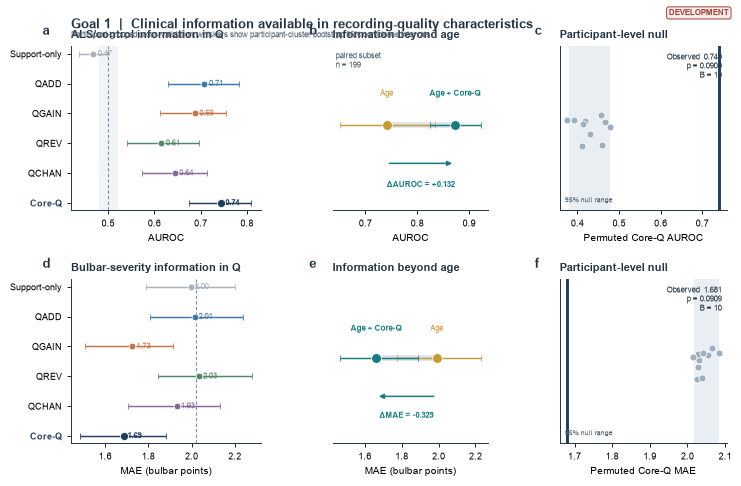

In [18]:
# ============================================================
# MAIN FIGURE 2 — GOAL 1
#
# a  Diagnosis information by Q family
# b  Incremental diagnosis information beyond age
# c  Diagnosis participant-level null
# d  Severity information by Q family
# e  Incremental severity information beyond age
# f  Severity participant-level null
# ============================================================

fig = plt.figure(
    figsize=(DOUBLE, 123 * MM),
)

gs = fig.add_gridspec(
    2, 3,
    width_ratios=[1.16, 0.95, 1.02],
    height_ratios=[1, 1],
    left=0.075,
    right=0.985,
    bottom=0.09,
    top=0.91,
    wspace=0.42,
    hspace=0.42,
)

axes = np.array([
    [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 2]),
    ],
    [
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[1, 2]),
    ],
])


# ============================================================
# A. DIAGNOSIS — Q FAMILY INFORMATION
# ============================================================

ax = axes[0, 0]

order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]

data = (
    g1_metrics.loc[
        g1_metrics["task"].eq("diagnosis")
        & g1_metrics["metric"].eq("AUROC")
        & g1_metrics["model"].isin(order)
    ]
    .set_index("model")
    .reindex(order)
    .reset_index()
)

y = np.arange(len(order))

# very subtle chance region
ax.axvspan(
    0.48, 0.52,
    color=PAL["very_light"],
    zorder=0,
)

ax.axvline(
    0.50,
    color=PAL["reference"],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    zorder=1,
)

for i, row in data.iterrows():
    model = row["model"]
    color = MODEL_COLORS[model]

    errorbar_x(
        ax, row, i, color,
        size=5.8 if model == "Core-Q" else 4.8,
    )

    ax.text(
        float(row["estimate"]) + 0.010,
        i,
        f"{float(row['estimate']):.2f}",
        va="center",
        ha="left",
        fontsize=5.7,
        fontweight=(
            "bold"
            if model == "Core-Q"
            else "normal"
        ),
        color=color,
    )

ax.set_yticks(y)
ax.set_yticklabels(order)

for tick, model in zip(
    ax.get_yticklabels(),
    order,
):
    if model == "Core-Q":
        tick.set_fontweight("bold")
        tick.set_color(PAL["Core-Q"])

ax.invert_yaxis()
ax.set_xlim(0.42, 0.83)
ax.set_xlabel("AUROC")
ax.set_title(
    "ALS/control information in Q",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
panel_label(ax, "a")


# ============================================================
# B. DIAGNOSIS — AGE INCREMENT
# ============================================================

ax = axes[0, 1]

age_dx = (
    g1_metrics.loc[
        g1_metrics["task"].eq("diagnosis")
        & g1_metrics["metric"].eq("AUROC")
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)

age_est = float(
    age_dx.loc[
        age_dx["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_dx.loc[
        age_dx["model"].eq("Age + Core-Q"),
        "estimate",
    ].iloc[0]
)

# connecting dumbbell
ax.plot(
    [age_est, ageq_est],
    [0, 0],
    color=PAL["light"],
    linewidth=4.0,
    solid_capstyle="round",
    zorder=1,
)

for _, row in age_dx.iterrows():
    model = row["model"]
    errorbar_x(
        ax,
        row,
        0,
        MODEL_COLORS[model],
        size=7,
    )

# labels at each point
ax.text(
    age_est,
    0.19,
    "Age",
    ha="center",
    va="bottom",
    fontsize=6,
    color=PAL["Age"],
)

ax.text(
    ageq_est,
    0.19,
    "Age + Core-Q",
    ha="center",
    va="bottom",
    fontsize=6,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

delta = ageq_est - age_est

ax.annotate(
    "",
    xy=(ageq_est, -0.27),
    xytext=(age_est, -0.27),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL["Age + Core-Q"],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)

ax.text(
    (age_est + ageq_est) / 2,
    -0.42,
    f"ΔAUROC = {delta:+.3f}",
    ha="center",
    va="center",
    fontsize=6.1,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

n_age = int(
    age_dx["n_participants"].iloc[0]
)

ax.text(
    0.02,
    0.97,
    f"paired subset\nn = {n_age}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=5.7,
    color=PAL["ink_soft"],
)

ax.set_ylim(-0.60, 0.55)
ax.set_yticks([])
ax.set_xlabel("AUROC")
ax.set_title(
    "Information beyond age",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
ax.spines["left"].set_visible(False)
panel_label(ax, "b")


# ============================================================
# C. DIAGNOSIS — PARTICIPANT NULL
# ============================================================

ax = axes[0, 2]

null = g1_perm.loc[
    g1_perm["task"].eq("diagnosis")
].copy()

null_values = pd.to_numeric(
    null["null_metric"],
    errors="coerce",
).dropna().to_numpy()

observed = float(
    null["observed_metric"].iloc[0]
)

p_value = float(
    null["empirical_p"].iloc[0]
)

q025, q975 = np.quantile(
    null_values,
    [0.025, 0.975],
)

ax.axvspan(
    q025,
    q975,
    color="#E9EEF3",
    zorder=0,
)

if len(null_values) >= 40:
    bins = min(
        30,
        max(
            12,
            int(np.sqrt(len(null_values))),
        ),
    )

    ax.hist(
        null_values,
        bins=bins,
        density=True,
        color="#B7C5D3",
        alpha=0.80,
        edgecolor="white",
        linewidth=0.45,
    )

    # rug
    ymin, ymax = ax.get_ylim()
    rug_height = ymax * 0.035

    for value in null_values:
        ax.plot(
            [value, value],
            [0, rug_height],
            color="#71869A",
            alpha=0.20,
            linewidth=0.45,
        )

    ax.set_ylabel("Null density")

else:
    # Development B=10: use clean strip rather than ugly histogram.
    rng = np.random.default_rng(20260827)

    jitter = rng.uniform(
        -0.07,
        0.07,
        len(null_values),
    )

    ax.scatter(
        null_values,
        np.ones(len(null_values)) + jitter,
        s=25,
        color="#9EB0C0",
        edgecolor="white",
        linewidth=0.55,
        zorder=3,
    )

    ax.set_ylim(0.72, 1.28)
    ax.set_yticks([])
    ax.set_ylabel("")

ax.axvline(
    observed,
    color=PAL["Core-Q"],
    linewidth=2.1,
    zorder=4,
)

ax.text(
    0.97,
    0.96,
    (
        f"Observed  {observed:.3f}\n"
        f"p = {p_value:.4f}\n"
        f"B = {len(null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.8,
    color=PAL["ink"],
)

ax.text(
    0.03,
    0.05,
    "95% null range",
    transform=ax.transAxes,
    fontsize=5.3,
    color=PAL["ink_soft"],
)

ax.set_xlabel("Permuted Core-Q AUROC")
ax.set_title(
    "Participant-level null",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
panel_label(ax, "c")


# ============================================================
# D. SEVERITY — Q FAMILY INFORMATION
# ============================================================

ax = axes[1, 0]

data = (
    g1_metrics.loc[
        g1_metrics["task"].eq("severity")
        & g1_metrics["metric"].eq("MAE")
        & g1_metrics["model"].isin(order)
    ]
    .set_index("model")
    .reindex(order)
    .reset_index()
)

baseline_row = g1_metrics.loc[
    g1_metrics["task"].eq("severity")
    & g1_metrics["metric"].eq("MAE")
    & g1_metrics["model"].eq("Mean baseline")
]

baseline = (
    float(baseline_row["estimate"].iloc[0])
    if len(baseline_row)
    else 2.0
)

ax.axvline(
    baseline,
    color=PAL["reference"],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
)

for i, row in data.iterrows():
    model = row["model"]
    color = MODEL_COLORS[model]

    errorbar_x(
        ax, row, i, color,
        size=5.8 if model == "Core-Q" else 4.8,
    )

    ax.text(
        float(row["estimate"]) + 0.018,
        i,
        f"{float(row['estimate']):.2f}",
        va="center",
        ha="left",
        fontsize=5.7,
        fontweight=(
            "bold"
            if model == "Core-Q"
            else "normal"
        ),
        color=color,
    )

ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order)

for tick, model in zip(
    ax.get_yticklabels(),
    order,
):
    if model == "Core-Q":
        tick.set_fontweight("bold")
        tick.set_color(PAL["Core-Q"])

ax.invert_yaxis()
ax.set_xlabel("MAE (bulbar points)")
ax.set_title(
    "Bulbar-severity information in Q",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
panel_label(ax, "d")


# ============================================================
# E. SEVERITY — AGE INCREMENT
# ============================================================

ax = axes[1, 1]

age_sev = (
    g1_metrics.loc[
        g1_metrics["task"].eq("severity")
        & g1_metrics["metric"].eq("MAE")
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)

age_est = float(
    age_sev.loc[
        age_sev["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_sev.loc[
        age_sev["model"].eq("Age + Core-Q"),
        "estimate",
    ].iloc[0]
)

ax.plot(
    [age_est, ageq_est],
    [0, 0],
    color=PAL["light"],
    linewidth=4.0,
    solid_capstyle="round",
)

for _, row in age_sev.iterrows():
    model = row["model"]

    errorbar_x(
        ax,
        row,
        0,
        MODEL_COLORS[model],
        size=7,
    )

ax.text(
    age_est,
    0.19,
    "Age",
    ha="center",
    fontsize=6,
    color=PAL["Age"],
)

ax.text(
    ageq_est,
    0.19,
    "Age + Core-Q",
    ha="center",
    fontsize=6,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

delta = ageq_est - age_est

# Improvement for MAE goes LEFT.
ax.annotate(
    "",
    xy=(ageq_est, -0.27),
    xytext=(age_est, -0.27),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL["Age + Core-Q"],
        linewidth=1.1,
    ),
)

ax.text(
    (age_est + ageq_est) / 2,
    -0.42,
    f"ΔMAE = {delta:+.3f}",
    ha="center",
    fontsize=6.1,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

ax.set_ylim(-0.60, 0.55)
ax.set_yticks([])
ax.set_xlabel("MAE (bulbar points)")
ax.set_title(
    "Information beyond age",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
ax.spines["left"].set_visible(False)
panel_label(ax, "e")


# ============================================================
# F. SEVERITY — PARTICIPANT NULL
# ============================================================

ax = axes[1, 2]

null = g1_perm.loc[
    g1_perm["task"].eq("severity")
].copy()

null_values = pd.to_numeric(
    null["null_metric"],
    errors="coerce",
).dropna().to_numpy()

observed = float(
    null["observed_metric"].iloc[0]
)

p_value = float(
    null["empirical_p"].iloc[0]
)

q025, q975 = np.quantile(
    null_values,
    [0.025, 0.975],
)

ax.axvspan(
    q025,
    q975,
    color="#E9EEF3",
    zorder=0,
)

if len(null_values) >= 40:
    bins = min(
        30,
        max(
            12,
            int(np.sqrt(len(null_values))),
        ),
    )

    ax.hist(
        null_values,
        bins=bins,
        density=True,
        color="#B7C5D3",
        alpha=0.80,
        edgecolor="white",
        linewidth=0.45,
    )

    ax.set_ylabel("Null density")

else:
    rng = np.random.default_rng(20260827)

    jitter = rng.uniform(
        -0.07,
        0.07,
        len(null_values),
    )

    ax.scatter(
        null_values,
        np.ones(len(null_values)) + jitter,
        s=25,
        color="#9EB0C0",
        edgecolor="white",
        linewidth=0.55,
    )

    ax.set_ylim(0.72, 1.28)
    ax.set_yticks([])
    ax.set_ylabel("")

ax.axvline(
    observed,
    color=PAL["Core-Q"],
    linewidth=2.1,
)

ax.text(
    0.97,
    0.96,
    (
        f"Observed  {observed:.3f}\n"
        f"p = {p_value:.4f}\n"
        f"B = {len(null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.8,
    color=PAL["ink"],
)

ax.text(
    0.03,
    0.05,
    "95% null range",
    transform=ax.transAxes,
    fontsize=5.3,
    color=PAL["ink_soft"],
)

ax.set_xlabel("Permuted Core-Q MAE")
ax.set_title(
    "Participant-level null",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax)
panel_label(ax, "f")


# ============================================================
# Figure heading — deliberately modest, no collision
# ============================================================

fig.text(
    0.075,
    0.968,
    "Goal 1  |  Clinical information available in recording-quality characteristics",
    fontsize=9.2,
    fontweight="bold",
    color=PAL["ink"],
    ha="left",
    va="top",
)

fig.text(
    0.075,
    0.942,
    (
        "Participant-grouped cross-validation; "
        "whiskers show participant-cluster bootstrap 95% confidence intervals."
    ),
    fontsize=5.8,
    color=PAL["ink_soft"],
    ha="left",
    va="top",
)

add_run_badge(fig)

save_pub(
    fig,
    f"Figure2_Goal1_publication_v2_{RUN_LABEL.lower()}",
    [
        "goal1_metrics.csv",
        "goal1_permutation.csv",
    ],
)

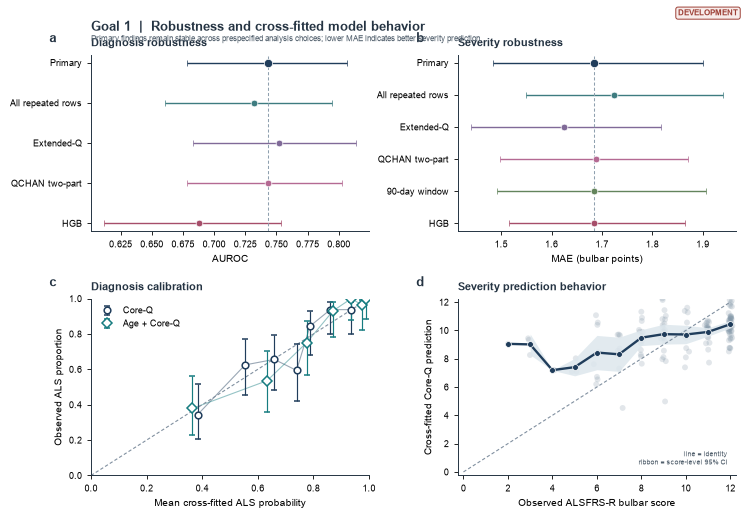

In [19]:
# ============================================================
# SUPPLEMENTARY FIGURE — GOAL 1
#
# a Diagnosis robustness
# b Severity robustness
# c Diagnosis calibration
# d Severity prediction behavior
# ============================================================

fig = plt.figure(
    figsize=(DOUBLE, 132 * MM),
)

gs = fig.add_gridspec(
    2, 2,
    left=0.09,
    right=0.985,
    bottom=0.09,
    top=0.90,
    wspace=0.32,
    hspace=0.38,
)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])


SENS_PAL = {
    "Primary": "#203D5B",
    "All repeated rows": "#3E7C80",
    "Extended-Q": "#806A98",
    "QCHAN two-part": "#B46A93",
    "90-day window": "#63845C",
    "HGB": "#A64E6A",
}


# ============================================================
# A. DIAGNOSIS SENSITIVITY
# ============================================================

dx_map = [
    ("Primary index Core-Q", "Primary"),
    (
        "All recordings, participant-weighted",
        "All repeated rows",
    ),
    ("Extended-Q", "Extended-Q"),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    ("Core-Q HGB", "HGB"),
]

rows = []

for source_name, label in dx_map:
    hit = g1_sens.loc[
        g1_sens["task"].eq("diagnosis")
        & g1_sens["sensitivity"].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

dx_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in dx_s.iterrows():
    color = SENS_PAL[row["plot_label"]]

    estimate = float(row["estimate"])
    lo = max(0, estimate - float(row["ci_low"]))
    hi = max(0, float(row["ci_high"]) - estimate)

    ax_a.errorbar(
        estimate,
        y,
        xerr=np.array([[lo], [hi]]),
        fmt="o",
        markersize=(
            6 if row["plot_label"] == "Primary"
            else 4.8
        ),
        linewidth=1,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.5,
    )

primary_dx = float(
    dx_s.loc[
        dx_s["plot_label"].eq("Primary"),
        "estimate",
    ].iloc[0]
)

ax_a.axvline(
    primary_dx,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_a.set_yticks(
    np.arange(len(dx_s))
)

ax_a.set_yticklabels(
    dx_s["plot_label"]
)

ax_a.invert_yaxis()
ax_a.set_xlabel("AUROC")
ax_a.set_title(
    "Diagnosis robustness",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax_a)
panel_label(ax_a, "a")


# ============================================================
# B. SEVERITY SENSITIVITY
# ============================================================

sev_map = [
    ("Primary ≤60 d Core-Q", "Primary"),
    (
        "All ≤60 d pairs, participant-weighted",
        "All repeated rows",
    ),
    ("Extended-Q", "Extended-Q"),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "≤90 d index Core-Q",
        "90-day window",
    ),
    ("Core-Q HGB", "HGB"),
]

rows = []

for source_name, label in sev_map:
    hit = g1_sens.loc[
        g1_sens["task"].eq("severity")
        & g1_sens["sensitivity"].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

sev_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in sev_s.iterrows():
    color = SENS_PAL[row["plot_label"]]

    estimate = float(row["estimate"])
    lo = max(0, estimate - float(row["ci_low"]))
    hi = max(0, float(row["ci_high"]) - estimate)

    ax_b.errorbar(
        estimate,
        y,
        xerr=np.array([[lo], [hi]]),
        fmt="o",
        markersize=(
            6 if row["plot_label"] == "Primary"
            else 4.8
        ),
        linewidth=1,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.5,
    )

primary_sev = float(
    sev_s.loc[
        sev_s["plot_label"].eq("Primary"),
        "estimate",
    ].iloc[0]
)

ax_b.axvline(
    primary_sev,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_b.set_yticks(
    np.arange(len(sev_s))
)

ax_b.set_yticklabels(
    sev_s["plot_label"]
)

ax_b.invert_yaxis()
ax_b.set_xlabel(
    "MAE (bulbar points)"
)
ax_b.set_title(
    "Severity robustness",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

clean_axis(ax_b)
panel_label(ax_b, "b")


# ============================================================
# C. DIAGNOSIS CALIBRATION
# ============================================================

def wilson(successes, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = successes / n

    denom = 1 + z**2 / n

    center = (
        p + z**2 / (2 * n)
    ) / denom

    half = (
        z
        * np.sqrt(
            p * (1 - p) / n
            + z**2 / (4 * n**2)
        )
        / denom
    )

    return (
        max(0, center - half),
        min(1, center + half),
    )


def make_calibration(frame, q=7):
    d = frame[
        [
            "true_outcome",
            "mean_oof_prediction",
        ]
    ].dropna().copy()

    d["bin"] = pd.qcut(
        d["mean_oof_prediction"],
        q=q,
        duplicates="drop",
    )

    rows = []

    for _, g in d.groupby(
        "bin",
        observed=True,
    ):
        n = len(g)
        successes = int(
            g["true_outcome"].sum()
        )

        lo, hi = wilson(
            successes,
            n,
        )

        rows.append({
            "pred": float(
                g["mean_oof_prediction"].mean()
            ),
            "obs": float(
                g["true_outcome"].mean()
            ),
            "lo": lo,
            "hi": hi,
            "n": n,
        })

    return pd.DataFrame(rows)


cal_models = [
    (
        "Core-Q",
        PAL["Core-Q"],
        "o",
    ),
    (
        "Age + Core-Q",
        PAL["Age + Core-Q"],
        "D",
    ),
]

for model, color, marker in cal_models:
    source = g1_dx_oof.loc[
        g1_dx_oof["model"].eq(model)
    ].copy()

    cal = make_calibration(
        source,
        q=7,
    )

    yerr = np.vstack([
        cal["obs"] - cal["lo"],
        cal["hi"] - cal["obs"],
    ])

    # subtle spline-free connector purely visual
    ax_c.plot(
        cal["pred"],
        cal["obs"],
        color=color,
        alpha=0.45,
        linewidth=0.8,
        zorder=1,
    )

    ax_c.errorbar(
        cal["pred"],
        cal["obs"],
        yerr=yerr,
        fmt=marker,
        markersize=4.8,
        capsize=2,
        linewidth=0.85,
        color=color,
        markerfacecolor="white",
        markeredgewidth=1.1,
        label=model,
        zorder=3,
    )

ax_c.plot(
    [0, 1],
    [0, 1],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_c.set_xlim(0, 1)
ax_c.set_ylim(0, 1)

ax_c.set_xlabel(
    "Mean cross-fitted ALS probability"
)

ax_c.set_ylabel(
    "Observed ALS proportion"
)

ax_c.set_title(
    "Diagnosis calibration",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

ax_c.legend(
    frameon=False,
    loc="upper left",
)

clean_axis(ax_c)
panel_label(ax_c, "c")


# ============================================================
# D. SEVERITY PREDICTION BEHAVIOR
# ============================================================

core = g1_sev_oof.loc[
    g1_sev_oof["model"].eq("Core-Q")
].copy()

rng = np.random.default_rng(
    20260827
)

x_jitter = (
    core["true_outcome"].to_numpy(float)
    + rng.normal(
        0,
        0.055,
        len(core),
    )
)

# raw participant points
ax_d.scatter(
    x_jitter,
    core[
        "mean_oof_prediction"
    ],
    s=18,
    alpha=0.23,
    color="#8297A8",
    edgecolors="none",
    zorder=1,
)

# score-level summaries
summary = (
    core.groupby(
        "true_outcome",
        as_index=False,
    )
    .agg(
        prediction=(
            "mean_oof_prediction",
            "mean",
        ),
        sd=(
            "mean_oof_prediction",
            "std",
        ),
        n=(
            "participant_id",
            "size",
        ),
    )
)

summary["se"] = (
    summary["sd"]
    / np.sqrt(summary["n"])
)

# light ribbon around score-level means
ax_d.fill_between(
    summary["true_outcome"],
    summary["prediction"] - 1.96 * summary["se"],
    summary["prediction"] + 1.96 * summary["se"],
    color="#DDE7ED",
    alpha=0.85,
    linewidth=0,
    zorder=2,
)

ax_d.plot(
    summary["true_outcome"],
    summary["prediction"],
    color=PAL["Core-Q"],
    linewidth=1.7,
    marker="o",
    markersize=4.2,
    markerfacecolor=PAL["Core-Q"],
    markeredgecolor="white",
    markeredgewidth=0.5,
    zorder=3,
)

ax_d.plot(
    [0, 12],
    [0, 12],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_d.set_xlim(-0.25, 12.25)
ax_d.set_ylim(-0.25, 12.25)

ax_d.set_xlabel(
    "Observed ALSFRS-R bulbar score"
)

ax_d.set_ylabel(
    "Cross-fitted Core-Q prediction"
)

ax_d.set_title(
    "Severity prediction behavior",
    loc="left",
    fontweight="bold",
    color=PAL["ink"],
)

ax_d.text(
    0.97,
    0.05,
    "line = identity\nribbon = score-level 95% CI",
    transform=ax_d.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.4,
    color=PAL["ink_soft"],
)

clean_axis(ax_d)
panel_label(ax_d, "d")


# ============================================================
# Figure heading
# ============================================================

fig.text(
    0.09,
    0.965,
    "Goal 1  |  Robustness and cross-fitted model behavior",
    fontsize=9.2,
    fontweight="bold",
    color=PAL["ink"],
    ha="left",
    va="top",
)

fig.text(
    0.09,
    0.938,
    (
        "Primary findings remain stable across prespecified analysis choices; "
        "lower MAE indicates better severity prediction."
    ),
    fontsize=5.8,
    color=PAL["ink_soft"],
    ha="left",
    va="top",
)

add_run_badge(fig)

save_pub(
    fig,
    f"FigureS_Goal1_robustness_v2_{RUN_LABEL.lower()}",
    [
        "goal1_sensitivity_summary.csv",
        "goal1_dx_oof.csv",
        "goal1_bulbar_oof.csv",
    ],
)

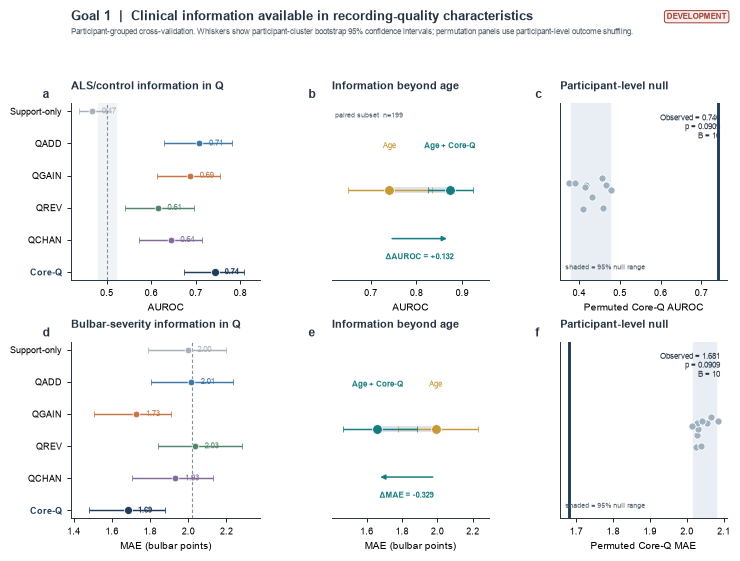

In [20]:
# ============================================================
# MAIN FIGURE 2 — GOAL 1 — LAYOUT-SAFE VERSION
#
# Dedicated header row prevents all title/panel overlap.
# ============================================================

fig = plt.figure(
    figsize=(DOUBLE, 142 * MM),
    facecolor="white",
)

# A true header row + two independent data rows.
gs = fig.add_gridspec(
    nrows=3,
    ncols=3,
    height_ratios=[0.18, 1.0, 1.0],
    width_ratios=[1.16, 0.96, 1.02],
    left=0.075,
    right=0.985,
    bottom=0.075,
    top=0.985,
    wspace=0.42,
    hspace=0.48,
)

# ============================================================
# HEADER — completely separate from plotting axes
# ============================================================

header = fig.add_subplot(gs[0, :])
header.axis("off")

header.text(
    0.00,
    0.78,
    "Goal 1  |  Clinical information available in recording-quality characteristics",
    ha="left",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=PAL["ink"],
)

header.text(
    0.00,
    0.30,
    (
        "Participant-grouped cross-validation. "
        "Whiskers show participant-cluster bootstrap 95% confidence intervals; "
        "permutation panels use participant-level outcome shuffling."
    ),
    ha="left",
    va="center",
    fontsize=5.8,
    color=PAL["ink_soft"],
)

if RUN_LABEL == "FINAL":
    badge_text = "FINAL"
    badge_face = "#EAF2EE"
    badge_edge = PAL["final"]
    badge_color = PAL["final"]
else:
    badge_text = RUN_LABEL
    badge_face = "#F7ECEA"
    badge_edge = PAL["development"]
    badge_color = PAL["development"]

header.text(
    1.00,
    0.78,
    badge_text,
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color=badge_color,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor=badge_face,
        edgecolor=badge_edge,
        linewidth=0.7,
    ),
)


# ============================================================
# DATA AXES
# ============================================================

ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[1, 2])

ax_d = fig.add_subplot(gs[2, 0])
ax_e = fig.add_subplot(gs[2, 1])
ax_f = fig.add_subplot(gs[2, 2])


def safe_panel_label(ax, letter):
    """
    Panel letter sits outside the plot but below the dedicated header.
    Cannot collide with figure title.
    """
    ax.text(
        -0.15,
        1.015,
        letter,
        transform=ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        color=PAL["ink"],
        ha="left",
        va="bottom",
        clip_on=False,
    )


def left_panel_title(ax, text):
    ax.set_title(
        text,
        loc="left",
        pad=10,
        fontsize=7.6,
        fontweight="bold",
        color=PAL["ink"],
    )


# ============================================================
# a. DIAGNOSIS — Q FAMILY INFORMATION
# ============================================================

ax = ax_a

family_order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]

data = (
    g1_metrics.loc[
        g1_metrics["task"].eq("diagnosis")
        & g1_metrics["metric"].eq("AUROC")
        & g1_metrics["model"].isin(family_order)
    ]
    .set_index("model")
    .reindex(family_order)
    .reset_index()
)

ax.axvspan(
    0.48,
    0.52,
    color=PAL["very_light"],
    zorder=0,
)

ax.axvline(
    0.50,
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
    zorder=1,
)

for i, row in data.iterrows():

    model = row["model"]
    color = MODEL_COLORS[model]

    errorbar_x(
        ax,
        row,
        i,
        color,
        size=5.8 if model == "Core-Q" else 4.8,
    )

    # Keep values safely inside the plotting region.
    ax.annotate(
        f"{float(row['estimate']):.2f}",
        xy=(
            float(row["estimate"]),
            i,
        ),
        xytext=(7, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=5.5,
        fontweight=(
            "bold"
            if model == "Core-Q"
            else "normal"
        ),
        color=color,
    )

ax.set_yticks(
    np.arange(len(family_order))
)
ax.set_yticklabels(
    family_order
)

for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):
    if model == "Core-Q":
        tick.set_fontweight("bold")
        tick.set_color(PAL["Core-Q"])

ax.invert_yaxis()

# Extra horizontal room so numeric annotations cannot hit border.
ax.set_xlim(
    0.42,
    0.845,
)

ax.set_xlabel("AUROC")

left_panel_title(
    ax,
    "ALS/control information in Q",
)

clean_axis(ax)
safe_panel_label(ax, "a")


# ============================================================
# b. DIAGNOSIS — INFORMATION BEYOND AGE
# ============================================================

ax = ax_b

age_dx = (
    g1_metrics.loc[
        g1_metrics["task"].eq("diagnosis")
        & g1_metrics["metric"].eq("AUROC")
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)

age_est = float(
    age_dx.loc[
        age_dx["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_dx.loc[
        age_dx["model"].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)

# Connector behind points.
ax.plot(
    [age_est, ageq_est],
    [0, 0],
    color=PAL["light"],
    linewidth=4.2,
    solid_capstyle="round",
    zorder=1,
)

for _, row in age_dx.iterrows():

    model = row["model"]

    errorbar_x(
        ax,
        row,
        0,
        MODEL_COLORS[model],
        size=7,
    )

# Labels placed ABOVE their own points with sufficient separation.
ax.annotate(
    "Age",
    xy=(age_est, 0),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL["Age"],
)

ax.annotate(
    "Age + Core-Q",
    xy=(ageq_est, 0),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

delta_dx = ageq_est - age_est

# Difference arrow below.
arrow_y = -0.43

ax.annotate(
    "",
    xy=(ageq_est, arrow_y),
    xytext=(age_est, arrow_y),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL["Age + Core-Q"],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)

ax.text(
    (age_est + ageq_est) / 2,
    arrow_y - 0.13,
    f"ΔAUROC = {delta_dx:+.3f}",
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

n_age = int(
    age_dx["n_participants"].iloc[0]
)

ax.text(
    0.02,
    0.95,
    f"paired subset  n={n_age}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=5.4,
    color=PAL["ink_soft"],
)

ax.set_ylim(
    -0.80,
    0.78,
)
ax.set_yticks([])

# Slightly generous x limits prevent CI clipping.
xmin = min(age_dx["ci_low"]) - 0.035
xmax = max(age_dx["ci_high"]) + 0.035

ax.set_xlim(xmin, xmax)
ax.set_xlabel("AUROC")

left_panel_title(
    ax,
    "Information beyond age",
)

clean_axis(ax)
ax.spines["left"].set_visible(False)

safe_panel_label(ax, "b")


# ============================================================
# c. DIAGNOSIS — PARTICIPANT NULL
# ============================================================

ax = ax_c

null = g1_perm.loc[
    g1_perm["task"].eq("diagnosis")
].copy()

null_values = (
    pd.to_numeric(
        null["null_metric"],
        errors="coerce",
    )
    .dropna()
    .to_numpy()
)

observed = float(
    null["observed_metric"].iloc[0]
)

p_value = float(
    null["empirical_p"].iloc[0]
)

q025, q975 = np.quantile(
    null_values,
    [0.025, 0.975],
)

ax.axvspan(
    q025,
    q975,
    color="#E8EEF3",
    zorder=0,
)

if len(null_values) >= 40:

    bins = min(
        30,
        max(
            12,
            int(np.sqrt(len(null_values))),
        ),
    )

    ax.hist(
        null_values,
        bins=bins,
        density=True,
        color="#AFC0CE",
        edgecolor="white",
        linewidth=0.45,
    )

    ax.set_ylabel("Null density")

else:

    rng = np.random.default_rng(
        20260827
    )

    jitter = rng.uniform(
        -0.065,
        0.065,
        len(null_values),
    )

    ax.scatter(
        null_values,
        np.ones(len(null_values)) + jitter,
        s=27,
        color="#9FB1C0",
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    ax.set_ylim(
        0.72,
        1.28,
    )
    ax.set_yticks([])

ax.axvline(
    observed,
    color=PAL["Core-Q"],
    linewidth=2.1,
    zorder=4,
)

# Keep annotation away from observed line.
ax.text(
    0.96,
    0.94,
    (
        f"Observed = {observed:.3f}\n"
        f"p = {p_value:.4f}\n"
        f"B = {len(null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.6,
    color=PAL["ink"],
)

ax.text(
    0.03,
    0.06,
    "shaded = 95% null range",
    transform=ax.transAxes,
    fontsize=5.1,
    color=PAL["ink_soft"],
)

all_dx_x = np.r_[
    null_values,
    observed,
]

dx_pad = (
    max(all_dx_x)
    - min(all_dx_x)
) * 0.06

ax.set_xlim(
    min(all_dx_x) - dx_pad,
    max(all_dx_x) + dx_pad,
)

ax.set_xlabel(
    "Permuted Core-Q AUROC"
)

left_panel_title(
    ax,
    "Participant-level null",
)

clean_axis(ax)
safe_panel_label(ax, "c")


# ============================================================
# d. SEVERITY — Q FAMILY INFORMATION
# ============================================================

ax = ax_d

data = (
    g1_metrics.loc[
        g1_metrics["task"].eq("severity")
        & g1_metrics["metric"].eq("MAE")
        & g1_metrics["model"].isin(family_order)
    ]
    .set_index("model")
    .reindex(family_order)
    .reset_index()
)

baseline_row = g1_metrics.loc[
    g1_metrics["task"].eq("severity")
    & g1_metrics["metric"].eq("MAE")
    & g1_metrics["model"].eq(
        "Mean baseline"
    )
]

baseline = float(
    baseline_row["estimate"].iloc[0]
)

ax.axvline(
    baseline,
    color=PAL["reference"],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
)

for i, row in data.iterrows():

    model = row["model"]
    color = MODEL_COLORS[model]

    errorbar_x(
        ax,
        row,
        i,
        color,
        size=5.8 if model == "Core-Q" else 4.8,
    )

    ax.annotate(
        f"{float(row['estimate']):.2f}",
        xy=(
            float(row["estimate"]),
            i,
        ),
        xytext=(7, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=5.5,
        fontweight=(
            "bold"
            if model == "Core-Q"
            else "normal"
        ),
        color=color,
    )

ax.set_yticks(
    np.arange(len(family_order))
)
ax.set_yticklabels(
    family_order
)

for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):
    if model == "Core-Q":
        tick.set_fontweight("bold")
        tick.set_color(PAL["Core-Q"])

ax.invert_yaxis()

sev_min = float(
    data["ci_low"].min()
)
sev_max = float(
    max(
        data["ci_high"].max(),
        baseline,
    )
)

sev_pad = (
    sev_max - sev_min
) * 0.12

ax.set_xlim(
    sev_min - sev_pad,
    sev_max + sev_pad,
)

ax.set_xlabel(
    "MAE (bulbar points)"
)

left_panel_title(
    ax,
    "Bulbar-severity information in Q",
)

clean_axis(ax)
safe_panel_label(ax, "d")


# ============================================================
# e. SEVERITY — INFORMATION BEYOND AGE
# ============================================================

ax = ax_e

age_sev = (
    g1_metrics.loc[
        g1_metrics["task"].eq("severity")
        & g1_metrics["metric"].eq("MAE")
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)

age_est = float(
    age_sev.loc[
        age_sev["model"].eq("Age"),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_sev.loc[
        age_sev["model"].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)

ax.plot(
    [ageq_est, age_est],
    [0, 0],
    color=PAL["light"],
    linewidth=4.2,
    solid_capstyle="round",
    zorder=1,
)

for _, row in age_sev.iterrows():

    model = row["model"]

    errorbar_x(
        ax,
        row,
        0,
        MODEL_COLORS[model],
        size=7,
    )

ax.annotate(
    "Age + Core-Q",
    xy=(ageq_est, 0),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

ax.annotate(
    "Age",
    xy=(age_est, 0),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL["Age"],
)

delta_sev = ageq_est - age_est

arrow_y = -0.43

ax.annotate(
    "",
    xy=(ageq_est, arrow_y),
    xytext=(age_est, arrow_y),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL["Age + Core-Q"],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)

ax.text(
    (age_est + ageq_est) / 2,
    arrow_y - 0.13,
    f"ΔMAE = {delta_sev:+.3f}",
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL["Age + Core-Q"],
)

ax.set_ylim(
    -0.80,
    0.78,
)

ax.set_yticks([])

xmin = min(age_sev["ci_low"]) - 0.06
xmax = max(age_sev["ci_high"]) + 0.06

ax.set_xlim(
    xmin,
    xmax,
)

ax.set_xlabel(
    "MAE (bulbar points)"
)

left_panel_title(
    ax,
    "Information beyond age",
)

clean_axis(ax)
ax.spines["left"].set_visible(False)

safe_panel_label(ax, "e")


# ============================================================
# f. SEVERITY — PARTICIPANT NULL
# ============================================================

ax = ax_f

null = g1_perm.loc[
    g1_perm["task"].eq("severity")
].copy()

null_values = (
    pd.to_numeric(
        null["null_metric"],
        errors="coerce",
    )
    .dropna()
    .to_numpy()
)

observed = float(
    null["observed_metric"].iloc[0]
)

p_value = float(
    null["empirical_p"].iloc[0]
)

q025, q975 = np.quantile(
    null_values,
    [0.025, 0.975],
)

ax.axvspan(
    q025,
    q975,
    color="#E8EEF3",
    zorder=0,
)

if len(null_values) >= 40:

    bins = min(
        30,
        max(
            12,
            int(np.sqrt(len(null_values))),
        ),
    )

    ax.hist(
        null_values,
        bins=bins,
        density=True,
        color="#AFC0CE",
        edgecolor="white",
        linewidth=0.45,
    )

    ax.set_ylabel(
        "Null density"
    )

else:

    rng = np.random.default_rng(
        20260827
    )

    jitter = rng.uniform(
        -0.065,
        0.065,
        len(null_values),
    )

    ax.scatter(
        null_values,
        np.ones(len(null_values)) + jitter,
        s=27,
        color="#9FB1C0",
        edgecolor="white",
        linewidth=0.6,
    )

    ax.set_ylim(
        0.72,
        1.28,
    )
    ax.set_yticks([])

ax.axvline(
    observed,
    color=PAL["Core-Q"],
    linewidth=2.1,
)

ax.text(
    0.96,
    0.94,
    (
        f"Observed = {observed:.3f}\n"
        f"p = {p_value:.4f}\n"
        f"B = {len(null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.6,
    color=PAL["ink"],
)

ax.text(
    0.03,
    0.06,
    "shaded = 95% null range",
    transform=ax.transAxes,
    fontsize=5.1,
    color=PAL["ink_soft"],
)

all_sev_x = np.r_[
    null_values,
    observed,
]

sev_null_pad = (
    max(all_sev_x)
    - min(all_sev_x)
) * 0.06

ax.set_xlim(
    min(all_sev_x) - sev_null_pad,
    max(all_sev_x) + sev_null_pad,
)

ax.set_xlabel(
    "Permuted Core-Q MAE"
)

left_panel_title(
    ax,
    "Participant-level null",
)

clean_axis(ax)
safe_panel_label(ax, "f")


# ============================================================
# SAVE
# ============================================================

save_pub(
    fig,
    (
        "Figure2_Goal1_publication_v3_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_metrics.csv",
        "goal1_permutation.csv",
    ],
)

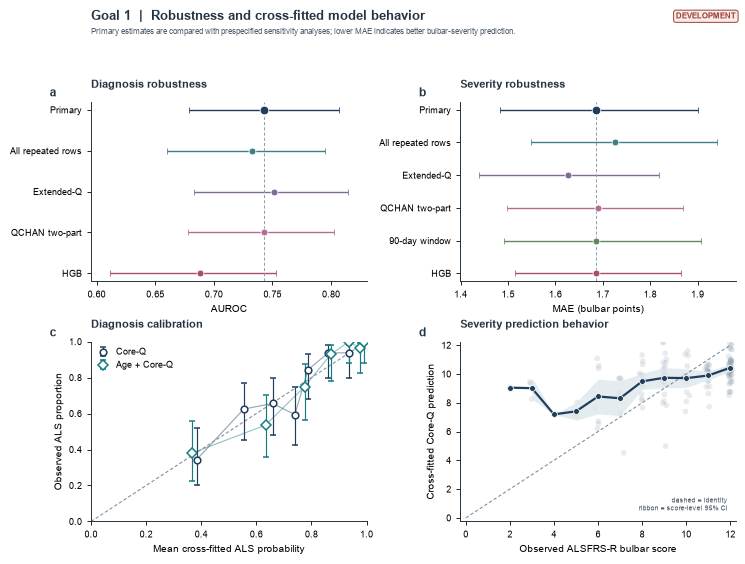

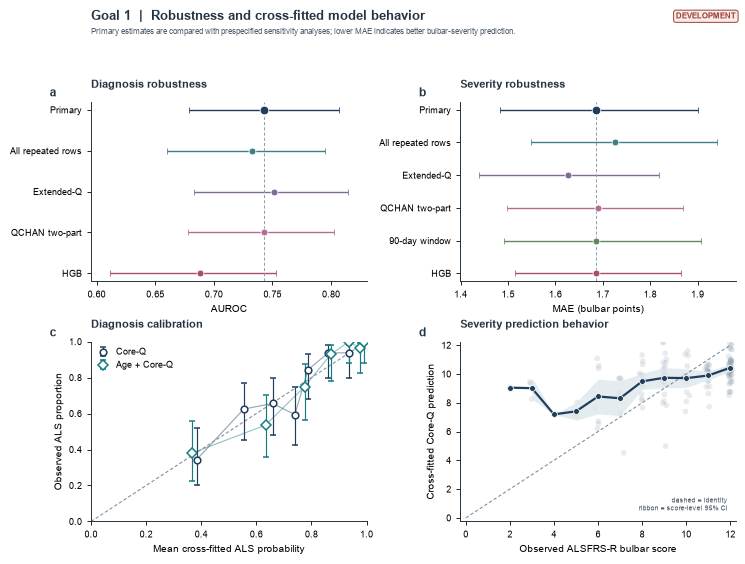

In [21]:
# ============================================================
# SUPPLEMENTARY GOAL 1 — LAYOUT-SAFE VERSION
# ============================================================

fig = plt.figure(
    figsize=(DOUBLE, 143 * MM),
    facecolor="white",
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.18, 1.0, 1.0],
    left=0.09,
    right=0.985,
    bottom=0.075,
    top=0.985,
    wspace=0.34,
    hspace=0.46,
)


# ============================================================
# HEADER
# ============================================================

header = fig.add_subplot(
    gs[0, :]
)
header.axis("off")

header.text(
    0.00,
    0.78,
    "Goal 1  |  Robustness and cross-fitted model behavior",
    ha="left",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=PAL["ink"],
)

header.text(
    0.00,
    0.30,
    (
        "Primary estimates are compared with prespecified sensitivity analyses; "
        "lower MAE indicates better bulbar-severity prediction."
    ),
    ha="left",
    va="center",
    fontsize=5.8,
    color=PAL["ink_soft"],
)

if RUN_LABEL == "FINAL":
    badge_text = "FINAL"
    badge_face = "#EAF2EE"
    badge_edge = PAL["final"]
    badge_color = PAL["final"]
else:
    badge_text = RUN_LABEL
    badge_face = "#F7ECEA"
    badge_edge = PAL["development"]
    badge_color = PAL["development"]

header.text(
    1.00,
    0.78,
    badge_text,
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color=badge_color,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor=badge_face,
        edgecolor=badge_edge,
        linewidth=0.7,
    ),
)


# ============================================================
# AXES
# ============================================================

ax_a = fig.add_subplot(
    gs[1, 0]
)
ax_b = fig.add_subplot(
    gs[1, 1]
)
ax_c = fig.add_subplot(
    gs[2, 0]
)
ax_d = fig.add_subplot(
    gs[2, 1]
)


SENS_PAL = {
    "Primary": "#203D5B",
    "All repeated rows": "#3F7E83",
    "Extended-Q": "#806A98",
    "QCHAN two-part": "#B56C92",
    "90-day window": "#64865F",
    "HGB": "#A64E6A",
}


# ============================================================
# a. DIAGNOSIS ROBUSTNESS
# ============================================================

dx_map = [
    (
        "Primary index Core-Q",
        "Primary",
    ),
    (
        "All recordings, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in dx_map:

    hit = g1_sens.loc[
        g1_sens["task"].eq(
            "diagnosis"
        )
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

dx_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in dx_s.iterrows():

    color = SENS_PAL[
        row["plot_label"]
    ]

    estimate = float(
        row["estimate"]
    )

    lo = max(
        0,
        estimate - float(
            row["ci_low"]
        ),
    )

    hi = max(
        0,
        float(row["ci_high"])
        - estimate,
    )

    ax_a.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lo],
            [hi],
        ]),
        fmt="o",
        markersize=(
            6.2
            if row["plot_label"]
            == "Primary"
            else 4.9
        ),
        linewidth=1.0,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
    )

primary_dx = float(
    dx_s.loc[
        dx_s["plot_label"].eq(
            "Primary"
        ),
        "estimate",
    ].iloc[0]
)

ax_a.axvline(
    primary_dx,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_a.set_yticks(
    np.arange(len(dx_s))
)

ax_a.set_yticklabels(
    dx_s["plot_label"]
)

ax_a.invert_yaxis()

# automatic x padding
xmin = float(dx_s["ci_low"].min())
xmax = float(dx_s["ci_high"].max())
pad = (xmax - xmin) * 0.08

ax_a.set_xlim(
    xmin - pad,
    xmax + pad,
)

ax_a.set_xlabel(
    "AUROC"
)

left_panel_title(
    ax_a,
    "Diagnosis robustness",
)

clean_axis(ax_a)
safe_panel_label(ax_a, "a")


# ============================================================
# b. SEVERITY ROBUSTNESS
# ============================================================

sev_map = [
    (
        "Primary ≤60 d Core-Q",
        "Primary",
    ),
    (
        "All ≤60 d pairs, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "≤90 d index Core-Q",
        "90-day window",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in sev_map:

    hit = g1_sens.loc[
        g1_sens["task"].eq(
            "severity"
        )
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

sev_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in sev_s.iterrows():

    color = SENS_PAL[
        row["plot_label"]
    ]

    estimate = float(
        row["estimate"]
    )

    lo = max(
        0,
        estimate - float(
            row["ci_low"]
        ),
    )

    hi = max(
        0,
        float(row["ci_high"])
        - estimate,
    )

    ax_b.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lo],
            [hi],
        ]),
        fmt="o",
        markersize=(
            6.2
            if row["plot_label"]
            == "Primary"
            else 4.9
        ),
        linewidth=1.0,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
    )

primary_sev = float(
    sev_s.loc[
        sev_s["plot_label"].eq(
            "Primary"
        ),
        "estimate",
    ].iloc[0]
)

ax_b.axvline(
    primary_sev,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_b.set_yticks(
    np.arange(len(sev_s))
)

ax_b.set_yticklabels(
    sev_s["plot_label"]
)

ax_b.invert_yaxis()

xmin = float(
    sev_s["ci_low"].min()
)
xmax = float(
    sev_s["ci_high"].max()
)

pad = (
    xmax - xmin
) * 0.08

ax_b.set_xlim(
    xmin - pad,
    xmax + pad,
)

ax_b.set_xlabel(
    "MAE (bulbar points)"
)

left_panel_title(
    ax_b,
    "Severity robustness",
)

clean_axis(ax_b)
safe_panel_label(ax_b, "b")


# ============================================================
# c. DIAGNOSIS CALIBRATION
# ============================================================

def wilson(
    successes,
    n,
    z=1.96,
):
    if n <= 0:
        return np.nan, np.nan

    p = successes / n

    denominator = (
        1
        + z**2 / n
    )

    center = (
        p
        + z**2 / (2*n)
    ) / denominator

    half = (
        z
        * np.sqrt(
            p * (1-p)/n
            + z**2/(4*n**2)
        )
        / denominator
    )

    return (
        max(
            0,
            center-half,
        ),
        min(
            1,
            center+half,
        ),
    )


def calibration_bins(
    frame,
    q=7,
):

    d = frame[
        [
            "true_outcome",
            "mean_oof_prediction",
        ]
    ].dropna().copy()

    d["bin"] = pd.qcut(
        d["mean_oof_prediction"],
        q=q,
        duplicates="drop",
    )

    output = []

    for _, g in d.groupby(
        "bin",
        observed=True,
    ):

        n = len(g)

        observed = float(
            g["true_outcome"].mean()
        )

        predicted = float(
            g[
                "mean_oof_prediction"
            ].mean()
        )

        low, high = wilson(
            int(
                g[
                    "true_outcome"
                ].sum()
            ),
            n,
        )

        output.append({
            "predicted": predicted,
            "observed": observed,
            "low": low,
            "high": high,
            "n": n,
        })

    return pd.DataFrame(
        output
    )


for (
    model,
    color,
    marker,
) in [
    (
        "Core-Q",
        PAL["Core-Q"],
        "o",
    ),
    (
        "Age + Core-Q",
        PAL["Age + Core-Q"],
        "D",
    ),
]:

    source = g1_dx_oof.loc[
        g1_dx_oof["model"].eq(
            model
        )
    ].copy()

    cal = calibration_bins(
        source,
        q=7,
    )

    yerr = np.vstack([
        cal["observed"]
        - cal["low"],
        cal["high"]
        - cal["observed"],
    ])

    ax_c.plot(
        cal["predicted"],
        cal["observed"],
        color=color,
        linewidth=0.85,
        alpha=0.45,
        zorder=1,
    )

    ax_c.errorbar(
        cal["predicted"],
        cal["observed"],
        yerr=yerr,
        fmt=marker,
        markersize=4.8,
        capsize=2,
        linewidth=0.85,
        color=color,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.1,
        label=model,
        zorder=3,
    )

ax_c.plot(
    [0, 1],
    [0, 1],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_c.set_xlim(
    0,
    1,
)

ax_c.set_ylim(
    0,
    1,
)

ax_c.set_xlabel(
    "Mean cross-fitted ALS probability"
)

ax_c.set_ylabel(
    "Observed ALS proportion"
)

left_panel_title(
    ax_c,
    "Diagnosis calibration",
)

ax_c.legend(
    frameon=False,
    loc="upper left",
    handlelength=1.4,
    borderaxespad=0.3,
)

clean_axis(ax_c)
safe_panel_label(ax_c, "c")


# ============================================================
# d. SEVERITY PREDICTION BEHAVIOR
# ============================================================

core = g1_sev_oof.loc[
    g1_sev_oof["model"].eq(
        "Core-Q"
    )
].copy()

rng = np.random.default_rng(
    20260827
)

x_jitter = (
    core[
        "true_outcome"
    ].to_numpy(float)
    + rng.normal(
        0,
        0.055,
        len(core),
    )
)

ax_d.scatter(
    x_jitter,
    core[
        "mean_oof_prediction"
    ],
    s=17,
    alpha=0.20,
    color="#8FA1AF",
    edgecolors="none",
    zorder=1,
)

summary = (
    core.groupby(
        "true_outcome",
        as_index=False,
    )
    .agg(
        prediction=(
            "mean_oof_prediction",
            "mean",
        ),
        sd=(
            "mean_oof_prediction",
            "std",
        ),
        n=(
            "participant_id",
            "size",
        ),
    )
)

summary["se"] = (
    summary["sd"]
    / np.sqrt(
        summary["n"]
    )
)

lower = (
    summary["prediction"]
    - 1.96 * summary["se"]
)

upper = (
    summary["prediction"]
    + 1.96 * summary["se"]
)

ax_d.fill_between(
    summary[
        "true_outcome"
    ],
    lower,
    upper,
    color="#DCE6EC",
    alpha=0.75,
    linewidth=0,
    zorder=2,
)

ax_d.plot(
    summary[
        "true_outcome"
    ],
    summary[
        "prediction"
    ],
    color=PAL["Core-Q"],
    linewidth=1.6,
    marker="o",
    markersize=4.2,
    markerfacecolor=PAL[
        "Core-Q"
    ],
    markeredgecolor="white",
    markeredgewidth=0.55,
    zorder=3,
)

ax_d.plot(
    [0, 12],
    [0, 12],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_d.set_xlim(
    -0.25,
    12.25,
)

ax_d.set_ylim(
    -0.25,
    12.25,
)

ax_d.set_xlabel(
    "Observed ALSFRS-R bulbar score"
)

ax_d.set_ylabel(
    "Cross-fitted Core-Q prediction"
)

left_panel_title(
    ax_d,
    "Severity prediction behavior",
)

# Put explanation in empty lower-right space,
# but with a white background so it remains legible.
ax_d.text(
    0.97,
    0.05,
    (
        "dashed = identity\n"
        "ribbon = score-level 95% CI"
    ),
    transform=ax_d.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.2,
    color=PAL["ink_soft"],
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.88,
        pad=1.5,
    ),
)

clean_axis(ax_d)
safe_panel_label(ax_d, "d")


# ============================================================
# SAVE
# ============================================================

save_pub(
    fig,
    (
        "FigureS_Goal1_robustness_v3_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_sensitivity_summary.csv",
        "goal1_dx_oof.csv",
        "goal1_bulbar_oof.csv",
    ],
)# ============================================================
# SUPPLEMENTARY GOAL 1 — LAYOUT-SAFE VERSION
# ============================================================

fig = plt.figure(
    figsize=(DOUBLE, 143 * MM),
    facecolor="white",
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.18, 1.0, 1.0],
    left=0.09,
    right=0.985,
    bottom=0.075,
    top=0.985,
    wspace=0.34,
    hspace=0.46,
)


# ============================================================
# HEADER
# ============================================================

header = fig.add_subplot(
    gs[0, :]
)
header.axis("off")

header.text(
    0.00,
    0.78,
    "Goal 1  |  Robustness and cross-fitted model behavior",
    ha="left",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=PAL["ink"],
)

header.text(
    0.00,
    0.30,
    (
        "Primary estimates are compared with prespecified sensitivity analyses; "
        "lower MAE indicates better bulbar-severity prediction."
    ),
    ha="left",
    va="center",
    fontsize=5.8,
    color=PAL["ink_soft"],
)

if RUN_LABEL == "FINAL":
    badge_text = "FINAL"
    badge_face = "#EAF2EE"
    badge_edge = PAL["final"]
    badge_color = PAL["final"]
else:
    badge_text = RUN_LABEL
    badge_face = "#F7ECEA"
    badge_edge = PAL["development"]
    badge_color = PAL["development"]

header.text(
    1.00,
    0.78,
    badge_text,
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color=badge_color,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor=badge_face,
        edgecolor=badge_edge,
        linewidth=0.7,
    ),
)


# ============================================================
# AXES
# ============================================================

ax_a = fig.add_subplot(
    gs[1, 0]
)
ax_b = fig.add_subplot(
    gs[1, 1]
)
ax_c = fig.add_subplot(
    gs[2, 0]
)
ax_d = fig.add_subplot(
    gs[2, 1]
)


SENS_PAL = {
    "Primary": "#203D5B",
    "All repeated rows": "#3F7E83",
    "Extended-Q": "#806A98",
    "QCHAN two-part": "#B56C92",
    "90-day window": "#64865F",
    "HGB": "#A64E6A",
}


# ============================================================
# a. DIAGNOSIS ROBUSTNESS
# ============================================================

dx_map = [
    (
        "Primary index Core-Q",
        "Primary",
    ),
    (
        "All recordings, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in dx_map:

    hit = g1_sens.loc[
        g1_sens["task"].eq(
            "diagnosis"
        )
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

dx_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in dx_s.iterrows():

    color = SENS_PAL[
        row["plot_label"]
    ]

    estimate = float(
        row["estimate"]
    )

    lo = max(
        0,
        estimate - float(
            row["ci_low"]
        ),
    )

    hi = max(
        0,
        float(row["ci_high"])
        - estimate,
    )

    ax_a.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lo],
            [hi],
        ]),
        fmt="o",
        markersize=(
            6.2
            if row["plot_label"]
            == "Primary"
            else 4.9
        ),
        linewidth=1.0,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
    )

primary_dx = float(
    dx_s.loc[
        dx_s["plot_label"].eq(
            "Primary"
        ),
        "estimate",
    ].iloc[0]
)

ax_a.axvline(
    primary_dx,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_a.set_yticks(
    np.arange(len(dx_s))
)

ax_a.set_yticklabels(
    dx_s["plot_label"]
)

ax_a.invert_yaxis()

# automatic x padding
xmin = float(dx_s["ci_low"].min())
xmax = float(dx_s["ci_high"].max())
pad = (xmax - xmin) * 0.08

ax_a.set_xlim(
    xmin - pad,
    xmax + pad,
)

ax_a.set_xlabel(
    "AUROC"
)

left_panel_title(
    ax_a,
    "Diagnosis robustness",
)

clean_axis(ax_a)
safe_panel_label(ax_a, "a")


# ============================================================
# b. SEVERITY ROBUSTNESS
# ============================================================

sev_map = [
    (
        "Primary ≤60 d Core-Q",
        "Primary",
    ),
    (
        "All ≤60 d pairs, participant-weighted",
        "All repeated rows",
    ),
    (
        "Extended-Q",
        "Extended-Q",
    ),
    (
        "QCHAN two-part Core-Q",
        "QCHAN two-part",
    ),
    (
        "≤90 d index Core-Q",
        "90-day window",
    ),
    (
        "Core-Q HGB",
        "HGB",
    ),
]

rows = []

for source_name, label in sev_map:

    hit = g1_sens.loc[
        g1_sens["task"].eq(
            "severity"
        )
        & g1_sens[
            "sensitivity"
        ].eq(source_name)
    ]

    if len(hit):
        r = hit.iloc[0].copy()
        r["plot_label"] = label
        rows.append(r)

sev_s = (
    pd.DataFrame(rows)
    .reset_index(drop=True)
)

for y, row in sev_s.iterrows():

    color = SENS_PAL[
        row["plot_label"]
    ]

    estimate = float(
        row["estimate"]
    )

    lo = max(
        0,
        estimate - float(
            row["ci_low"]
        ),
    )

    hi = max(
        0,
        float(row["ci_high"])
        - estimate,
    )

    ax_b.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lo],
            [hi],
        ]),
        fmt="o",
        markersize=(
            6.2
            if row["plot_label"]
            == "Primary"
            else 4.9
        ),
        linewidth=1.0,
        capsize=2,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
    )

primary_sev = float(
    sev_s.loc[
        sev_s["plot_label"].eq(
            "Primary"
        ),
        "estimate",
    ].iloc[0]
)

ax_b.axvline(
    primary_sev,
    linestyle=(0, (3, 2)),
    linewidth=0.75,
    color="#8FA0AF",
)

ax_b.set_yticks(
    np.arange(len(sev_s))
)

ax_b.set_yticklabels(
    sev_s["plot_label"]
)

ax_b.invert_yaxis()

xmin = float(
    sev_s["ci_low"].min()
)
xmax = float(
    sev_s["ci_high"].max()
)

pad = (
    xmax - xmin
) * 0.08

ax_b.set_xlim(
    xmin - pad,
    xmax + pad,
)

ax_b.set_xlabel(
    "MAE (bulbar points)"
)

left_panel_title(
    ax_b,
    "Severity robustness",
)

clean_axis(ax_b)
safe_panel_label(ax_b, "b")


# ============================================================
# c. DIAGNOSIS CALIBRATION
# ============================================================

def wilson(
    successes,
    n,
    z=1.96,
):
    if n <= 0:
        return np.nan, np.nan

    p = successes / n

    denominator = (
        1
        + z**2 / n
    )

    center = (
        p
        + z**2 / (2*n)
    ) / denominator

    half = (
        z
        * np.sqrt(
            p * (1-p)/n
            + z**2/(4*n**2)
        )
        / denominator
    )

    return (
        max(
            0,
            center-half,
        ),
        min(
            1,
            center+half,
        ),
    )


def calibration_bins(
    frame,
    q=7,
):

    d = frame[
        [
            "true_outcome",
            "mean_oof_prediction",
        ]
    ].dropna().copy()

    d["bin"] = pd.qcut(
        d["mean_oof_prediction"],
        q=q,
        duplicates="drop",
    )

    output = []

    for _, g in d.groupby(
        "bin",
        observed=True,
    ):

        n = len(g)

        observed = float(
            g["true_outcome"].mean()
        )

        predicted = float(
            g[
                "mean_oof_prediction"
            ].mean()
        )

        low, high = wilson(
            int(
                g[
                    "true_outcome"
                ].sum()
            ),
            n,
        )

        output.append({
            "predicted": predicted,
            "observed": observed,
            "low": low,
            "high": high,
            "n": n,
        })

    return pd.DataFrame(
        output
    )


for (
    model,
    color,
    marker,
) in [
    (
        "Core-Q",
        PAL["Core-Q"],
        "o",
    ),
    (
        "Age + Core-Q",
        PAL["Age + Core-Q"],
        "D",
    ),
]:

    source = g1_dx_oof.loc[
        g1_dx_oof["model"].eq(
            model
        )
    ].copy()

    cal = calibration_bins(
        source,
        q=7,
    )

    yerr = np.vstack([
        cal["observed"]
        - cal["low"],
        cal["high"]
        - cal["observed"],
    ])

    ax_c.plot(
        cal["predicted"],
        cal["observed"],
        color=color,
        linewidth=0.85,
        alpha=0.45,
        zorder=1,
    )

    ax_c.errorbar(
        cal["predicted"],
        cal["observed"],
        yerr=yerr,
        fmt=marker,
        markersize=4.8,
        capsize=2,
        linewidth=0.85,
        color=color,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.1,
        label=model,
        zorder=3,
    )

ax_c.plot(
    [0, 1],
    [0, 1],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_c.set_xlim(
    0,
    1,
)

ax_c.set_ylim(
    0,
    1,
)

ax_c.set_xlabel(
    "Mean cross-fitted ALS probability"
)

ax_c.set_ylabel(
    "Observed ALS proportion"
)

left_panel_title(
    ax_c,
    "Diagnosis calibration",
)

ax_c.legend(
    frameon=False,
    loc="upper left",
    handlelength=1.4,
    borderaxespad=0.3,
)

clean_axis(ax_c)
safe_panel_label(ax_c, "c")


# ============================================================
# d. SEVERITY PREDICTION BEHAVIOR
# ============================================================

core = g1_sev_oof.loc[
    g1_sev_oof["model"].eq(
        "Core-Q"
    )
].copy()

rng = np.random.default_rng(
    20260827
)

x_jitter = (
    core[
        "true_outcome"
    ].to_numpy(float)
    + rng.normal(
        0,
        0.055,
        len(core),
    )
)

ax_d.scatter(
    x_jitter,
    core[
        "mean_oof_prediction"
    ],
    s=17,
    alpha=0.20,
    color="#8FA1AF",
    edgecolors="none",
    zorder=1,
)

summary = (
    core.groupby(
        "true_outcome",
        as_index=False,
    )
    .agg(
        prediction=(
            "mean_oof_prediction",
            "mean",
        ),
        sd=(
            "mean_oof_prediction",
            "std",
        ),
        n=(
            "participant_id",
            "size",
        ),
    )
)

summary["se"] = (
    summary["sd"]
    / np.sqrt(
        summary["n"]
    )
)

lower = (
    summary["prediction"]
    - 1.96 * summary["se"]
)

upper = (
    summary["prediction"]
    + 1.96 * summary["se"]
)

ax_d.fill_between(
    summary[
        "true_outcome"
    ],
    lower,
    upper,
    color="#DCE6EC",
    alpha=0.75,
    linewidth=0,
    zorder=2,
)

ax_d.plot(
    summary[
        "true_outcome"
    ],
    summary[
        "prediction"
    ],
    color=PAL["Core-Q"],
    linewidth=1.6,
    marker="o",
    markersize=4.2,
    markerfacecolor=PAL[
        "Core-Q"
    ],
    markeredgecolor="white",
    markeredgewidth=0.55,
    zorder=3,
)

ax_d.plot(
    [0, 12],
    [0, 12],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    color=PAL["reference"],
)

ax_d.set_xlim(
    -0.25,
    12.25,
)

ax_d.set_ylim(
    -0.25,
    12.25,
)

ax_d.set_xlabel(
    "Observed ALSFRS-R bulbar score"
)

ax_d.set_ylabel(
    "Cross-fitted Core-Q prediction"
)

left_panel_title(
    ax_d,
    "Severity prediction behavior",
)

# Put explanation in empty lower-right space,
# but with a white background so it remains legible.
ax_d.text(
    0.97,
    0.05,
    (
        "dashed = identity\n"
        "ribbon = score-level 95% CI"
    ),
    transform=ax_d.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.2,
    color=PAL["ink_soft"],
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.88,
        pad=1.5,
    ),
)

clean_axis(ax_d)
safe_panel_label(ax_d, "d")


# ============================================================
# SAVE
# ============================================================

save_pub(
    fig,
    (
        "FigureS_Goal1_robustness_v3_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_sensitivity_summary.csv",
        "goal1_dx_oof.csv",
        "goal1_bulbar_oof.csv",
    ],
)

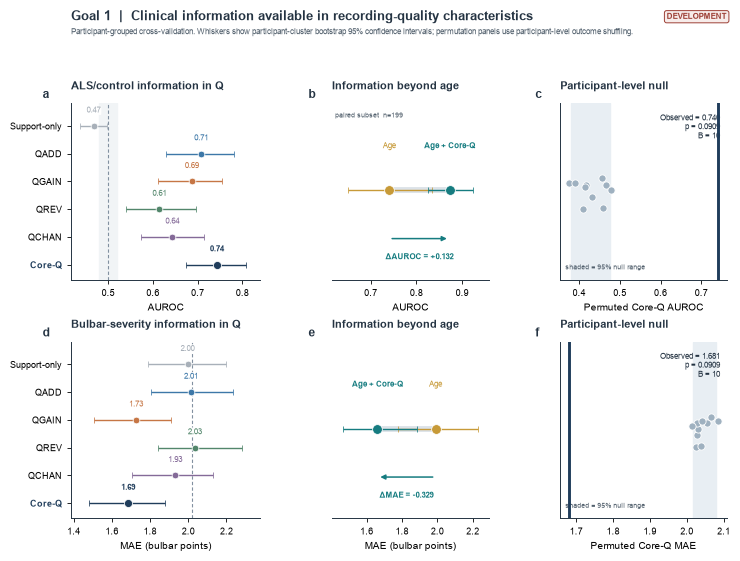

In [22]:
# ============================================================
# GOAL 1 — MAIN PUBLICATION FIGURE
# LAYOUT-SAFE + NON-OVERLAPPING NUMERIC LABELS
#
# a  Diagnosis information by Q family
# b  Incremental diagnosis information beyond age
# c  Diagnosis participant-level null
# d  Severity information by Q family
# e  Incremental severity information beyond age
# f  Severity participant-level null
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# LOCAL PLOTTING HELPERS
# ------------------------------------------------------------

def _clean_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")

    ax.spines["left"].set_color(PAL["ink"])
    ax.spines["bottom"].set_color(PAL["ink"])


def _panel_letter(ax, letter):
    ax.text(
        -0.15,
        1.015,
        letter,
        transform=ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        color=PAL["ink"],
        ha="left",
        va="bottom",
        clip_on=False,
    )


def _panel_title(ax, text):
    ax.set_title(
        text,
        loc="left",
        pad=10,
        fontsize=7.6,
        fontweight="bold",
        color=PAL["ink"],
    )


def _forest_point(ax, row, y, color, size=5):
    """Point estimate + horizontal 95% CI."""
    estimate = float(row["estimate"])
    ci_low = float(row["ci_low"])
    ci_high = float(row["ci_high"])

    lower = max(
        0.0,
        estimate - ci_low,
    )

    upper = max(
        0.0,
        ci_high - estimate,
    )

    ax.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lower],
            [upper],
        ]),
        fmt="o",
        markersize=size,
        linewidth=1.0,
        elinewidth=1.0,
        capsize=2.2,
        capthick=0.8,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
        zorder=4,
    )


def _forest_number(
    ax,
    estimate,
    y,
    color,
    bold=False,
    decimals=2,
):
    """
    Numerical estimate placed ABOVE the marker/CI.

    White background prevents the CI, cap, or point from visually
    passing through the text while remaining essentially invisible
    on a white publication background.
    """
    ax.annotate(
        f"{estimate:.{decimals}f}",
        xy=(estimate, y),
        xytext=(0, 8.5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=5.5,
        fontweight=(
            "bold"
            if bold
            else "normal"
        ),
        color=color,
        zorder=10,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.10",
            facecolor="white",
            edgecolor="none",
            alpha=0.97,
        ),
    )


# ------------------------------------------------------------
# FIGURE GEOMETRY
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(
        DOUBLE,
        142 * MM,
    ),
    facecolor="white",
)

# Dedicated header row avoids any collision with panels.
gs = fig.add_gridspec(
    nrows=3,
    ncols=3,
    height_ratios=[
        0.18,
        1.0,
        1.0,
    ],
    width_ratios=[
        1.16,
        0.96,
        1.02,
    ],
    left=0.075,
    right=0.985,
    bottom=0.075,
    top=0.985,
    wspace=0.42,
    hspace=0.48,
)


# ============================================================
# HEADER
# ============================================================

header = fig.add_subplot(
    gs[0, :]
)

header.axis("off")

header.text(
    0.00,
    0.78,
    (
        "Goal 1  |  Clinical information available in "
        "recording-quality characteristics"
    ),
    ha="left",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=PAL["ink"],
)

header.text(
    0.00,
    0.30,
    (
        "Participant-grouped cross-validation. "
        "Whiskers show participant-cluster bootstrap 95% confidence intervals; "
        "permutation panels use participant-level outcome shuffling."
    ),
    ha="left",
    va="center",
    fontsize=5.8,
    color=PAL["ink_soft"],
)


if RUN_LABEL == "FINAL":

    badge_text = "FINAL"
    badge_face = "#EAF2EE"
    badge_edge = PAL["final"]
    badge_color = PAL["final"]

else:

    badge_text = RUN_LABEL
    badge_face = "#F7ECEA"
    badge_edge = PAL["development"]
    badge_color = PAL["development"]


header.text(
    1.00,
    0.78,
    badge_text,
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color=badge_color,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor=badge_face,
        edgecolor=badge_edge,
        linewidth=0.7,
    ),
)


# ------------------------------------------------------------
# DATA AXES
# ------------------------------------------------------------

ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[1, 2])

ax_d = fig.add_subplot(gs[2, 0])
ax_e = fig.add_subplot(gs[2, 1])
ax_f = fig.add_subplot(gs[2, 2])


family_order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]


# ============================================================
# a. DIAGNOSIS — INFORMATION BY Q FAMILY
# ============================================================

ax = ax_a

dx_family = (
    g1_metrics.loc[
        g1_metrics["task"].eq("diagnosis")
        & g1_metrics["metric"].eq("AUROC")
        & g1_metrics["model"].isin(
            family_order
        )
    ]
    .set_index("model")
    .reindex(family_order)
    .reset_index()
)


# Subtle chance region.
ax.axvspan(
    0.48,
    0.52,
    color=PAL["very_light"],
    zorder=0,
)

ax.axvline(
    0.50,
    color=PAL["reference"],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
    zorder=1,
)


for i, row in dx_family.iterrows():

    model = row["model"]

    color = MODEL_COLORS[
        model
    ]

    estimate = float(
        row["estimate"]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=i,
        color=color,
        size=(
            5.8
            if model == "Core-Q"
            else 4.8
        ),
    )

    # IMPORTANT:
    # Number is centered ABOVE the point,
    # not drawn on top of the CI line.
    _forest_number(
        ax=ax,
        estimate=estimate,
        y=i,
        color=color,
        bold=(
            model == "Core-Q"
        ),
        decimals=2,
    )


ax.set_yticks(
    np.arange(
        len(family_order)
    )
)

ax.set_yticklabels(
    family_order
)


for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):

    if model == "Core-Q":

        tick.set_fontweight(
            "bold"
        )

        tick.set_color(
            PAL["Core-Q"]
        )


# Manual inverted limits give extra vertical space ABOVE row 0
# for the numerical labels.
ax.set_ylim(
    len(family_order) - 0.45,
    -0.82,
)


# Enough horizontal space for CIs.
dx_xmin = min(
    0.42,
    float(
        dx_family[
            "ci_low"
        ].min()
    ) - 0.02,
)

dx_xmax = max(
    0.84,
    float(
        dx_family[
            "ci_high"
        ].max()
    ) + 0.02,
)

ax.set_xlim(
    dx_xmin,
    dx_xmax,
)

ax.set_xlabel(
    "AUROC"
)

_panel_title(
    ax,
    "ALS/control information in Q",
)

_clean_axis(ax)
_panel_letter(ax, "a")


# ============================================================
# b. DIAGNOSIS — INFORMATION BEYOND AGE
# ============================================================

ax = ax_b

age_dx = (
    g1_metrics.loc[
        g1_metrics["task"].eq(
            "diagnosis"
        )
        & g1_metrics["metric"].eq(
            "AUROC"
        )
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)


age_est = float(
    age_dx.loc[
        age_dx["model"].eq(
            "Age"
        ),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_dx.loc[
        age_dx["model"].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)


# Dumbbell connector.
ax.plot(
    [
        age_est,
        ageq_est,
    ],
    [0, 0],
    color=PAL["light"],
    linewidth=4.2,
    solid_capstyle="round",
    zorder=1,
)


for _, row in age_dx.iterrows():

    model = row["model"]

    _forest_point(
        ax=ax,
        row=row,
        y=0,
        color=MODEL_COLORS[
            model
        ],
        size=7,
    )


# Labels placed well above.
ax.annotate(
    "Age",
    xy=(
        age_est,
        0,
    ),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL["Age"],
)

ax.annotate(
    "Age + Core-Q",
    xy=(
        ageq_est,
        0,
    ),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


delta_dx = (
    ageq_est
    - age_est
)

arrow_y = -0.43


ax.annotate(
    "",
    xy=(
        ageq_est,
        arrow_y,
    ),
    xytext=(
        age_est,
        arrow_y,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL[
            "Age + Core-Q"
        ],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)

ax.text(
    (
        age_est
        + ageq_est
    ) / 2,
    arrow_y - 0.13,
    (
        f"ΔAUROC = "
        f"{delta_dx:+.3f}"
    ),
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


n_age = int(
    age_dx[
        "n_participants"
    ].iloc[0]
)

ax.text(
    0.02,
    0.95,
    f"paired subset  n={n_age}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=5.4,
    color=PAL["ink_soft"],
)


ax.set_ylim(
    -0.80,
    0.78,
)

ax.set_yticks([])


xmin = float(
    age_dx[
        "ci_low"
    ].min()
) - 0.035

xmax = float(
    age_dx[
        "ci_high"
    ].max()
) + 0.035


ax.set_xlim(
    xmin,
    xmax,
)

ax.set_xlabel(
    "AUROC"
)

_panel_title(
    ax,
    "Information beyond age",
)

_clean_axis(ax)

ax.spines[
    "left"
].set_visible(False)

_panel_letter(ax, "b")


# ============================================================
# c. DIAGNOSIS — PARTICIPANT-LEVEL PERMUTATION NULL
# ============================================================

ax = ax_c

dx_null = g1_perm.loc[
    g1_perm["task"].eq(
        "diagnosis"
    )
].copy()


dx_null_values = (
    pd.to_numeric(
        dx_null[
            "null_metric"
        ],
        errors="coerce",
    )
    .dropna()
    .to_numpy()
)


dx_observed = float(
    dx_null[
        "observed_metric"
    ].iloc[0]
)

dx_p = float(
    dx_null[
        "empirical_p"
    ].iloc[0]
)


dx_q025, dx_q975 = (
    np.quantile(
        dx_null_values,
        [0.025, 0.975],
    )
)


ax.axvspan(
    dx_q025,
    dx_q975,
    color="#E8EEF3",
    zorder=0,
)


if len(
    dx_null_values
) >= 40:

    bins = min(
        30,
        max(
            12,
            int(
                np.sqrt(
                    len(
                        dx_null_values
                    )
                )
            ),
        ),
    )

    ax.hist(
        dx_null_values,
        bins=bins,
        density=True,
        color="#AFC0CE",
        edgecolor="white",
        linewidth=0.45,
    )

    ax.set_ylabel(
        "Null density"
    )

else:

    rng = (
        np.random.default_rng(
            20260827
        )
    )

    jitter = rng.uniform(
        -0.065,
        0.065,
        len(
            dx_null_values
        ),
    )

    ax.scatter(
        dx_null_values,
        (
            np.ones(
                len(
                    dx_null_values
                )
            )
            + jitter
        ),
        s=27,
        color="#9FB1C0",
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    ax.set_ylim(
        0.72,
        1.28,
    )

    ax.set_yticks([])


ax.axvline(
    dx_observed,
    color=PAL[
        "Core-Q"
    ],
    linewidth=2.1,
    zorder=4,
)


ax.text(
    0.96,
    0.94,
    (
        f"Observed = "
        f"{dx_observed:.3f}\n"
        f"p = {dx_p:.4f}\n"
        f"B = "
        f"{len(dx_null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.6,
    color=PAL["ink"],
)


ax.text(
    0.03,
    0.06,
    (
        "shaded = "
        "95% null range"
    ),
    transform=ax.transAxes,
    fontsize=5.1,
    color=PAL["ink_soft"],
)


all_dx_x = np.r_[
    dx_null_values,
    dx_observed,
]

dx_pad = (
    max(all_dx_x)
    - min(all_dx_x)
) * 0.06


ax.set_xlim(
    min(all_dx_x)
    - dx_pad,
    max(all_dx_x)
    + dx_pad,
)

ax.set_xlabel(
    "Permuted Core-Q AUROC"
)

_panel_title(
    ax,
    "Participant-level null",
)

_clean_axis(ax)
_panel_letter(ax, "c")


# ============================================================
# d. SEVERITY — INFORMATION BY Q FAMILY
# ============================================================

ax = ax_d

sev_family = (
    g1_metrics.loc[
        g1_metrics["task"].eq(
            "severity"
        )
        & g1_metrics["metric"].eq(
            "MAE"
        )
        & g1_metrics["model"].isin(
            family_order
        )
    ]
    .set_index("model")
    .reindex(
        family_order
    )
    .reset_index()
)


baseline_row = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq("severity")
        & g1_metrics[
            "metric"
        ].eq("MAE")
        & g1_metrics[
            "model"
        ].eq(
            "Mean baseline"
        )
    ]
)


baseline = float(
    baseline_row[
        "estimate"
    ].iloc[0]
)


ax.axvline(
    baseline,
    color=PAL[
        "reference"
    ],
    linestyle=(0, (3, 2)),
    linewidth=0.8,
)


for i, row in (
    sev_family.iterrows()
):

    model = row[
        "model"
    ]

    color = (
        MODEL_COLORS[
            model
        ]
    )

    estimate = float(
        row["estimate"]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=i,
        color=color,
        size=(
            5.8
            if model
            == "Core-Q"
            else 4.8
        ),
    )

    # IMPORTANT:
    # value sits above the CI,
    # never horizontally on it.
    _forest_number(
        ax=ax,
        estimate=estimate,
        y=i,
        color=color,
        bold=(
            model
            == "Core-Q"
        ),
        decimals=2,
    )


ax.set_yticks(
    np.arange(
        len(
            family_order
        )
    )
)

ax.set_yticklabels(
    family_order
)


for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):

    if model == "Core-Q":

        tick.set_fontweight(
            "bold"
        )

        tick.set_color(
            PAL[
                "Core-Q"
            ]
        )


# Extra top-row breathing room for value labels.
ax.set_ylim(
    len(
        family_order
    ) - 0.45,
    -0.82,
)


sev_min = float(
    sev_family[
        "ci_low"
    ].min()
)

sev_max = float(
    max(
        sev_family[
            "ci_high"
        ].max(),
        baseline,
    )
)

sev_pad = (
    sev_max
    - sev_min
) * 0.12


ax.set_xlim(
    sev_min
    - sev_pad,
    sev_max
    + sev_pad,
)


ax.set_xlabel(
    "MAE (bulbar points)"
)

_panel_title(
    ax,
    "Bulbar-severity information in Q",
)

_clean_axis(ax)
_panel_letter(ax, "d")


# ============================================================
# e. SEVERITY — INFORMATION BEYOND AGE
# ============================================================

ax = ax_e

age_sev = (
    g1_metrics.loc[
        g1_metrics["task"].eq(
            "severity"
        )
        & g1_metrics["metric"].eq(
            "MAE"
        )
        & g1_metrics["model"].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index("model")
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)


age_est = float(
    age_sev.loc[
        age_sev[
            "model"
        ].eq("Age"),
        "estimate",
    ].iloc[0]
)

ageq_est = float(
    age_sev.loc[
        age_sev[
            "model"
        ].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)


ax.plot(
    [
        ageq_est,
        age_est,
    ],
    [0, 0],
    color=PAL["light"],
    linewidth=4.2,
    solid_capstyle="round",
    zorder=1,
)


for _, row in (
    age_sev.iterrows()
):

    model = row[
        "model"
    ]

    _forest_point(
        ax=ax,
        row=row,
        y=0,
        color=MODEL_COLORS[
            model
        ],
        size=7,
    )


ax.annotate(
    "Age + Core-Q",
    xy=(
        ageq_est,
        0,
    ),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)

ax.annotate(
    "Age",
    xy=(
        age_est,
        0,
    ),
    xytext=(0, 29),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL[
        "Age"
    ],
)


delta_sev = (
    ageq_est
    - age_est
)

arrow_y = -0.43


# Improvement in MAE points LEFT.
ax.annotate(
    "",
    xy=(
        ageq_est,
        arrow_y,
    ),
    xytext=(
        age_est,
        arrow_y,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL[
            "Age + Core-Q"
        ],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)


ax.text(
    (
        age_est
        + ageq_est
    ) / 2,
    arrow_y - 0.13,
    (
        f"ΔMAE = "
        f"{delta_sev:+.3f}"
    ),
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


ax.set_ylim(
    -0.80,
    0.78,
)

ax.set_yticks([])


xmin = float(
    age_sev[
        "ci_low"
    ].min()
) - 0.06

xmax = float(
    age_sev[
        "ci_high"
    ].max()
) + 0.06


ax.set_xlim(
    xmin,
    xmax,
)

ax.set_xlabel(
    "MAE (bulbar points)"
)

_panel_title(
    ax,
    "Information beyond age",
)

_clean_axis(ax)

ax.spines[
    "left"
].set_visible(False)

_panel_letter(ax, "e")


# ============================================================
# f. SEVERITY — PARTICIPANT-LEVEL PERMUTATION NULL
# ============================================================

ax = ax_f

sev_null = g1_perm.loc[
    g1_perm[
        "task"
    ].eq(
        "severity"
    )
].copy()


sev_null_values = (
    pd.to_numeric(
        sev_null[
            "null_metric"
        ],
        errors="coerce",
    )
    .dropna()
    .to_numpy()
)


sev_observed = float(
    sev_null[
        "observed_metric"
    ].iloc[0]
)

sev_p = float(
    sev_null[
        "empirical_p"
    ].iloc[0]
)


sev_q025, sev_q975 = (
    np.quantile(
        sev_null_values,
        [0.025, 0.975],
    )
)


ax.axvspan(
    sev_q025,
    sev_q975,
    color="#E8EEF3",
    zorder=0,
)


if len(
    sev_null_values
) >= 40:

    bins = min(
        30,
        max(
            12,
            int(
                np.sqrt(
                    len(
                        sev_null_values
                    )
                )
            ),
        ),
    )

    ax.hist(
        sev_null_values,
        bins=bins,
        density=True,
        color="#AFC0CE",
        edgecolor="white",
        linewidth=0.45,
    )

    ax.set_ylabel(
        "Null density"
    )

else:

    rng = (
        np.random.default_rng(
            20260827
        )
    )

    jitter = rng.uniform(
        -0.065,
        0.065,
        len(
            sev_null_values
        ),
    )

    ax.scatter(
        sev_null_values,
        (
            np.ones(
                len(
                    sev_null_values
                )
            )
            + jitter
        ),
        s=27,
        color="#9FB1C0",
        edgecolor="white",
        linewidth=0.6,
        zorder=3,
    )

    ax.set_ylim(
        0.72,
        1.28,
    )

    ax.set_yticks([])


ax.axvline(
    sev_observed,
    color=PAL[
        "Core-Q"
    ],
    linewidth=2.1,
    zorder=4,
)


ax.text(
    0.96,
    0.94,
    (
        f"Observed = "
        f"{sev_observed:.3f}\n"
        f"p = {sev_p:.4f}\n"
        f"B = "
        f"{len(sev_null_values):,}"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=5.6,
    color=PAL["ink"],
)


ax.text(
    0.03,
    0.06,
    (
        "shaded = "
        "95% null range"
    ),
    transform=ax.transAxes,
    fontsize=5.1,
    color=PAL["ink_soft"],
)


all_sev_x = np.r_[
    sev_null_values,
    sev_observed,
]

sev_null_pad = (
    max(all_sev_x)
    - min(all_sev_x)
) * 0.06


ax.set_xlim(
    min(all_sev_x)
    - sev_null_pad,
    max(all_sev_x)
    + sev_null_pad,
)

ax.set_xlabel(
    "Permuted Core-Q MAE"
)

_panel_title(
    ax,
    "Participant-level null",
)

_clean_axis(ax)
_panel_letter(ax, "f")


# ============================================================
# SAVE
# ============================================================

save_pub(
    fig,
    (
        "Figure2_Goal1_publication_v4_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_metrics.csv",
        "goal1_permutation.csv",
    ],
)

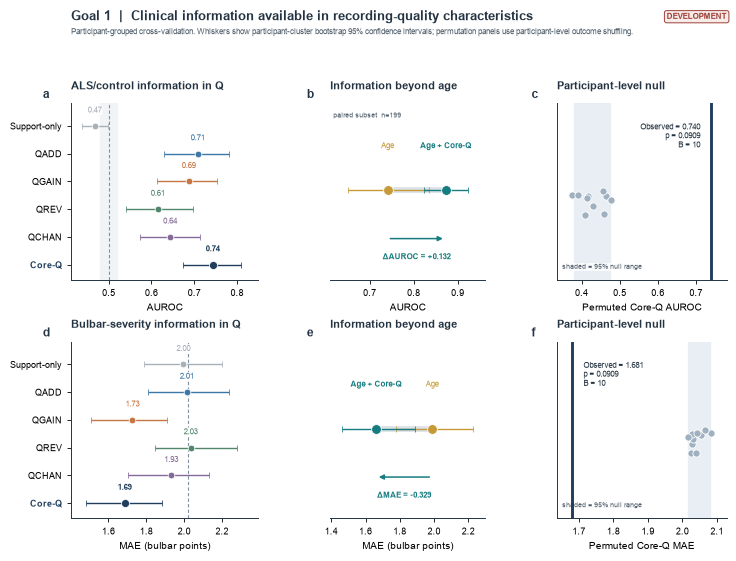

In [23]:
# ============================================================
# GOAL 1 — MAIN PUBLICATION FIGURE v5
# FINAL LAYOUT-SAFE VERSION
#
# Fixes:
#   • forest estimate labels never overlap CI lines
#   • permutation observed lines never hit panel boundary
#   • permutation statistics never overlap observed line
#   • safe padding on left AND right sides
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOCAL HELPERS
# ============================================================

def _clean_axis(ax):
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        direction="out"
    )

    ax.spines["left"].set_color(
        PAL["ink"]
    )
    ax.spines["bottom"].set_color(
        PAL["ink"]
    )


def _panel_letter(
    ax,
    letter,
):
    ax.text(
        -0.15,
        1.015,
        letter,
        transform=ax.transAxes,
        fontsize=8.8,
        fontweight="bold",
        color=PAL["ink"],
        ha="left",
        va="bottom",
        clip_on=False,
    )


def _panel_title(
    ax,
    text,
):
    ax.set_title(
        text,
        loc="left",
        pad=10,
        fontsize=7.6,
        fontweight="bold",
        color=PAL["ink"],
    )


def _forest_point(
    ax,
    row,
    y,
    color,
    size=5,
):
    estimate = float(
        row["estimate"]
    )

    ci_low = float(
        row["ci_low"]
    )

    ci_high = float(
        row["ci_high"]
    )

    lower = max(
        0.0,
        estimate - ci_low,
    )

    upper = max(
        0.0,
        ci_high - estimate,
    )

    ax.errorbar(
        estimate,
        y,
        xerr=np.array([
            [lower],
            [upper],
        ]),
        fmt="o",
        markersize=size,
        linewidth=1.0,
        elinewidth=1.0,
        capsize=2.2,
        capthick=0.8,
        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.55,
        zorder=4,
    )


def _forest_number(
    ax,
    estimate,
    y,
    color,
    bold=False,
    decimals=2,
):
    """
    Estimate label above point/CI with white knockout.
    """
    ax.annotate(
        f"{estimate:.{decimals}f}",
        xy=(
            estimate,
            y,
        ),
        xytext=(
            0,
            8.5,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=5.5,
        fontweight=(
            "bold"
            if bold
            else "normal"
        ),
        color=color,
        zorder=10,
        clip_on=False,
        bbox=dict(
            boxstyle="round,pad=0.10",
            facecolor="white",
            edgecolor="none",
            alpha=0.97,
        ),
    )


def _safe_range(
    values,
    observed=None,
    pad_fraction=0.10,
    min_pad=None,
):
    """
    Produce x-limits with genuine whitespace on BOTH sides.

    Useful for permutation panels where observed value can sit
    far outside the null distribution.
    """
    arr = np.asarray(
        values,
        dtype=float,
    )

    arr = arr[
        np.isfinite(arr)
    ]

    if observed is not None:
        arr = np.r_[
            arr,
            float(observed),
        ]

    low = float(
        np.min(arr)
    )
    high = float(
        np.max(arr)
    )

    span = high - low

    if span <= 0:
        span = max(
            abs(low),
            1.0,
        )

    pad = (
        span
        * pad_fraction
    )

    if min_pad is not None:
        pad = max(
            pad,
            min_pad,
        )

    return (
        low - pad,
        high + pad,
    )


def _draw_permutation_panel(
    ax,
    table,
    task,
    xlabel,
):
    """
    Publication-safe permutation display.

    DEVELOPMENT:
        strip plot because B is small.

    FINAL:
        histogram because B is large.

    Observed-value statistics are placed on the opposite side
    of the observed line, with a white box so nothing can cover them.
    """

    d = table.loc[
        table["task"].eq(task)
    ].copy()

    null_values = (
        pd.to_numeric(
            d["null_metric"],
            errors="coerce",
        )
        .dropna()
        .to_numpy(float)
    )

    observed = float(
        d[
            "observed_metric"
        ].iloc[0]
    )

    empirical_p = float(
        d[
            "empirical_p"
        ].iloc[0]
    )

    q025, q975 = (
        np.quantile(
            null_values,
            [
                0.025,
                0.975,
            ],
        )
    )

    # --------------------------------------------------------
    # Safe x-range first.
    # Gives explicit empty space around extreme observed value.
    # --------------------------------------------------------

    xmin, xmax = _safe_range(
        null_values,
        observed=observed,
        pad_fraction=0.11,
    )

    ax.set_xlim(
        xmin,
        xmax,
    )

    # Null 95% region.
    ax.axvspan(
        q025,
        q975,
        color="#E8EEF3",
        zorder=0,
    )

    # --------------------------------------------------------
    # Null distribution
    # --------------------------------------------------------

    if len(
        null_values
    ) >= 40:

        bins = min(
            30,
            max(
                12,
                int(
                    np.sqrt(
                        len(
                            null_values
                        )
                    )
                ),
            ),
        )

        ax.hist(
            null_values,
            bins=bins,
            density=True,
            color="#AFC0CE",
            edgecolor="white",
            linewidth=0.45,
            zorder=2,
        )

        ax.set_ylabel(
            "Null density"
        )

        y_min, y_max = (
            ax.get_ylim()
        )

        stat_y = (
            y_min
            + 0.93
            * (
                y_max
                - y_min
            )
        )

    else:

        rng = (
            np.random.default_rng(
                20260827
            )
        )

        jitter = rng.uniform(
            -0.065,
            0.065,
            len(
                null_values
            ),
        )

        ax.scatter(
            null_values,
            (
                np.ones(
                    len(
                        null_values
                    )
                )
                + jitter
            ),
            s=27,
            color="#9FB1C0",
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

        # More top room than before.
        ax.set_ylim(
            0.68,
            1.40,
        )

        ax.set_yticks([])

        stat_y = 1.32

    # --------------------------------------------------------
    # Observed line
    # --------------------------------------------------------

    ax.axvline(
        observed,
        color=PAL[
            "Core-Q"
        ],
        linewidth=2.1,
        zorder=4,
    )

    # --------------------------------------------------------
    # Statistics annotation
    #
    # Decide whether observed sits on LEFT or RIGHT side.
    # Text is always placed toward the CENTER of the panel,
    # not outside the observed line.
    # --------------------------------------------------------

    null_center = float(
        np.median(
            null_values
        )
    )

    observed_is_right = (
        observed
        >= null_center
    )

    if observed_is_right:

        # Text ends just LEFT of observed line.
        stat_x = observed

        ha = "right"

        x_offset = -8

    else:

        # Text begins just RIGHT of observed line.
        stat_x = observed

        ha = "left"

        x_offset = 8

    ax.annotate(
        (
            f"Observed = {observed:.3f}\n"
            f"p = {empirical_p:.4f}\n"
            f"B = {len(null_values):,}"
        ),
        xy=(
            stat_x,
            stat_y,
        ),
        xytext=(
            x_offset,
            0,
        ),
        textcoords="offset points",
        ha=ha,
        va="top",
        fontsize=5.6,
        color=PAL["ink"],
        zorder=10,
        clip_on=True,
        bbox=dict(
            boxstyle="round,pad=0.22",
            facecolor="white",
            edgecolor="none",
            alpha=0.96,
        ),
    )

    # Lower annotation always placed in open plot corner.
    ax.text(
        0.03,
        0.055,
        "shaded = 95% null range",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=5.0,
        color=PAL[
            "ink_soft"
        ],
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.80,
            pad=0.8,
        ),
    )

    ax.set_xlabel(
        xlabel
    )

    _clean_axis(ax)


# ============================================================
# FIGURE GEOMETRY
# ============================================================

fig = plt.figure(
    figsize=(
        DOUBLE,
        142 * MM,
    ),
    facecolor="white",
)


gs = fig.add_gridspec(
    nrows=3,
    ncols=3,
    height_ratios=[
        0.18,
        1.0,
        1.0,
    ],
    width_ratios=[
        1.16,
        0.96,
        1.05,
    ],
    left=0.075,
    right=0.985,
    bottom=0.075,
    top=0.985,
    wspace=0.42,
    hspace=0.48,
)


# ============================================================
# HEADER
# ============================================================

header = (
    fig.add_subplot(
        gs[
            0,
            :,
        ]
    )
)

header.axis(
    "off"
)


header.text(
    0.00,
    0.78,
    (
        "Goal 1  |  Clinical information available in "
        "recording-quality characteristics"
    ),
    ha="left",
    va="center",
    fontsize=9.4,
    fontweight="bold",
    color=PAL[
        "ink"
    ],
)


header.text(
    0.00,
    0.30,
    (
        "Participant-grouped cross-validation. "
        "Whiskers show participant-cluster bootstrap 95% confidence intervals; "
        "permutation panels use participant-level outcome shuffling."
    ),
    ha="left",
    va="center",
    fontsize=5.8,
    color=PAL[
        "ink_soft"
    ],
)


if RUN_LABEL == "FINAL":

    badge_text = (
        "FINAL"
    )

    badge_face = (
        "#EAF2EE"
    )

    badge_edge = (
        PAL["final"]
    )

    badge_color = (
        PAL["final"]
    )

else:

    badge_text = (
        RUN_LABEL
    )

    badge_face = (
        "#F7ECEA"
    )

    badge_edge = (
        PAL[
            "development"
        ]
    )

    badge_color = (
        PAL[
            "development"
        ]
    )


header.text(
    1.00,
    0.78,
    badge_text,
    ha="right",
    va="center",
    fontsize=5.8,
    fontweight="bold",
    color=badge_color,
    bbox=dict(
        boxstyle=(
            "round,pad=0.28"
        ),
        facecolor=(
            badge_face
        ),
        edgecolor=(
            badge_edge
        ),
        linewidth=0.7,
    ),
)


# ============================================================
# AXES
# ============================================================

ax_a = (
    fig.add_subplot(
        gs[1, 0]
    )
)

ax_b = (
    fig.add_subplot(
        gs[1, 1]
    )
)

ax_c = (
    fig.add_subplot(
        gs[1, 2]
    )
)

ax_d = (
    fig.add_subplot(
        gs[2, 0]
    )
)

ax_e = (
    fig.add_subplot(
        gs[2, 1]
    )
)

ax_f = (
    fig.add_subplot(
        gs[2, 2]
    )
)


family_order = [
    "Support-only",
    "QADD",
    "QGAIN",
    "QREV",
    "QCHAN",
    "Core-Q",
]


# ============================================================
# a. DIAGNOSIS — Q FAMILY
# ============================================================

ax = ax_a


dx_family = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq(
            "diagnosis"
        )
        & g1_metrics[
            "metric"
        ].eq(
            "AUROC"
        )
        & g1_metrics[
            "model"
        ].isin(
            family_order
        )
    ]
    .set_index(
        "model"
    )
    .reindex(
        family_order
    )
    .reset_index()
)


ax.axvspan(
    0.48,
    0.52,
    color=PAL[
        "very_light"
    ],
    zorder=0,
)


ax.axvline(
    0.50,
    color=PAL[
        "reference"
    ],
    linestyle=(
        0,
        (
            3,
            2,
        ),
    ),
    linewidth=0.8,
    zorder=1,
)


for i, row in (
    dx_family.iterrows()
):

    model = (
        row["model"]
    )

    color = (
        MODEL_COLORS[
            model
        ]
    )

    estimate = float(
        row[
            "estimate"
        ]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=i,
        color=color,
        size=(
            5.8
            if model
            == "Core-Q"
            else 4.8
        ),
    )

    _forest_number(
        ax=ax,
        estimate=estimate,
        y=i,
        color=color,
        bold=(
            model
            == "Core-Q"
        ),
        decimals=2,
    )


ax.set_yticks(
    np.arange(
        len(
            family_order
        )
    )
)


ax.set_yticklabels(
    family_order
)


for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):

    if model == (
        "Core-Q"
    ):

        tick.set_fontweight(
            "bold"
        )

        tick.set_color(
            PAL[
                "Core-Q"
            ]
        )


# Extra top room for labels.
ax.set_ylim(
    len(
        family_order
    ) - 0.45,
    -0.82,
)


xmin = min(
    0.42,
    float(
        dx_family[
            "ci_low"
        ].min()
    )
    - 0.025,
)

xmax = max(
    0.85,
    float(
        dx_family[
            "ci_high"
        ].max()
    )
    + 0.040,
)


ax.set_xlim(
    xmin,
    xmax,
)


ax.set_xlabel(
    "AUROC"
)


_panel_title(
    ax,
    (
        "ALS/control "
        "information in Q"
    ),
)


_clean_axis(
    ax
)

_panel_letter(
    ax,
    "a",
)


# ============================================================
# b. DIAGNOSIS — BEYOND AGE
# ============================================================

ax = ax_b


age_dx = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq(
            "diagnosis"
        )
        & g1_metrics[
            "metric"
        ].eq(
            "AUROC"
        )
        & g1_metrics[
            "model"
        ].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index(
        "model"
    )
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)


age_est = float(
    age_dx.loc[
        age_dx[
            "model"
        ].eq(
            "Age"
        ),
        "estimate",
    ].iloc[0]
)


ageq_est = float(
    age_dx.loc[
        age_dx[
            "model"
        ].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)


ax.plot(
    [
        age_est,
        ageq_est,
    ],
    [
        0,
        0,
    ],
    color=PAL[
        "light"
    ],
    linewidth=4.2,
    solid_capstyle=(
        "round"
    ),
    zorder=1,
)


for _, row in (
    age_dx.iterrows()
):

    model = (
        row[
            "model"
        ]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=0,
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        size=7,
    )


ax.annotate(
    "Age",
    xy=(
        age_est,
        0,
    ),
    xytext=(
        0,
        29,
    ),
    textcoords=(
        "offset points"
    ),
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL[
        "Age"
    ],
)


ax.annotate(
    "Age + Core-Q",
    xy=(
        ageq_est,
        0,
    ),
    xytext=(
        0,
        29,
    ),
    textcoords=(
        "offset points"
    ),
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


delta_dx = (
    ageq_est
    - age_est
)


arrow_y = (
    -0.43
)


ax.annotate(
    "",
    xy=(
        ageq_est,
        arrow_y,
    ),
    xytext=(
        age_est,
        arrow_y,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL[
            "Age + Core-Q"
        ],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)


ax.text(
    (
        age_est
        + ageq_est
    )
    / 2,
    arrow_y
    - 0.13,
    (
        f"ΔAUROC = "
        f"{delta_dx:+.3f}"
    ),
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


n_age = int(
    age_dx[
        "n_participants"
    ].iloc[0]
)


ax.text(
    0.02,
    0.95,
    (
        f"paired subset  "
        f"n={n_age}"
    ),
    transform=(
        ax.transAxes
    ),
    ha="left",
    va="top",
    fontsize=5.4,
    color=PAL[
        "ink_soft"
    ],
)


ax.set_ylim(
    -0.80,
    0.78,
)

ax.set_yticks(
    []
)


xmin = float(
    age_dx[
        "ci_low"
    ].min()
) - 0.04

xmax = float(
    age_dx[
        "ci_high"
    ].max()
) + 0.04


ax.set_xlim(
    xmin,
    xmax,
)


ax.set_xlabel(
    "AUROC"
)


_panel_title(
    ax,
    (
        "Information "
        "beyond age"
    ),
)


_clean_axis(
    ax
)

ax.spines[
    "left"
].set_visible(
    False
)

_panel_letter(
    ax,
    "b",
)


# ============================================================
# c. DIAGNOSIS — NULL
# ============================================================

_draw_permutation_panel(
    ax=ax_c,
    table=g1_perm,
    task="diagnosis",
    xlabel=(
        "Permuted "
        "Core-Q AUROC"
    ),
)

_panel_title(
    ax_c,
    (
        "Participant-level "
        "null"
    ),
)

_panel_letter(
    ax_c,
    "c",
)


# ============================================================
# d. SEVERITY — Q FAMILY
# ============================================================

ax = ax_d


sev_family = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq(
            "severity"
        )
        & g1_metrics[
            "metric"
        ].eq(
            "MAE"
        )
        & g1_metrics[
            "model"
        ].isin(
            family_order
        )
    ]
    .set_index(
        "model"
    )
    .reindex(
        family_order
    )
    .reset_index()
)


baseline = float(
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq(
            "severity"
        )
        & g1_metrics[
            "metric"
        ].eq(
            "MAE"
        )
        & g1_metrics[
            "model"
        ].eq(
            "Mean baseline"
        ),
        "estimate",
    ].iloc[0]
)


ax.axvline(
    baseline,
    color=PAL[
        "reference"
    ],
    linestyle=(
        0,
        (
            3,
            2,
        ),
    ),
    linewidth=0.8,
)


for i, row in (
    sev_family.iterrows()
):

    model = (
        row[
            "model"
        ]
    )

    color = (
        MODEL_COLORS[
            model
        ]
    )

    estimate = float(
        row[
            "estimate"
        ]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=i,
        color=color,
        size=(
            5.8
            if model
            == "Core-Q"
            else 4.8
        ),
    )

    _forest_number(
        ax=ax,
        estimate=estimate,
        y=i,
        color=color,
        bold=(
            model
            == "Core-Q"
        ),
        decimals=2,
    )


ax.set_yticks(
    np.arange(
        len(
            family_order
        )
    )
)


ax.set_yticklabels(
    family_order
)


for tick, model in zip(
    ax.get_yticklabels(),
    family_order,
):

    if model == (
        "Core-Q"
    ):

        tick.set_fontweight(
            "bold"
        )

        tick.set_color(
            PAL[
                "Core-Q"
            ]
        )


ax.set_ylim(
    len(
        family_order
    ) - 0.45,
    -0.82,
)


sev_min = float(
    sev_family[
        "ci_low"
    ].min()
)

sev_max = float(
    max(
        sev_family[
            "ci_high"
        ].max(),
        baseline,
    )
)

sev_span = (
    sev_max
    - sev_min
)


ax.set_xlim(
    sev_min
    - 0.10
    * sev_span,
    sev_max
    + 0.14
    * sev_span,
)


ax.set_xlabel(
    (
        "MAE "
        "(bulbar points)"
    )
)


_panel_title(
    ax,
    (
        "Bulbar-severity "
        "information in Q"
    ),
)


_clean_axis(
    ax
)

_panel_letter(
    ax,
    "d",
)


# ============================================================
# e. SEVERITY — BEYOND AGE
# ============================================================

ax = ax_e


age_sev = (
    g1_metrics.loc[
        g1_metrics[
            "task"
        ].eq(
            "severity"
        )
        & g1_metrics[
            "metric"
        ].eq(
            "MAE"
        )
        & g1_metrics[
            "model"
        ].isin([
            "Age",
            "Age + Core-Q",
        ])
    ]
    .set_index(
        "model"
    )
    .reindex([
        "Age",
        "Age + Core-Q",
    ])
    .reset_index()
)


age_est = float(
    age_sev.loc[
        age_sev[
            "model"
        ].eq(
            "Age"
        ),
        "estimate",
    ].iloc[0]
)


ageq_est = float(
    age_sev.loc[
        age_sev[
            "model"
        ].eq(
            "Age + Core-Q"
        ),
        "estimate",
    ].iloc[0]
)


ax.plot(
    [
        ageq_est,
        age_est,
    ],
    [
        0,
        0,
    ],
    color=PAL[
        "light"
    ],
    linewidth=4.2,
    solid_capstyle=(
        "round"
    ),
    zorder=1,
)


for _, row in (
    age_sev.iterrows()
):

    model = (
        row[
            "model"
        ]
    )

    _forest_point(
        ax=ax,
        row=row,
        y=0,
        color=(
            MODEL_COLORS[
                model
            ]
        ),
        size=7,
    )


ax.annotate(
    "Age + Core-Q",
    xy=(
        ageq_est,
        0,
    ),
    xytext=(
        0,
        29,
    ),
    textcoords=(
        "offset points"
    ),
    ha="center",
    va="bottom",
    fontsize=6.1,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


ax.annotate(
    "Age",
    xy=(
        age_est,
        0,
    ),
    xytext=(
        0,
        29,
    ),
    textcoords=(
        "offset points"
    ),
    ha="center",
    va="bottom",
    fontsize=6.1,
    color=PAL[
        "Age"
    ],
)


delta_sev = (
    ageq_est
    - age_est
)

arrow_y = (
    -0.43
)


ax.annotate(
    "",
    xy=(
        ageq_est,
        arrow_y,
    ),
    xytext=(
        age_est,
        arrow_y,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=PAL[
            "Age + Core-Q"
        ],
        linewidth=1.1,
        shrinkA=2,
        shrinkB=2,
    ),
)


ax.text(
    (
        age_est
        + ageq_est
    )
    / 2,
    arrow_y
    - 0.13,
    (
        f"ΔMAE = "
        f"{delta_sev:+.3f}"
    ),
    ha="center",
    va="top",
    fontsize=6.0,
    fontweight="bold",
    color=PAL[
        "Age + Core-Q"
    ],
)


ax.set_ylim(
    -0.80,
    0.78,
)

ax.set_yticks(
    []
)


xmin = float(
    age_sev[
        "ci_low"
    ].min()
) - 0.07

xmax = float(
    age_sev[
        "ci_high"
    ].max()
) + 0.07


ax.set_xlim(
    xmin,
    xmax,
)


ax.set_xlabel(
    (
        "MAE "
        "(bulbar points)"
    )
)


_panel_title(
    ax,
    (
        "Information "
        "beyond age"
    ),
)


_clean_axis(
    ax
)

ax.spines[
    "left"
].set_visible(
    False
)


_panel_letter(
    ax,
    "e",
)


# ============================================================
# f. SEVERITY — NULL
# ============================================================

_draw_permutation_panel(
    ax=ax_f,
    table=g1_perm,
    task="severity",
    xlabel=(
        "Permuted "
        "Core-Q MAE"
    ),
)


_panel_title(
    ax_f,
    (
        "Participant-level "
        "null"
    ),
)


_panel_letter(
    ax_f,
    "f",
)


# ============================================================
# SAVE
# ============================================================

save_pub(
    fig,
    (
        "Figure2_Goal1_"
        "publication_v5_"
        f"{RUN_LABEL.lower()}"
    ),
    [
        "goal1_metrics.csv",
        "goal1_permutation.csv",
    ],
)